<a href="https://colab.research.google.com/github/Y4G0SL/MVPDataScience/blob/main/MVP%20-%20Engenharia%20de%20Dados/MVP_Engenharia_de_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Engenharia de Dados

**Nome:** Yago Soares Laguna

**Matrícula:** 4052025001118
<br><br>

**Objetivos:**


1.   É possível eu realizar um processo de ETL por uma plataforma em nuvem?
2.   Como funciona o sistema de armazenamento em nuvem?
3.   Quais etapas praticas seguir para realizar a produção de um esquema estrela?
<br>
Acessos ao notebook criado no Databricks:

Versão HTML inserida no github -> [GitHub Notebook Databricks](https://y4g0sl.github.io/MVPDataScience/MVP_Engenharia_de_Dados_Notebook.html)

Link de acesso direto -> [Notebook Databricks](https://dbc-ab825228-85a5.cloud.databricks.com/editor/notebooks/3497208950643056?o=7474660313632341)




# Extraction, Transformation, Loading (ETL)
Esta sessão irá englobar as etapas de Busca de dados, Coleta e armazenamento, Modelagem e Carga.

##Busca de dados

Os dados escolhidos foram retirados da plataforma Kaggle da base de dados nomeada como [Toy Store E-Commerce Database](https://www.kaggle.com/datasets/siddharth0935/toy-store-e-commerce-database), nesta base contém dados de transações de uma loja digital de brinquedos e alguns dados para rastrear a origem dessas transações.<br>

##Coleta e armazenamento

Após a coleta irei utilizar a plataforma [Databricks](https://www.databricks.com/learn/free-edition) para armazenamento e manipulação dos dados para concluir meu MVP.<br>
Inseri cada arquivo .csv em volumes separados para melhor organização e processamento dos dados.

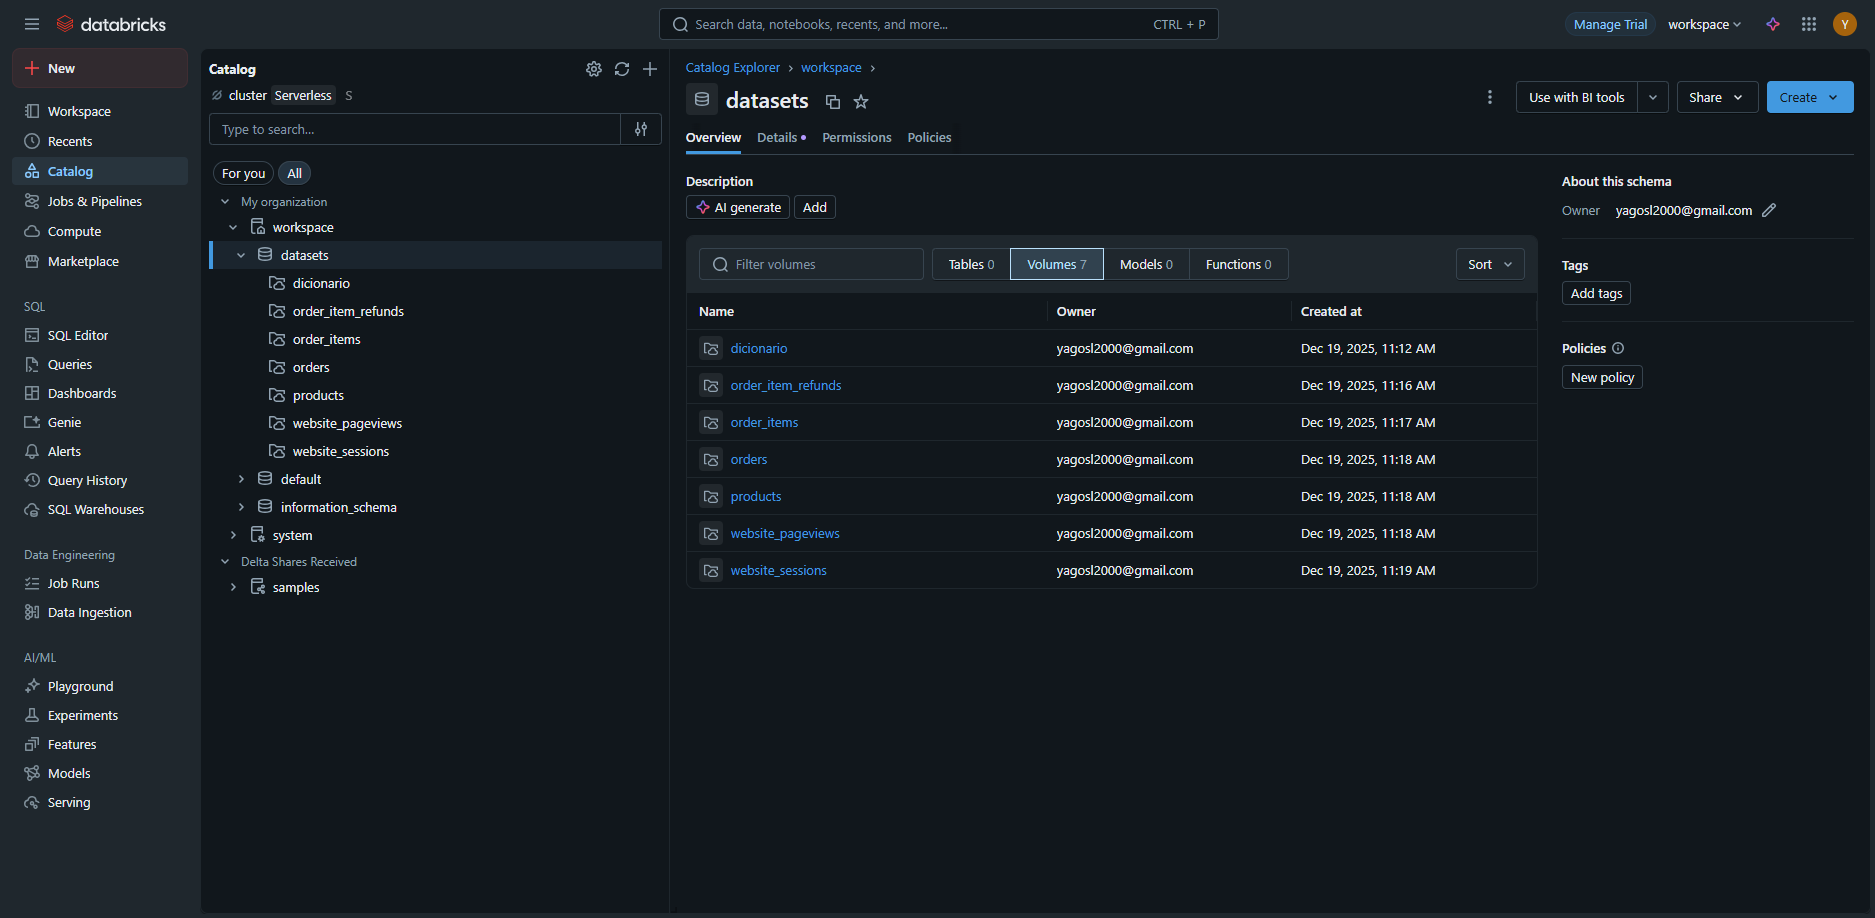

Após realizar o upload dos conjuntos de dados, renomeei o cluster padrão criado no Databricks free edition para "cluster", para melhor localização para comandos e permissões de execuções posteriores.

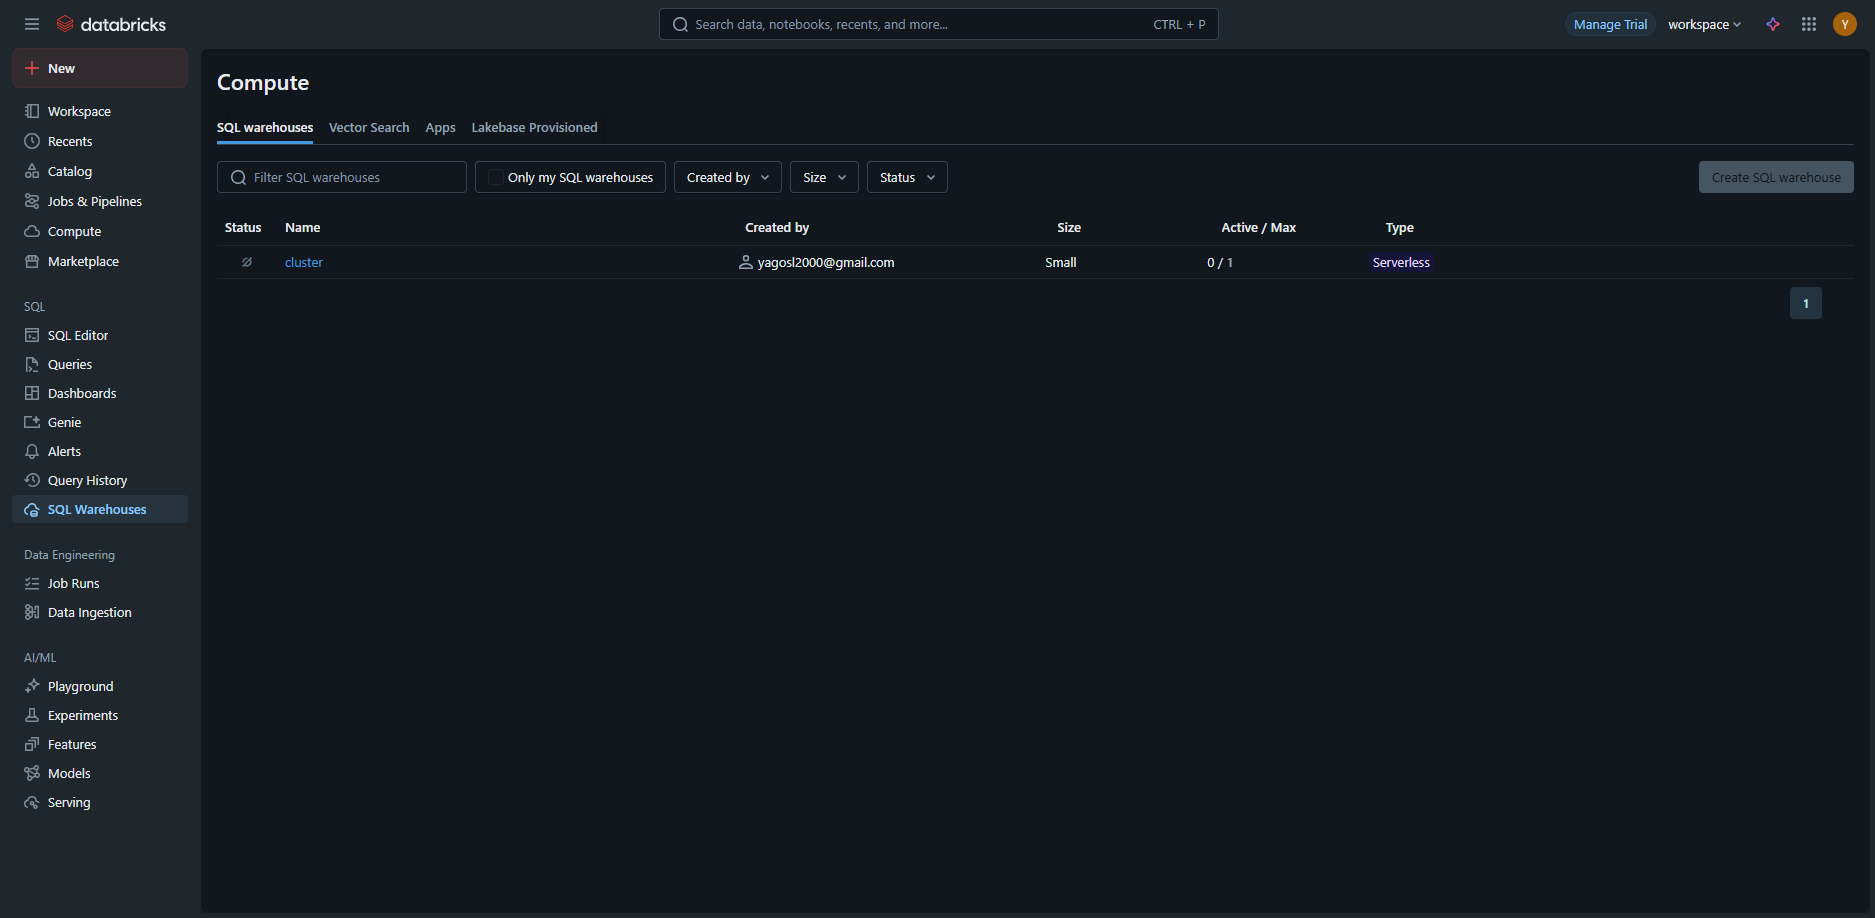

Após isso irei transformar o conjunto do volume dicionario em tabela sql para visualizar suas informações, pois desta tabela terei uma noção da descrição de cada coluna dos outros conjuntos.

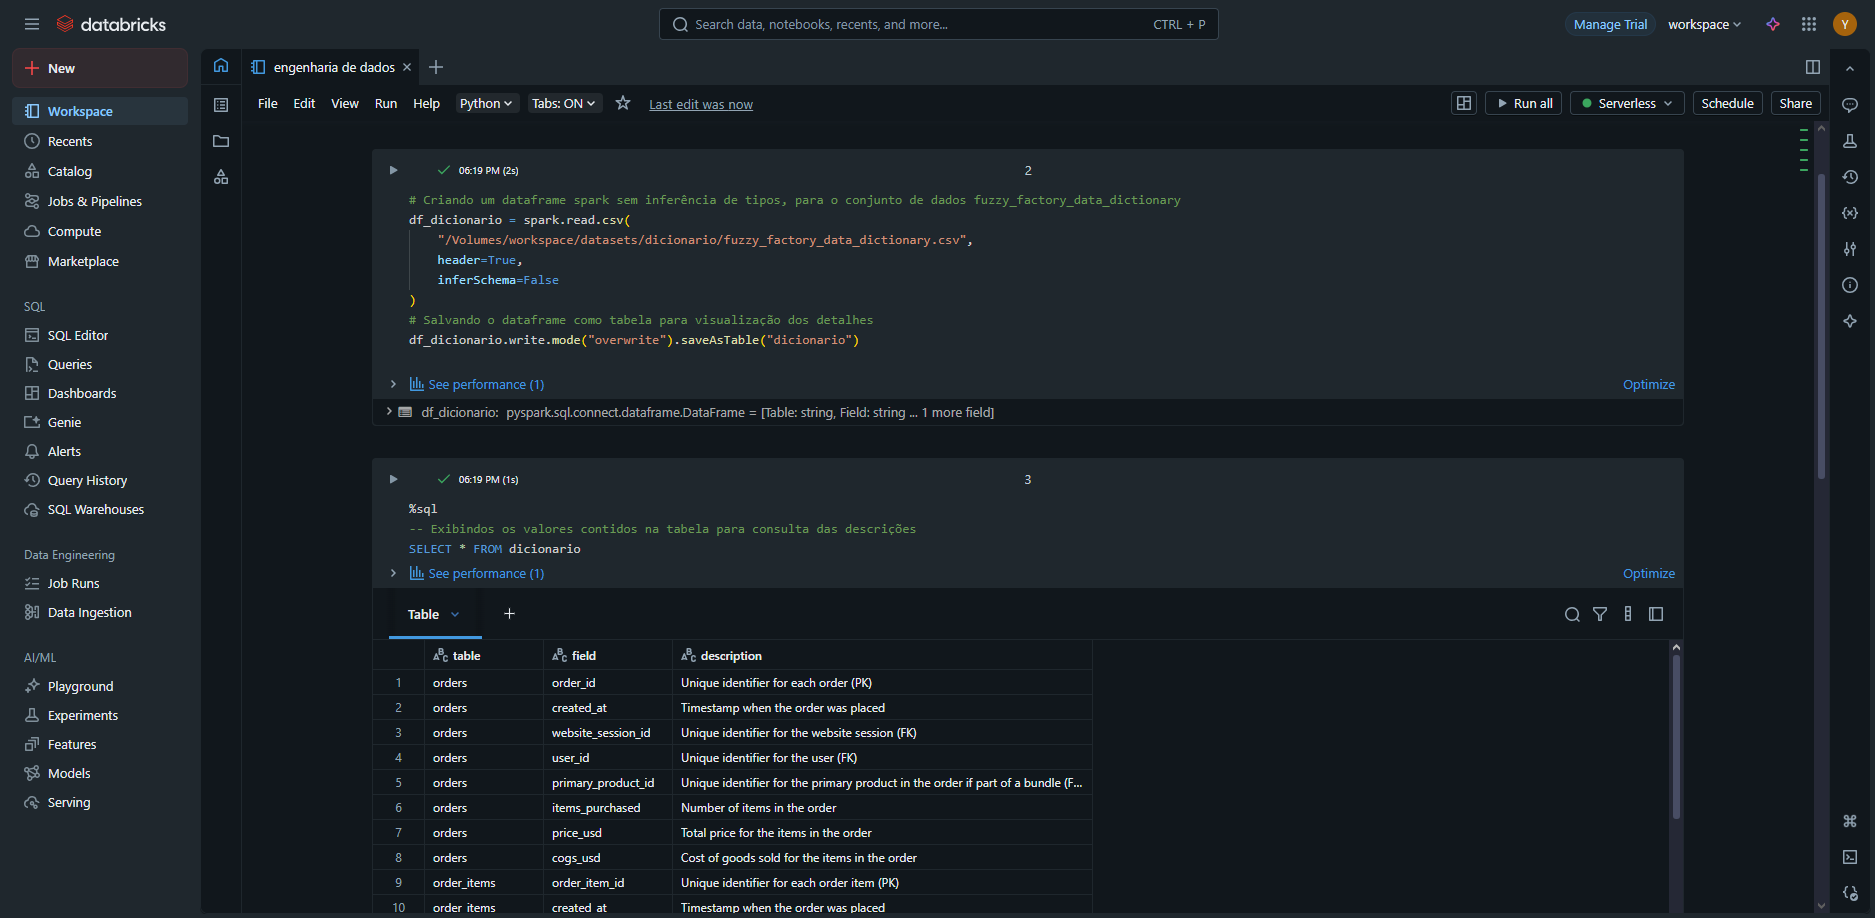

A base de dados contém 7 conjuntos de dados no formato .csv. São eles:
<br><br>

**1 - _fuzzy_factory_data_dictionary** - Este conjunto contém um dicionário descrevendo cada coluna de cada conjunto contido nesta base. Excluirei este conjunto na modelagem dos dados, pois a utilizarei apenas para consultar as descrições de cada coluna.<br>
* Colunas:<br>
  * Table -> Coluna referente ao nome do conjunto de que terá a descrição de sua coluna.
  * Field -> Coluna que terá a sua descrição no conjunto.
  * Description -> Descrição da coluna que está sendo referenciada na coluna anterior.
<br>

**2 - order_item_refunds** - Conjunto em que está armazenado as transações de reembolso dos produtos da loja de digital de brinquedos<br>
* Colunas:
  * order_item_refund_id -> Coluna de identificação dos dados de transação de reembolso. (Integer)
  * created_at -> Data de criação da transação de reembolso. (Date)
  * order_item_id -> Identificação do produto da lista da transação inicial. (Integer)
  * order_id -> Identificador para qualquer transação criada no sistema. (Integer)
  * refund_amount_usd -> Valor do produto contido na transação de reembolso, em dólares (usd). (Float)
<br>

**3 - order_items** - Transações de compra dos produtos da loja digital.
* Colunas:
  * order_item_id -> Identificador de cada transação de compra. (Integer)
  * created_at -> Data em que a transação de compra foi feita. (Date)
  * order_id -> Identificador para qualquer transação criada no sistema. (Integer)
  * product_id -> Identificador do produto contido na transação. (Integer)
  * is_primary_item -> Coluna indicadora de se este item é o primeiro produto da transação ou não. (Integer)
  * price_usd -> Custo do produto contido na transação, em dólares(usd). (Float)
  * cogs_usd ->Custo de produção do produto contido na transação em dólares (usd). (Float)
<br>

**4 - orders** - Transações que ocorrem na loja digital, podem ser reembolso ou compra.<br>
* Colunas:
  * order_id -> Identificação da transação. (Integer)
  * created_at -> Data de criação da transação. (Date)
  * website_session_id -> Identificador de qual sessão do site a transação foi iniciada. (Integer)
  * user_id -> Identificador de usuário. (Integer)
  * primary_product_id -> Identificador do item que esta no topo da lista de produtos da transação. (Integer)
  * items_purchased -> Número de itens contidos na transação. (Integer)
  * price_usd -> Preço total dos itens da transação. (Float)
  * cogs_usd -> Preço de produção dos produtos contidos na transação. (Float)
<br>

**5 - products** - Produtos que podem ser vendidos na loja digital.<br>
* Coluna:
  * product_id -> Identificador do produto. (Integer)
  * created_at -> Quando o produto foi criado. (Date)
  * product_name -> Nome do produto. (String)


<br>

**6 - website_pageviews** - Registros das paginas visitadas pelos usuários dentro do website da loja.<br>
* Coluna:
  * website_pageview_id -> Identificador da página do website. (Integer)
  * created_at -> Data de quando o registro foi criado. (Date)
  * website_session_id -> Identificador de sessão do website. (Integer)
  * pageview_url -> Caminho para a URL da pagina do registro. (String)


<br>

**7 - website_sessions** - Sessões de geradas por cada usuário<br>
* Coluna:
  * website_session_id -> Identificação da sessão. (Integer)
  * created_at -> Data que foi criada a sessão. (Date)
  * user_id -> id do usuário que gerou está sessão. (Integer)
  * is_repeat_session -> Indicador se é uma sessão repetida do mesmo usuário. (Integer)

  As seguintes colunas serão excluídas na sessão de modelagem dos dados, por não serem uteis para o alcance dos objetivos:

  * utm_source
  * utm_campaign
  * utm_content
  * device_type
  * http_referer




Realizando as descrições dos dados notei que o dataset não tem um conjunto dedicado aos usuários, mesmo fazendo menção a eles. O que impossibilita realizar algumas análises mais complexas envolvendo os usuários. Porém ainda há a possibilidade de análises de frequência.

Após realizar as descrições dos dados irei excluir a tabela gerada.

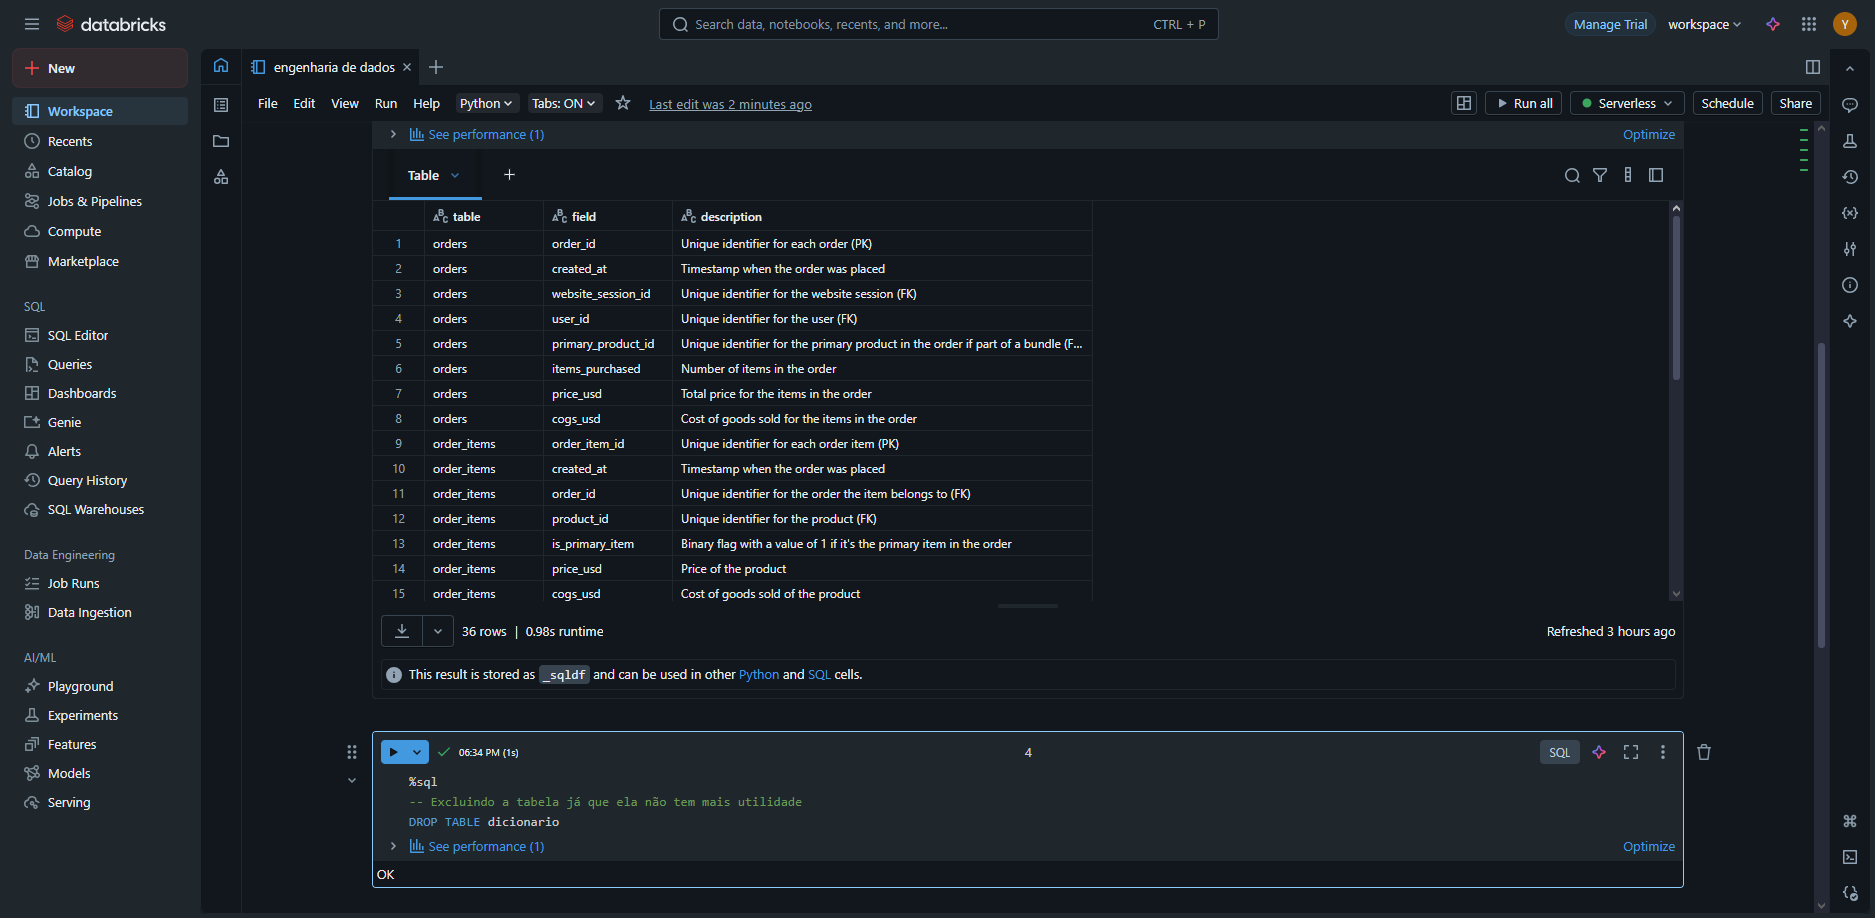

**NOTA:** Durante a tentativa de exibir os valores da tabela de dicionário, com nome originalmente como "_fuzzy_factory_data_dictionary.csv" tive alguns problemas para exibição dos valores da coluna, como o principal sendo a criação da tabela vazia. Depois de pesquisas nos tutoriais do Databricks, pela internet e até mesmo em Inteligências artificiais (Sendo este último o que menos ajudou), comecei a suspeitar que poderia ser o underscore("\_") na frente do nome do arquivo então voltei as minhas pesquisas para isso. Após uma breve pesquisa vi que há a possibilidade do spark ou sql dentro do Databricks interpretar o arquivo como oculto ou metadados, então eu exclui arquivo e refiz o upload sem o underscore e funcionou, o spark captou os dados do arquivo. Não conhecia este metodo de indicar metadados ao sistema, sempre trabalhei com arquivos como XML ou JSON.

##Modelagem e carga

### Modelagem

Nesta sessão irei tranformar todos os conjuntos em tabelas sql para manipulação, irei usar o pyspark para criação das tabelas por ter maior personalização de parâmetros e o restante das manipulações irei realizar em sql.<br><br>
Para cada conjunto realizei a criação de uma tabela inicial em que todos os dados serão Strings para não ter possibilidade de conflitos.

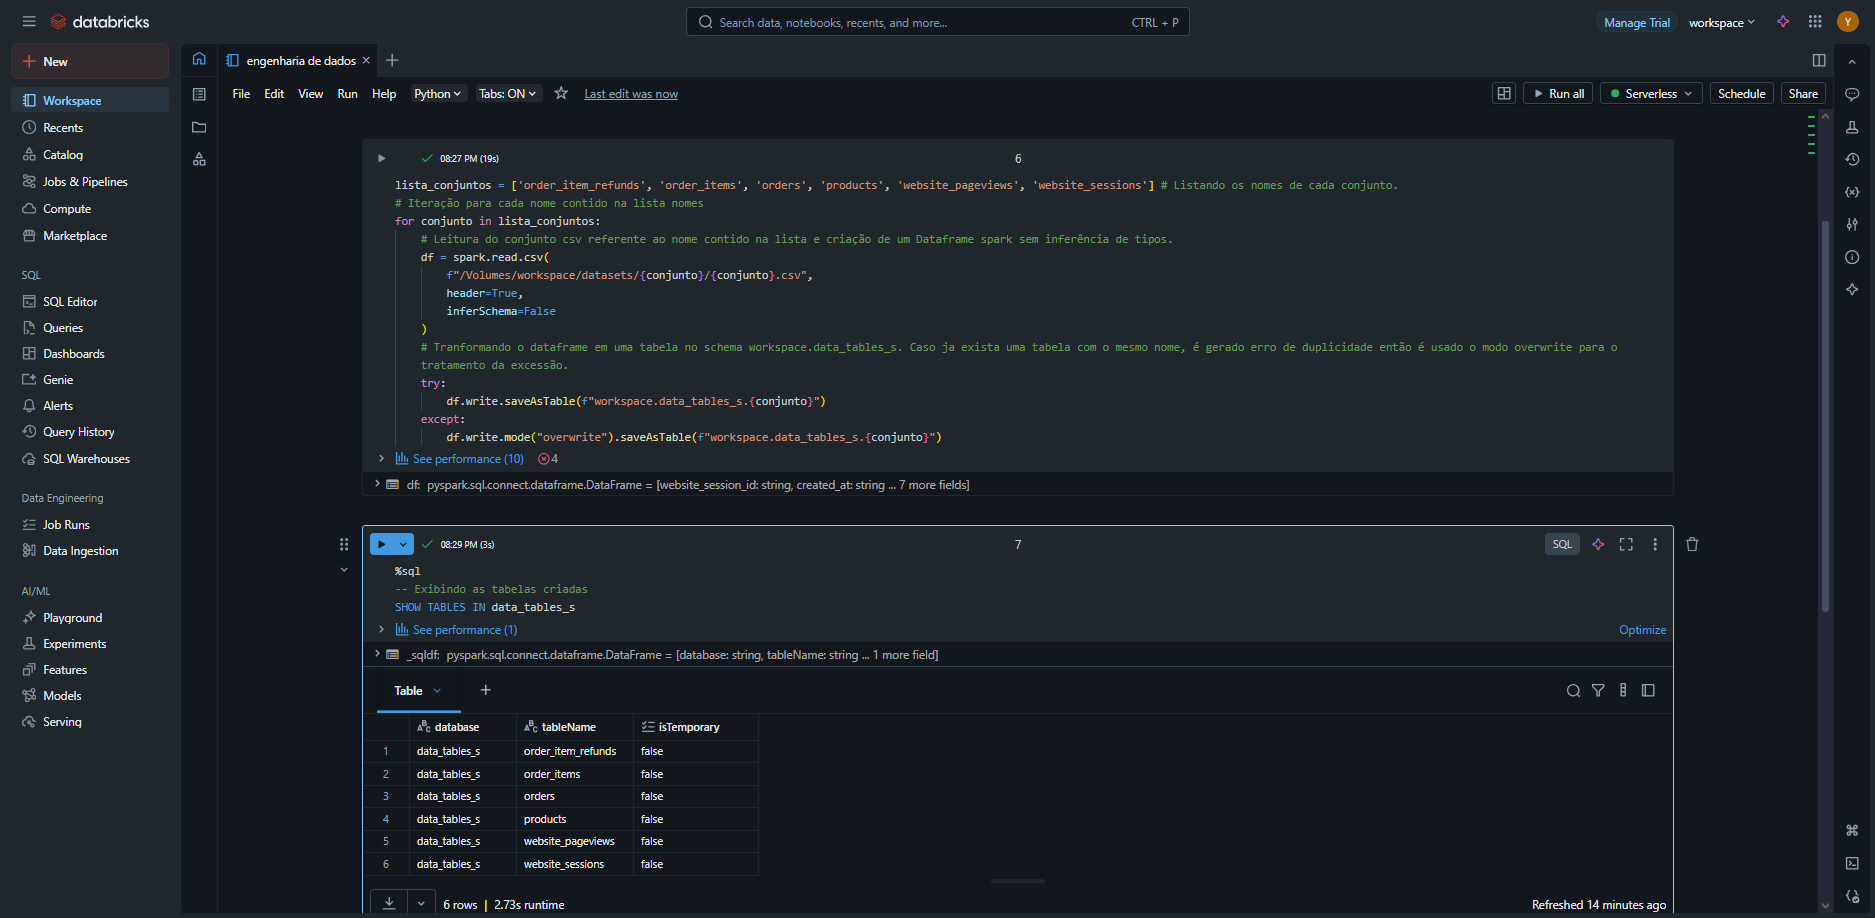

#### order_item_refunds

Selecionando todas as linhas que contenham valores NULL, que ocorre quando algum valor não é passado para coluna.

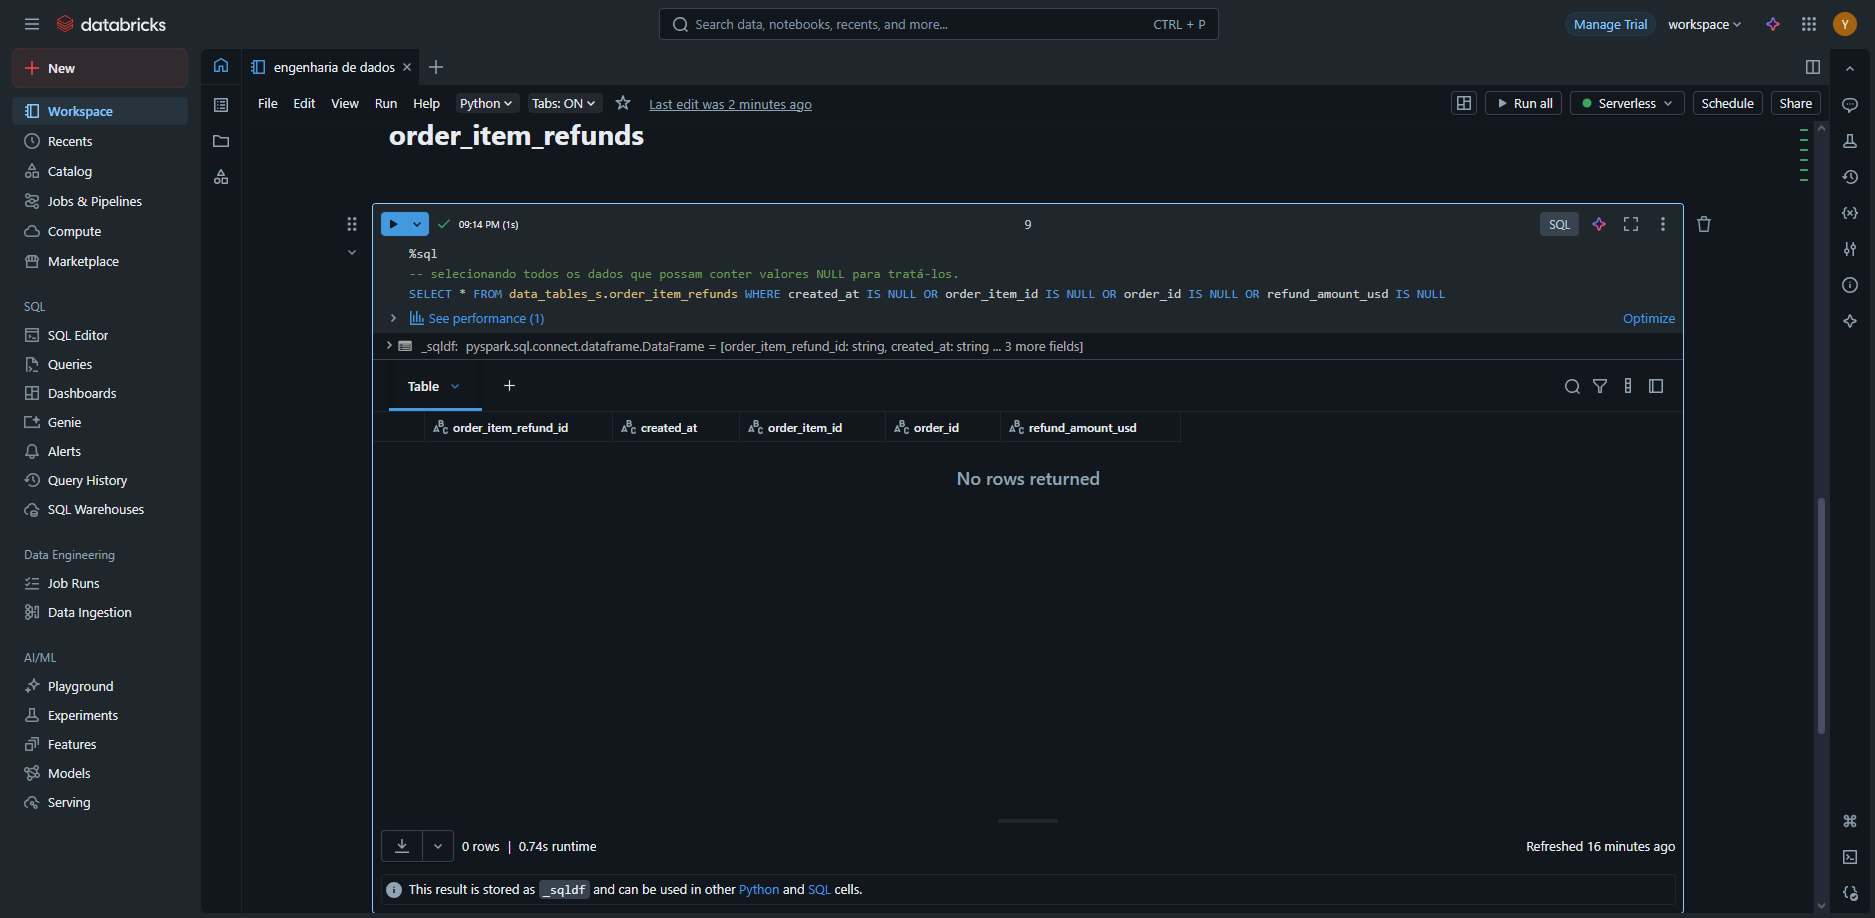

Preenchendo os valores com valores padrões tendo em vista os futuros tipos de dados de cada coluna.

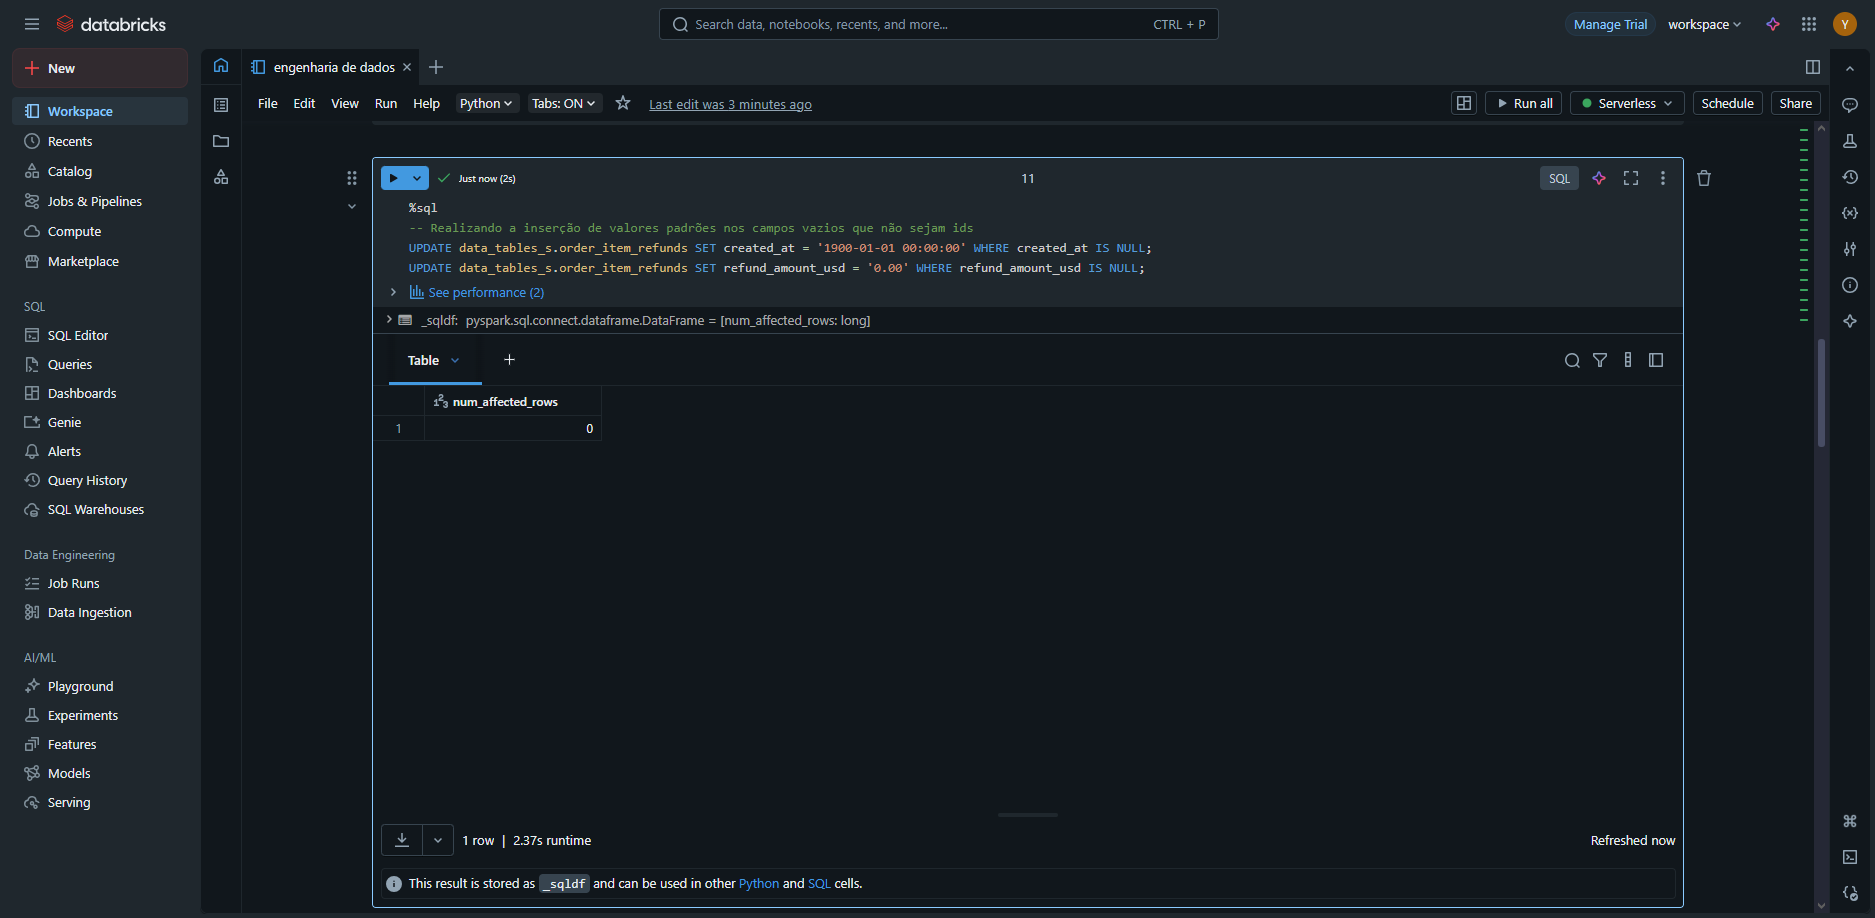

Tranferindo os dados preenchidos para uma nova tabela com a tipagem correta dos dados. O nome atual da tabela trabalhada será "order_item_refunds_typed"

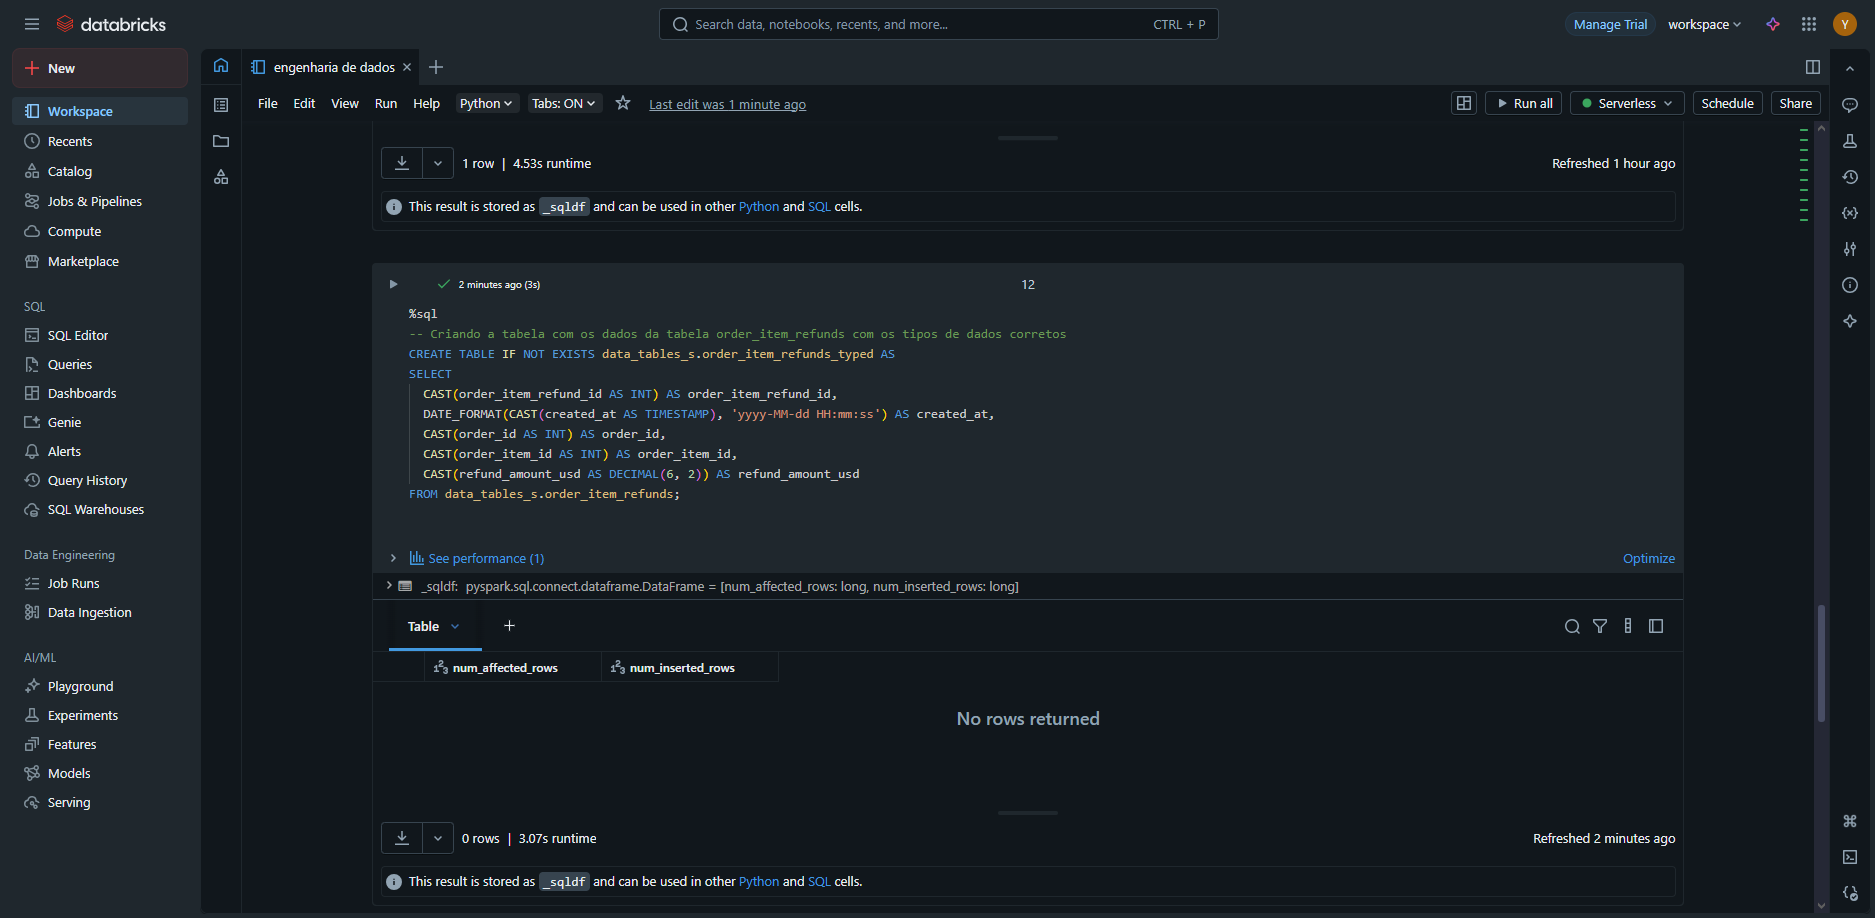

Após a criação da nova tabela irei exibir os valores minimos e maximos para ver se há algum valor fora do padrão.

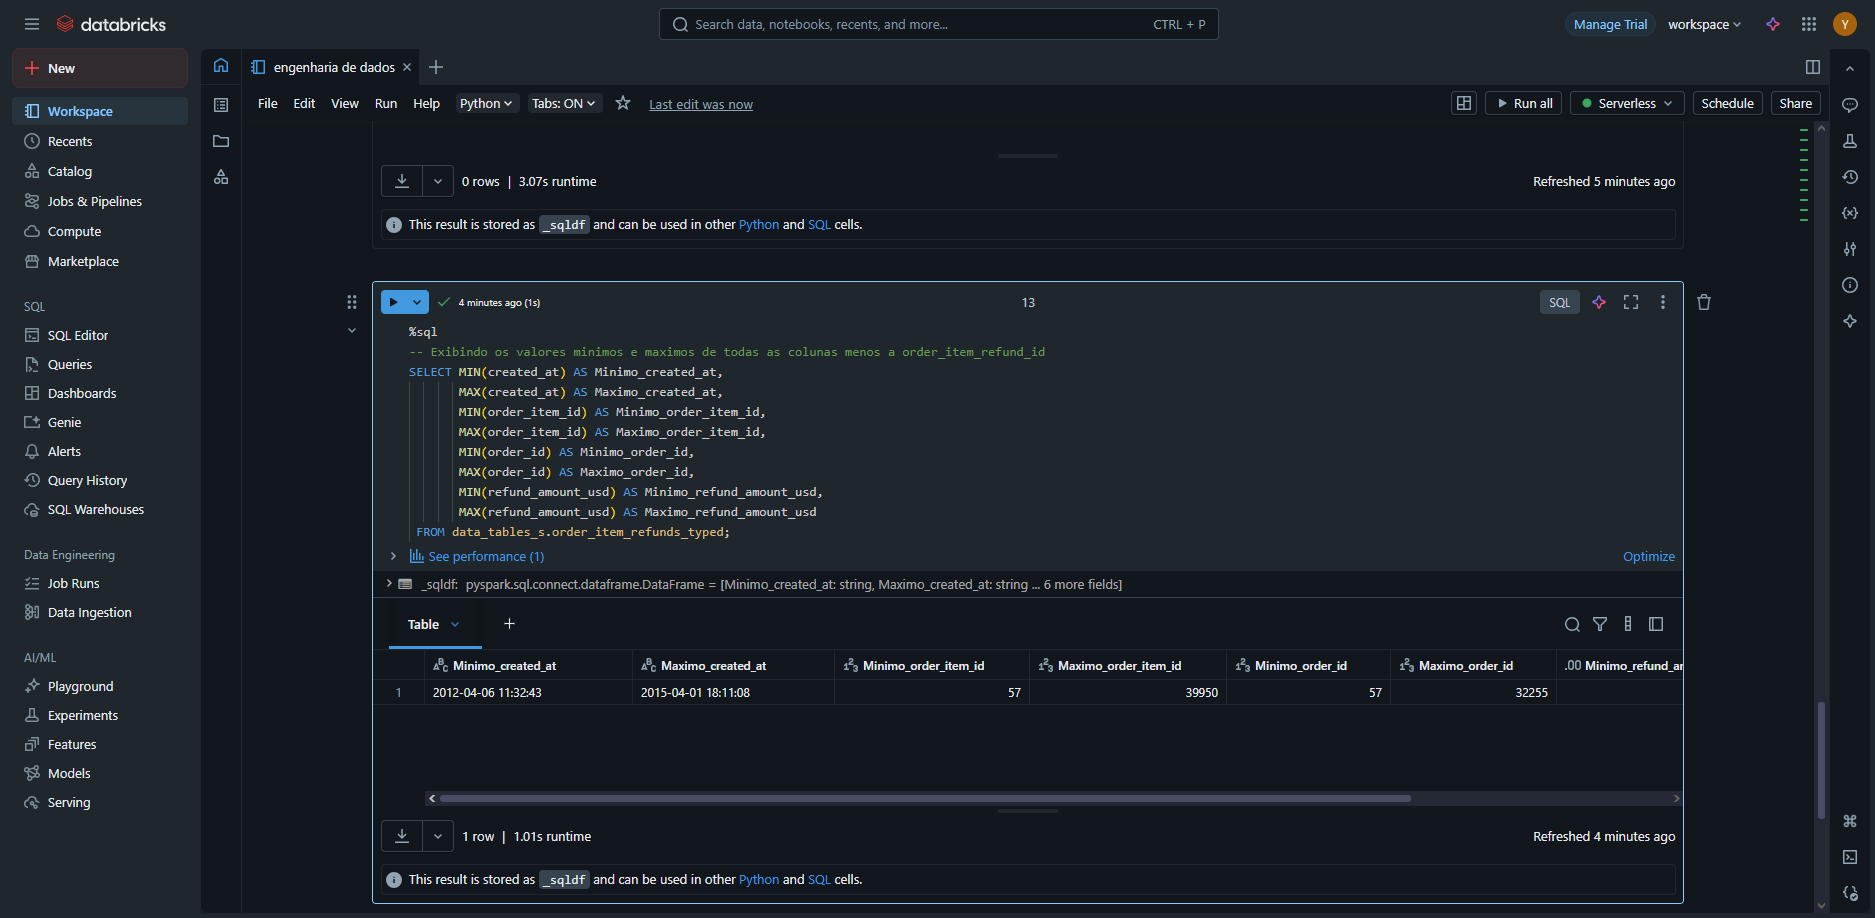

Os valores exibidos foram:<br>
|Minimo_created_at|Maximo_created_at|Minimo_order_item_id|Maximo_order_item_id|Minimo_order_id|Maximo_order_id|Minimo_refund_amount_usd|Maximo_refund_amount_usd|
|---|---|---|---|---|---|---|---|
|2012-04-06 11:32:43|2015-04-01 18:11:08|57|39950|57|32255|29.99|59.99|

<br>
Como não notei nenhum erro nos valores irei dar seguimento para as outras tabelas.

#### order_items

Irei realizar os mesmos procedimentos com a tabela order_items, começando pela exibição dos dados.

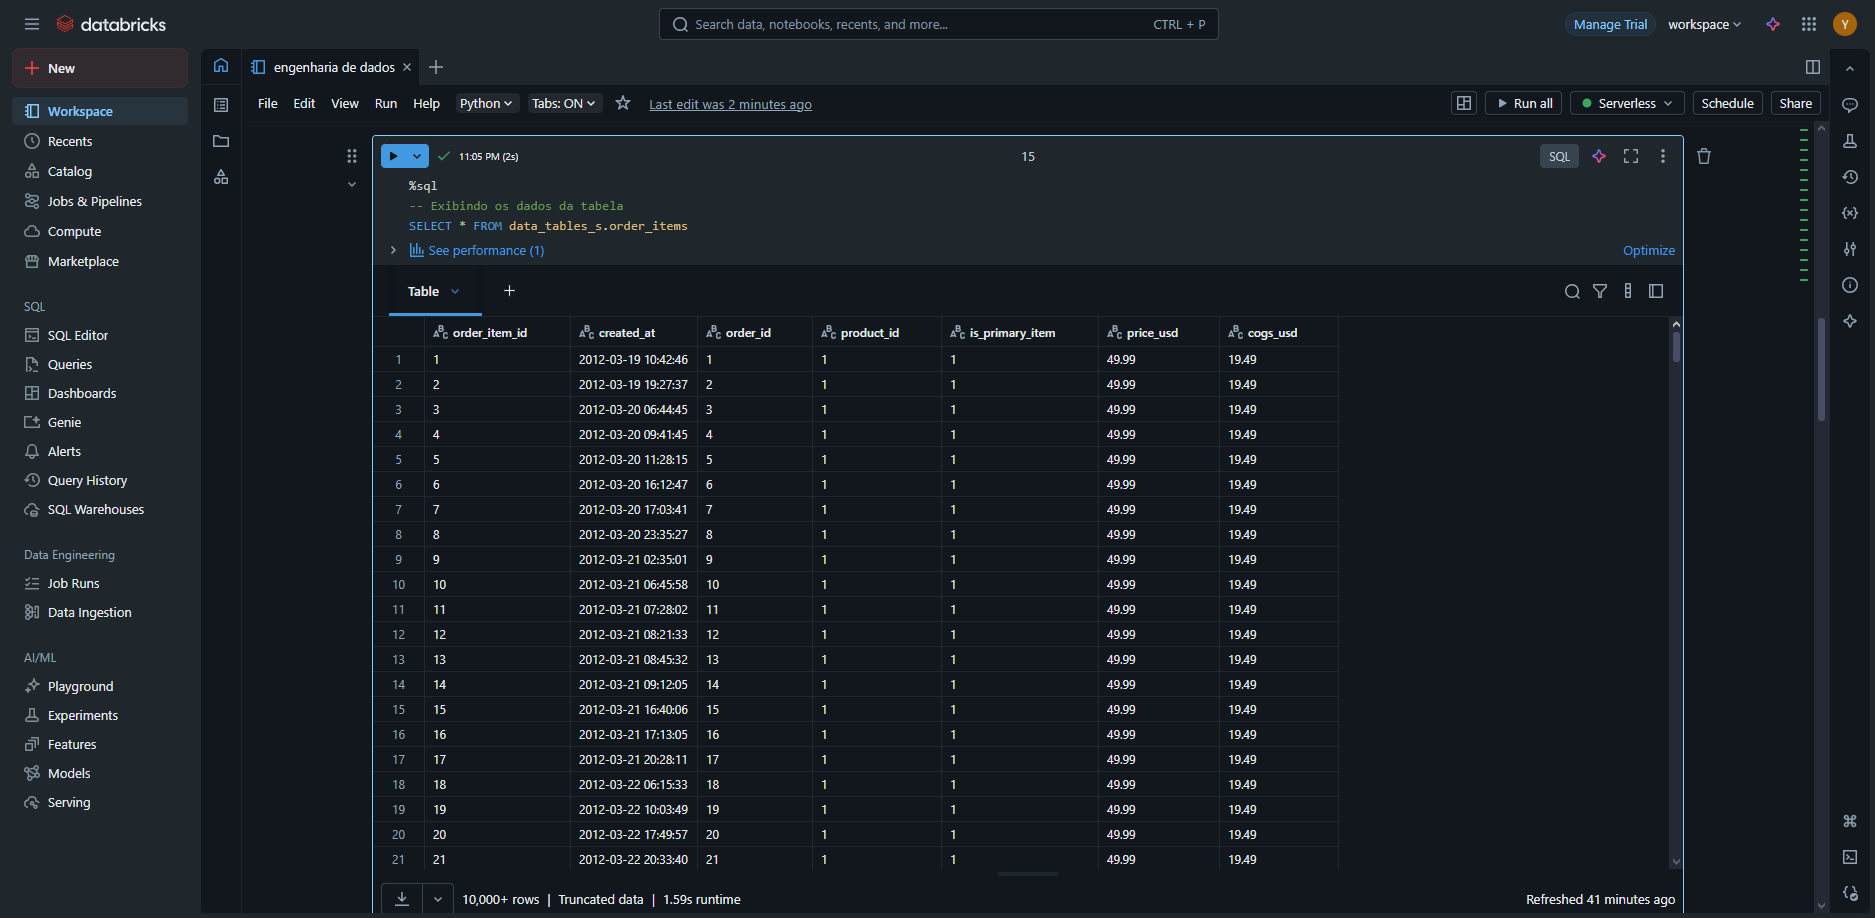

Selecionando todos os dados nulos da tabela

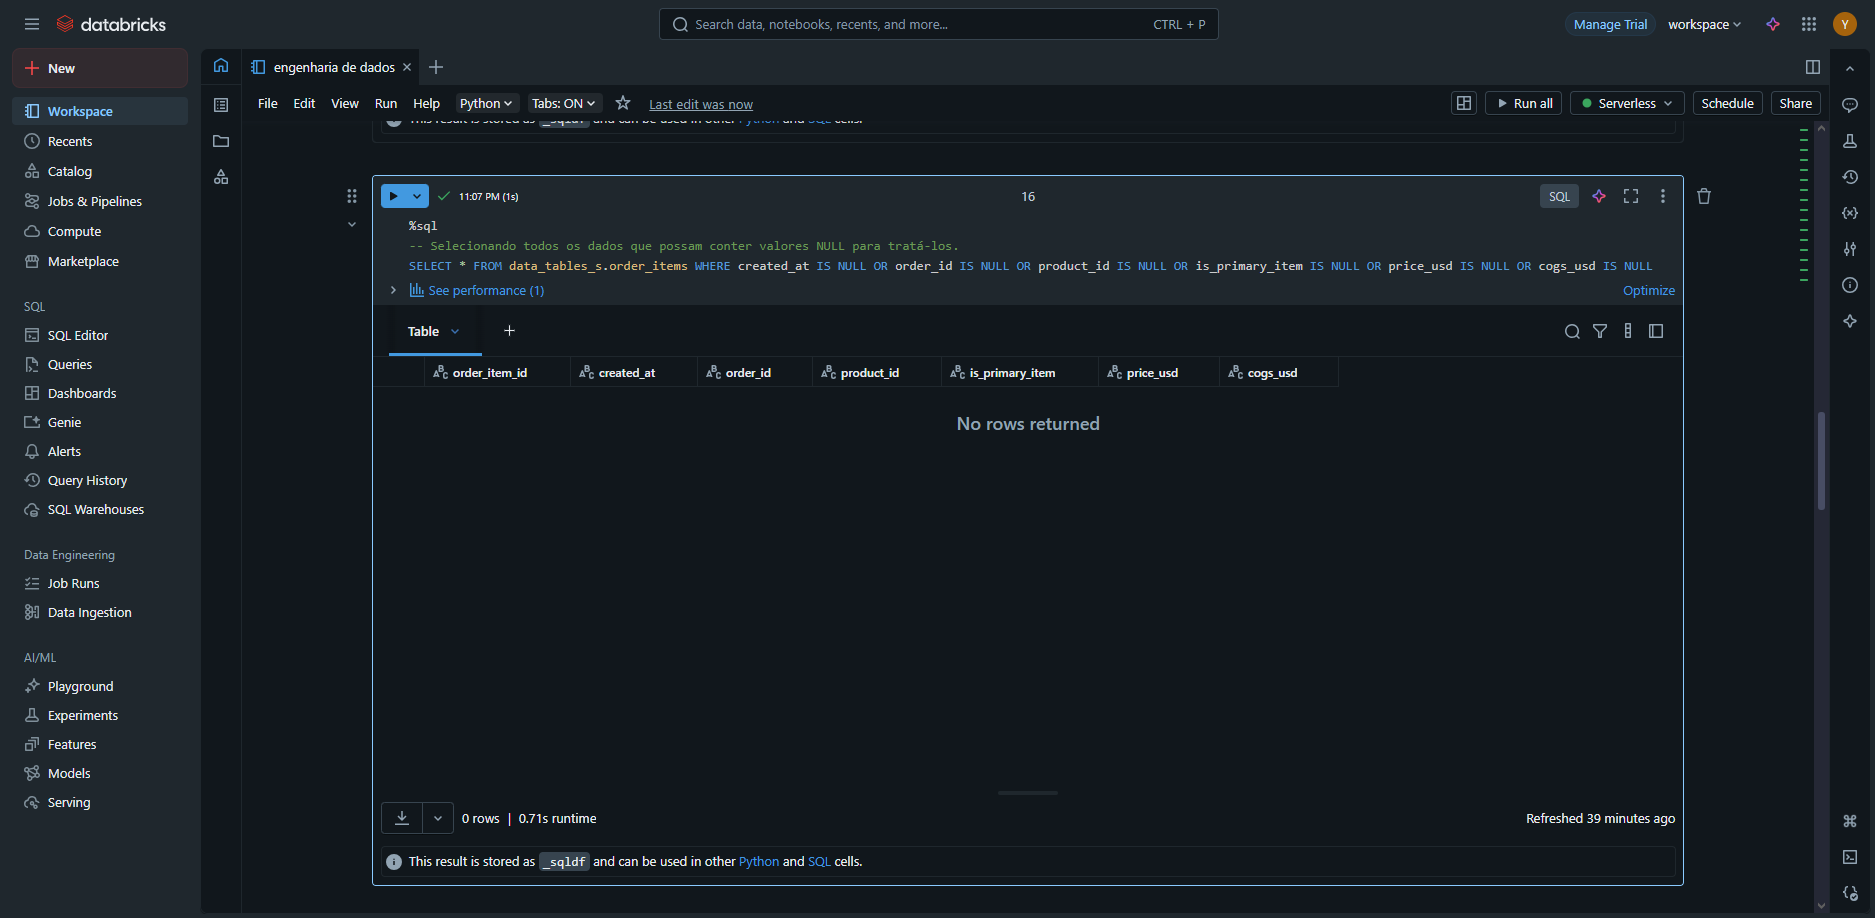

Preenchendo os campos nulos com valores padrões

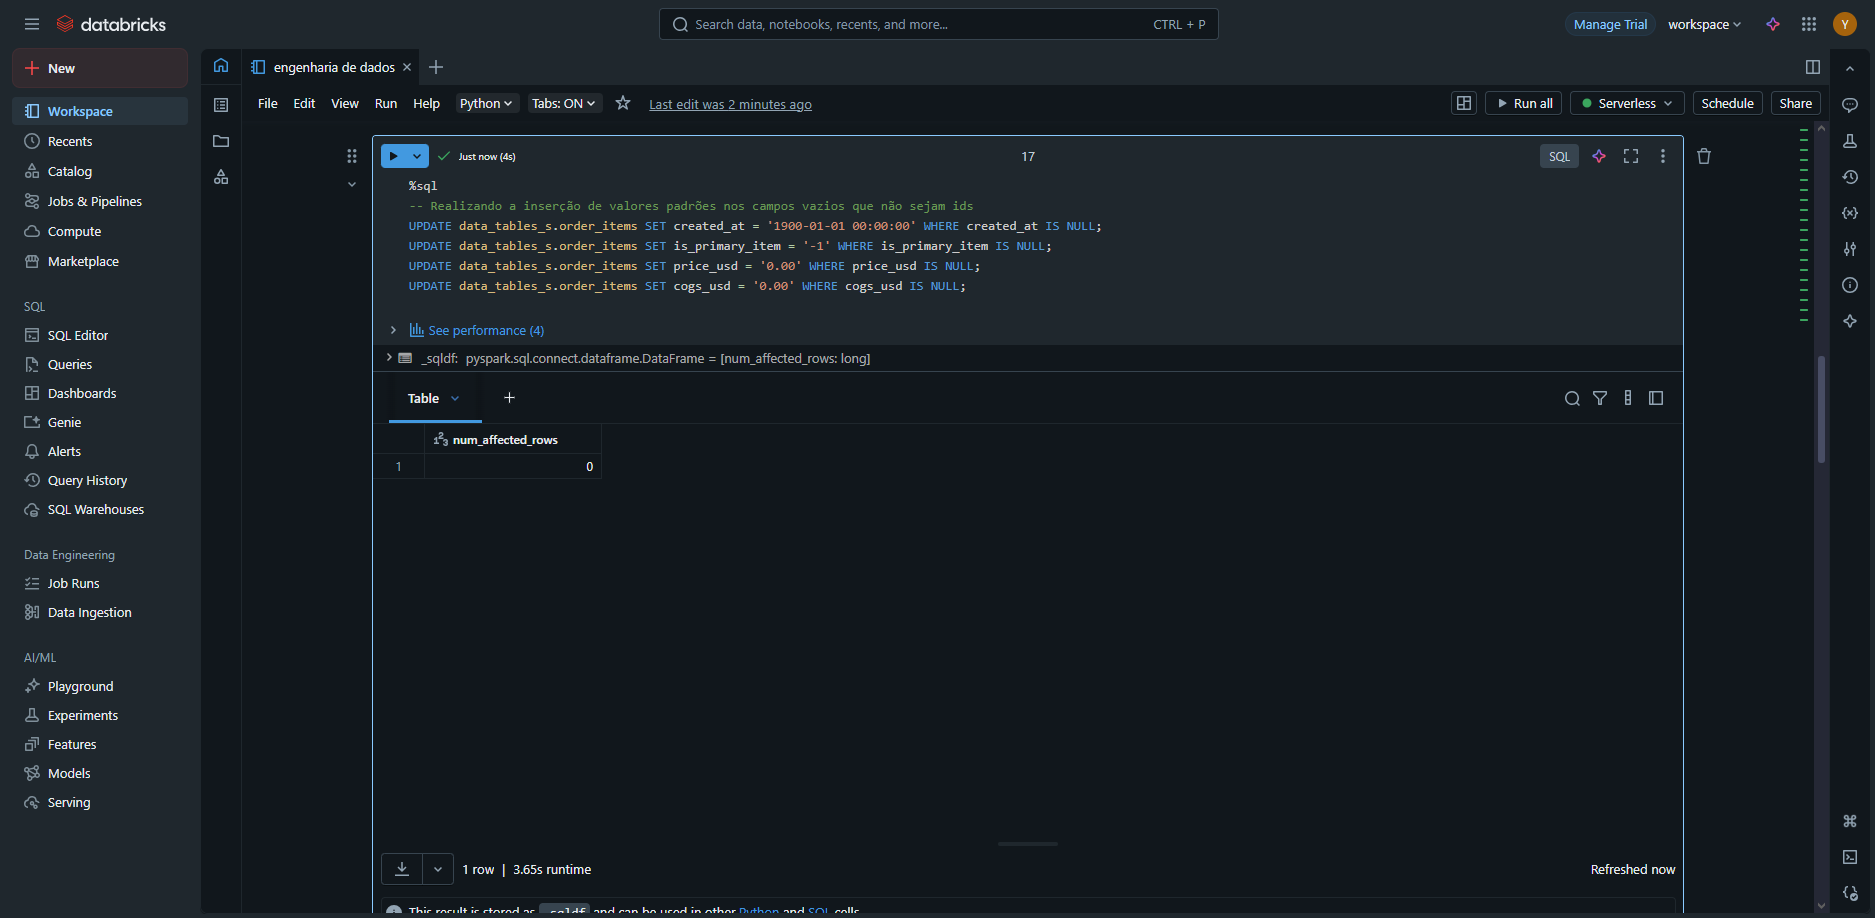

Criando a tabela com as devidas tipagens de colunas

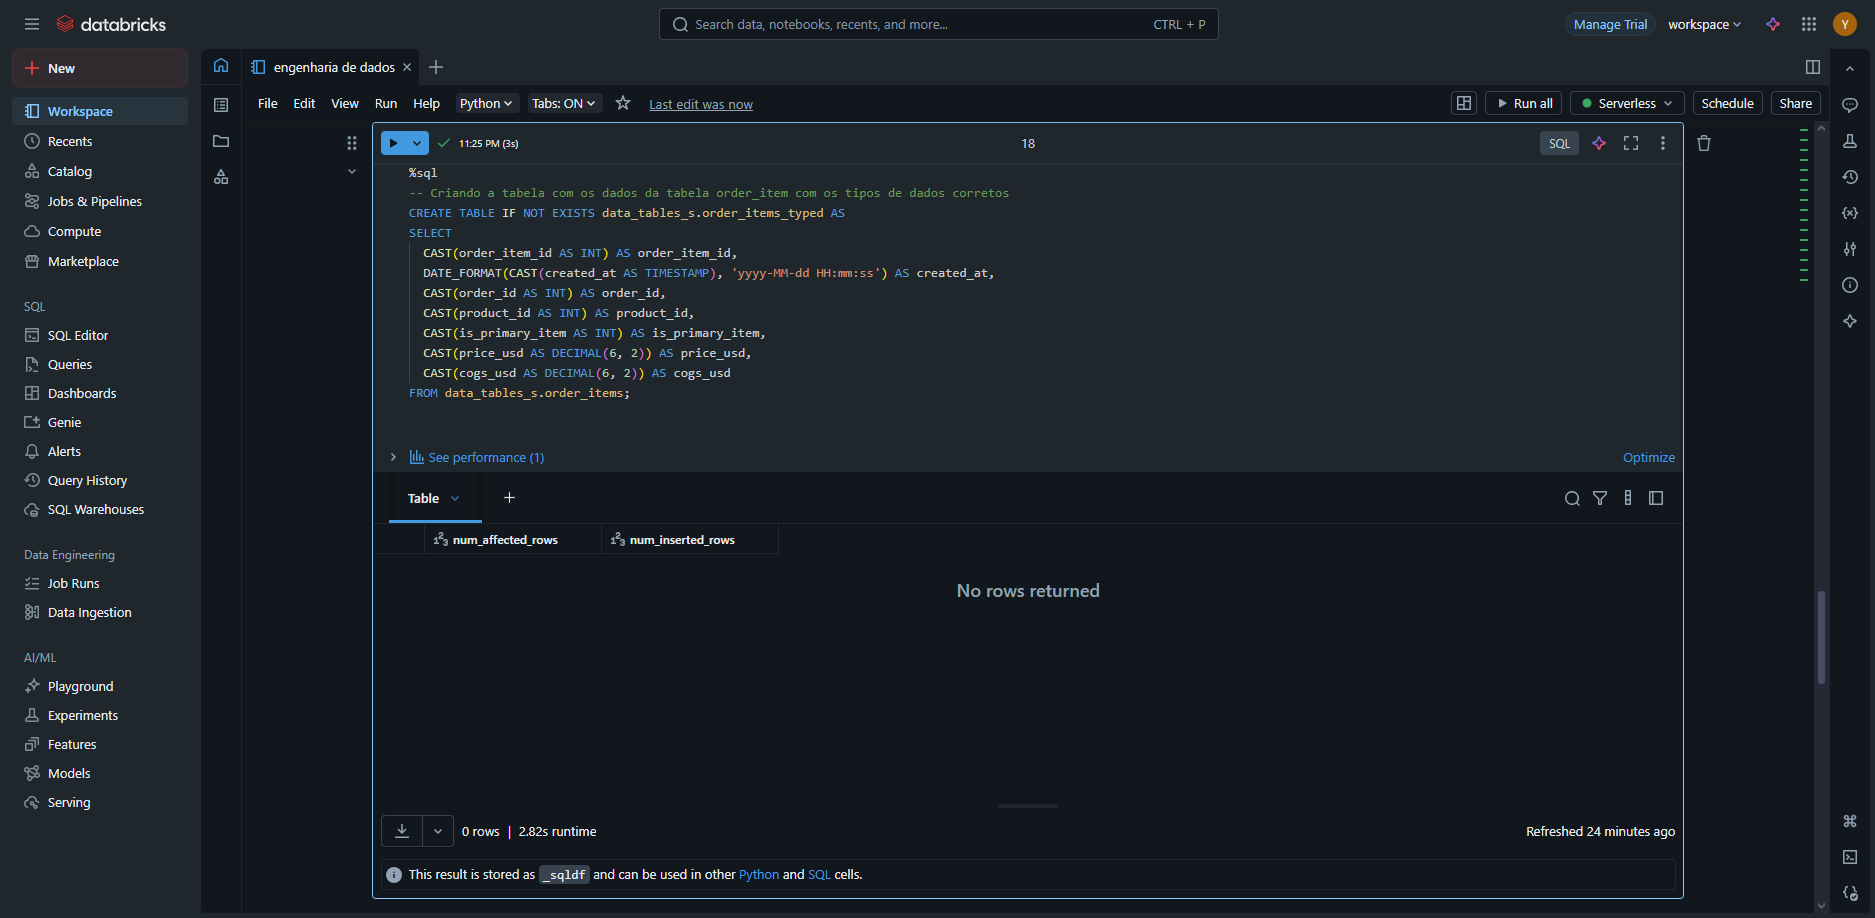

Exibindo os valores maximos e minimos para ver se há algum valor fora do normal.

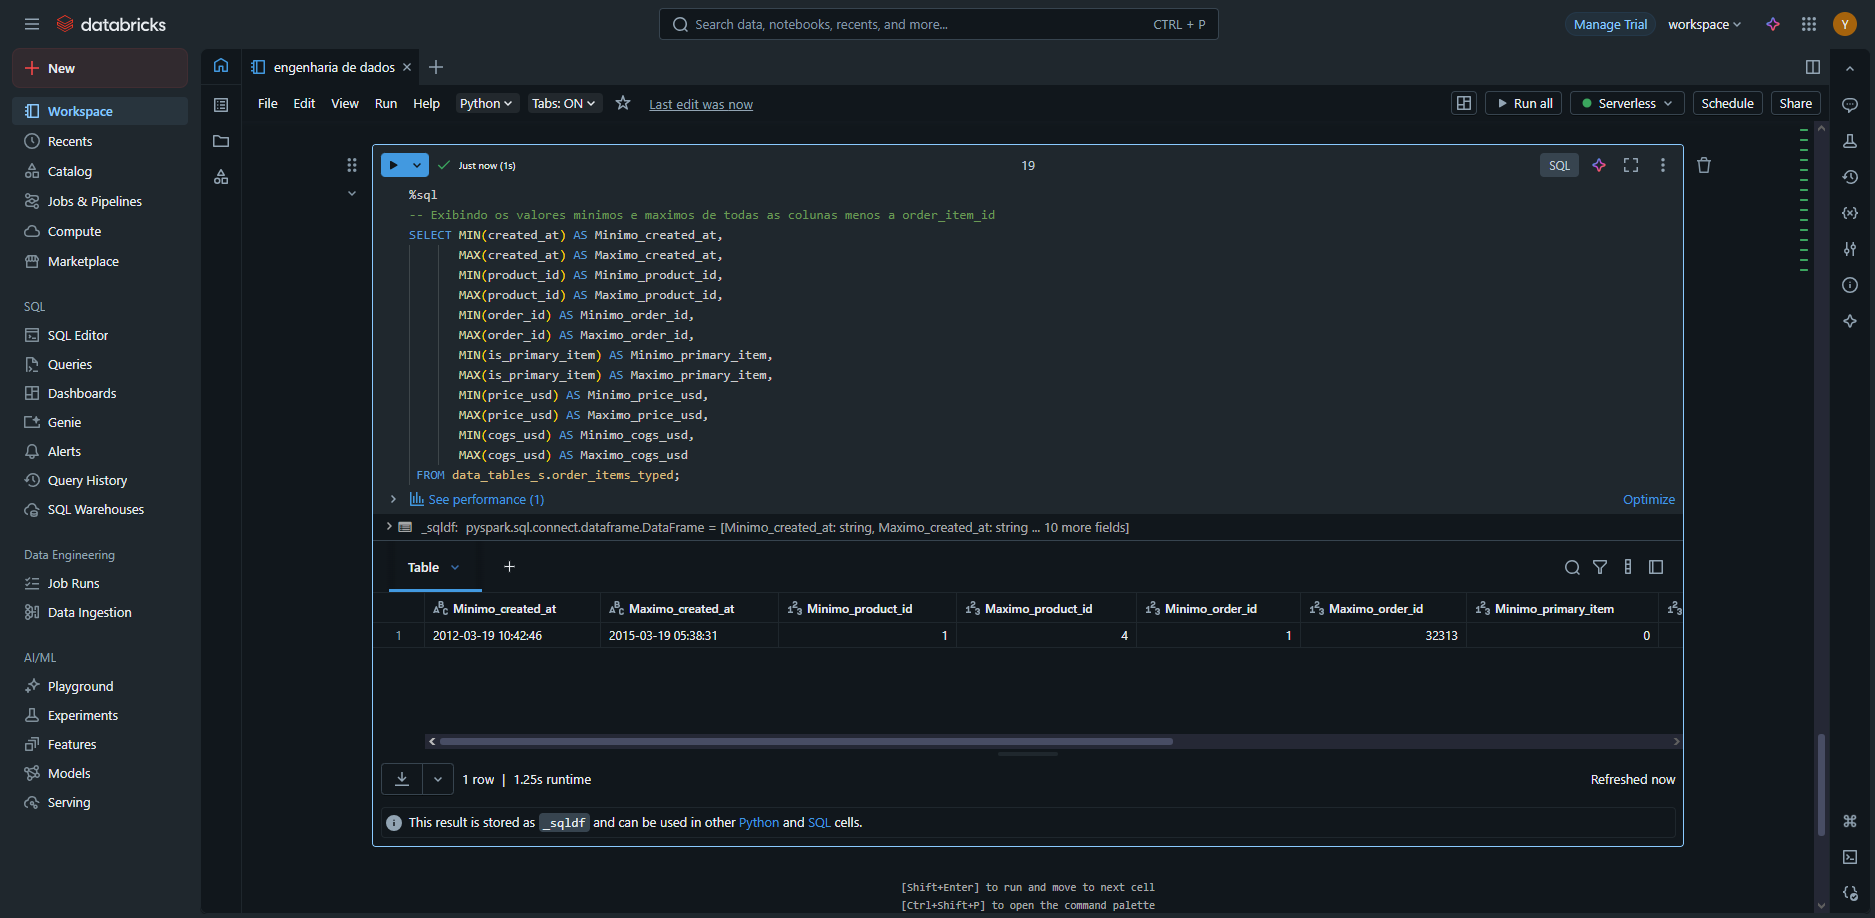

Tabela exibida:<br>
|Minimo_created_at|Maximo_created_at|Minimo_product_id|Maximo_product_id|Minimo_order_id|Maximo_order_id|Minimo_primary_item|Maximo_primary_item|Minimo_price_usd|Maximo_price_usd|Minimo_cogs_usd|Maximo_cogs_usd|
|---|---|---|---|---|---|---|---|---|---|---|---|
|2012-03-19 10:42:46|2015-03-19 05:38:31|1|4|1|32313|0|1|29.99|59.99|9.49|22.49|

<br>

Nenhum dos valores aparentam ser fora do padrão que deve estar presente no conjunto order_items.

#### orders

Esta tabela é para ser a que contém todas as transações realizadas no website, irei dar seguimento exibindo os dados e logo depois realizando os mesmos processos das outras tabelas.

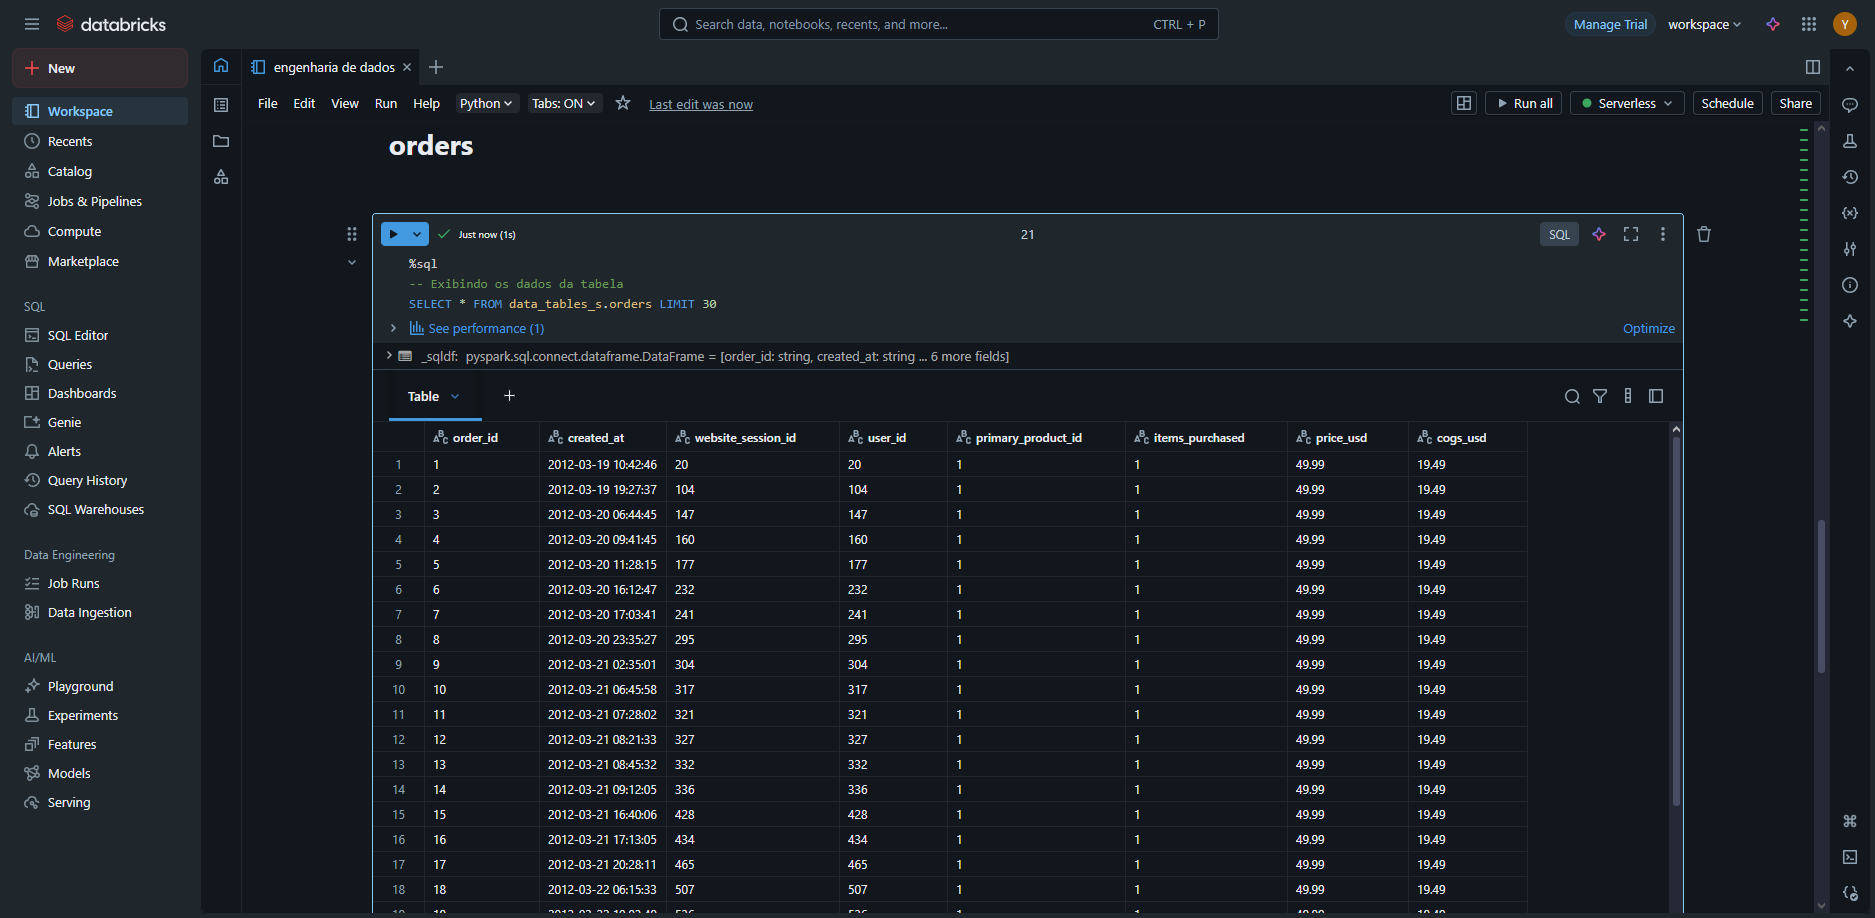

Irei selecionar os dados nulos caso existam, e então após preenche-los.

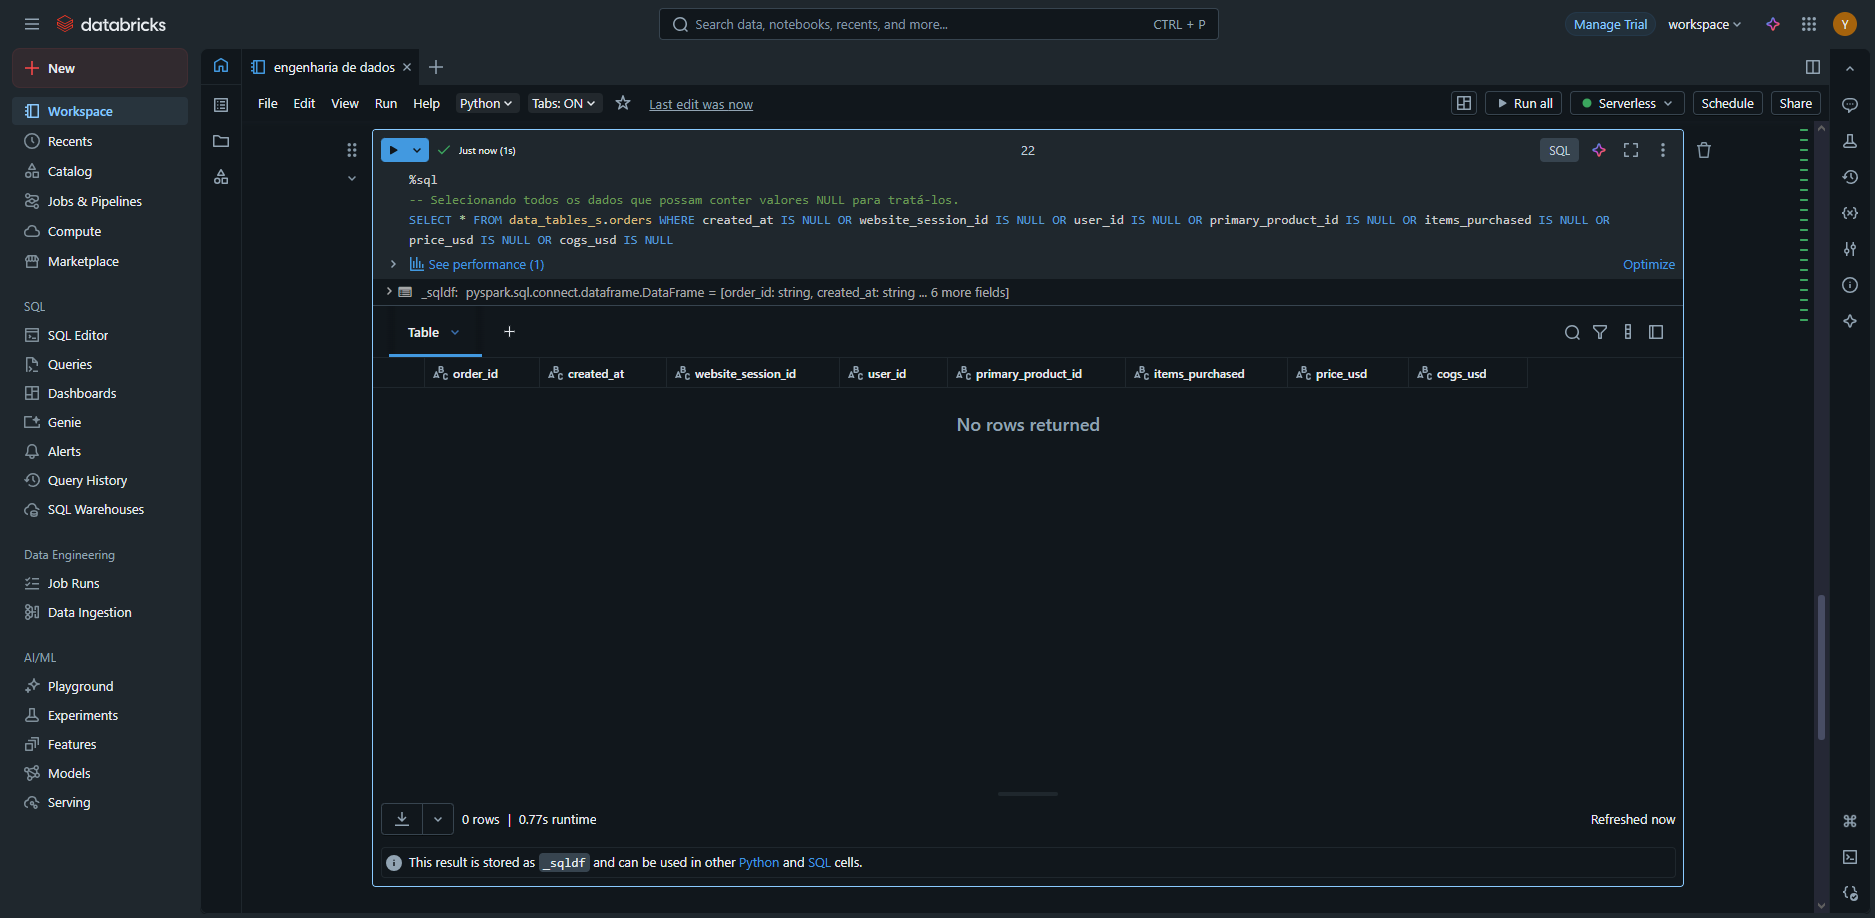

Preenchimento dos dados nulos que não sejam ids

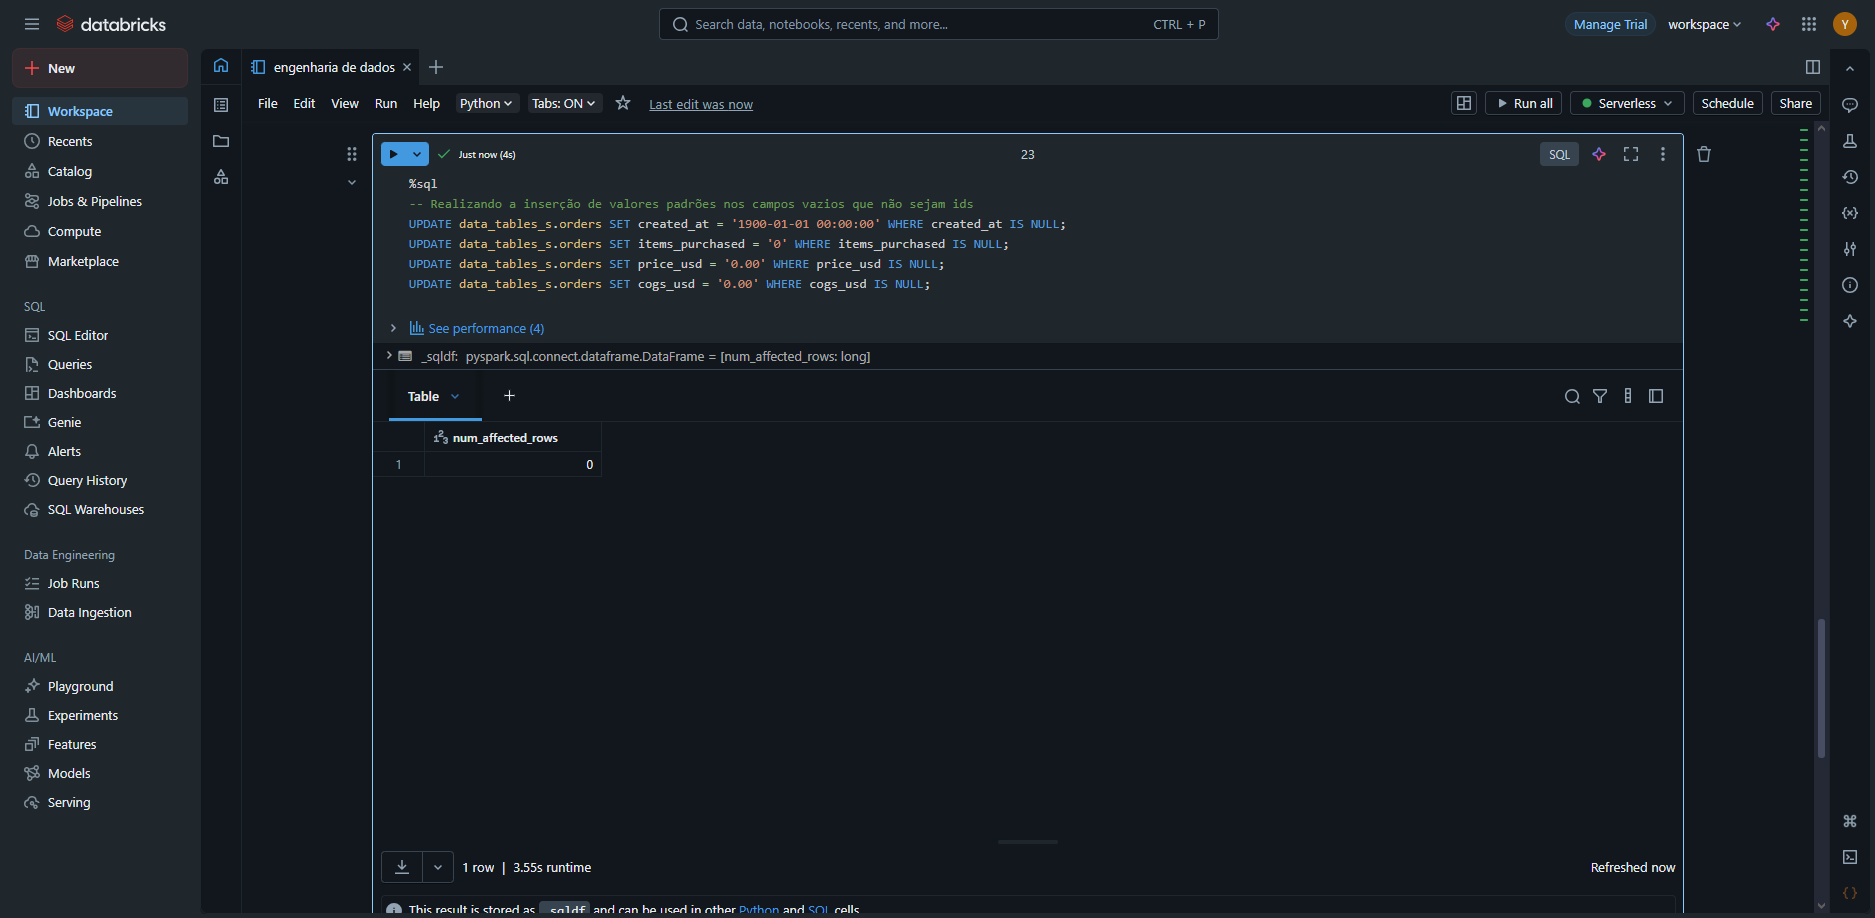

Montando a tabela com as devidas tipagens de cada coluna.

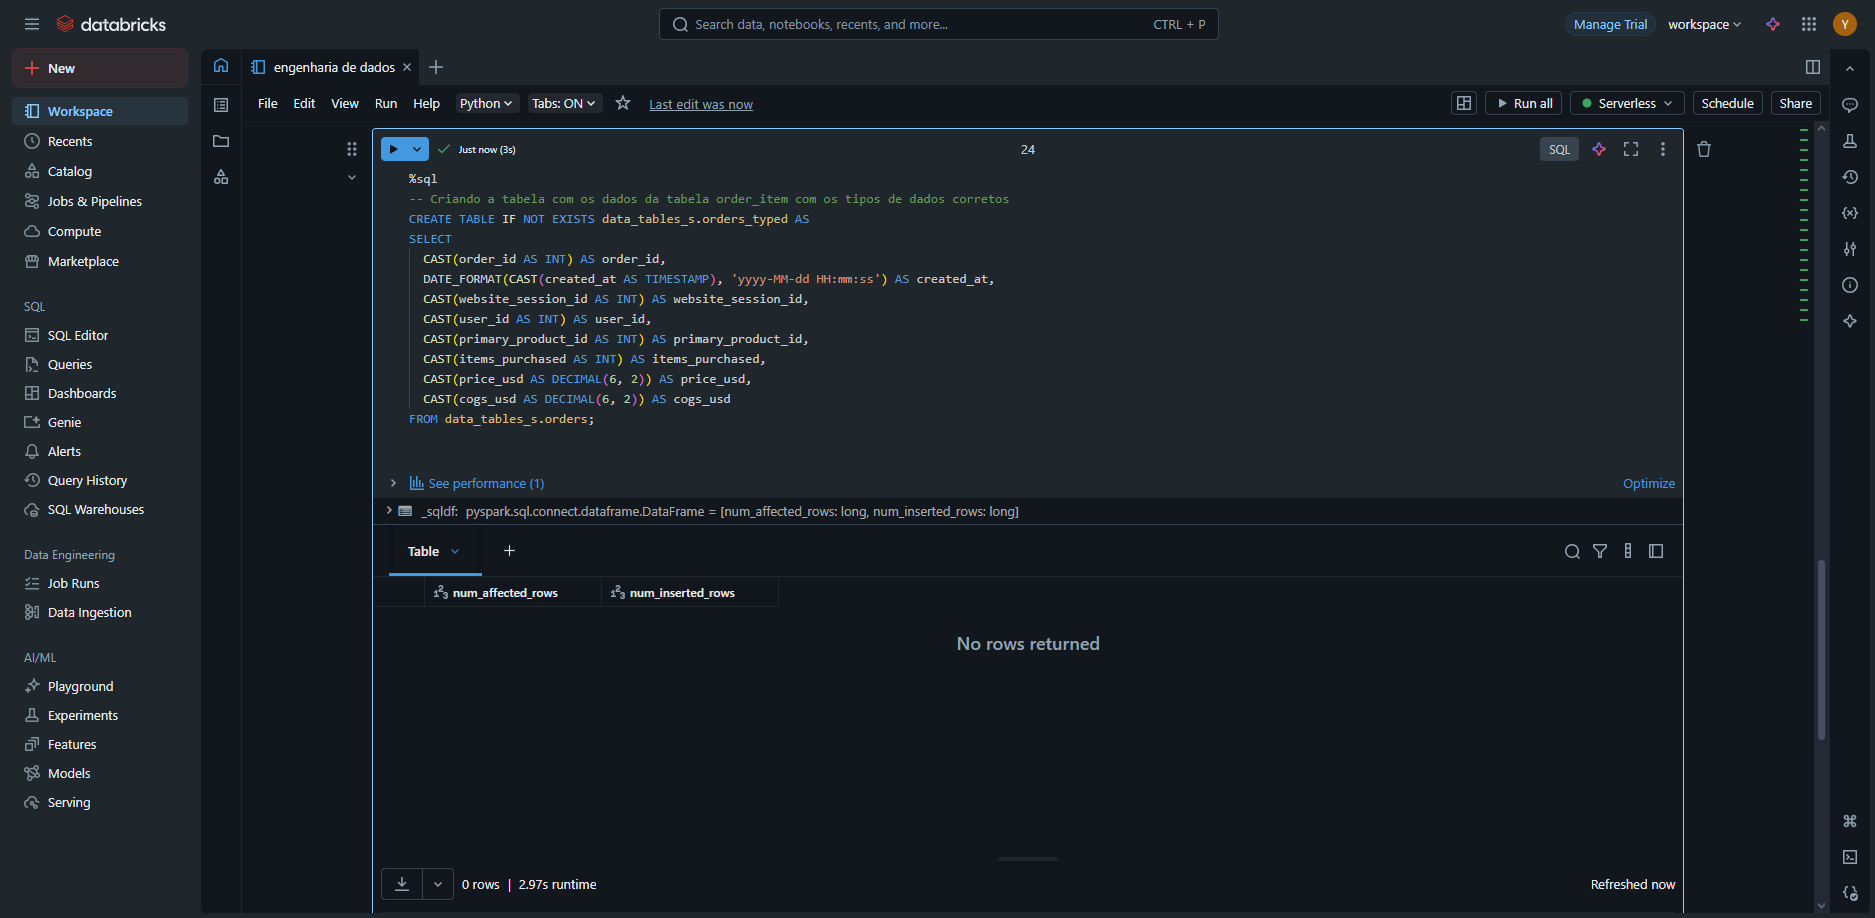

Irei exibir o mínimo e o máximo de cada coluna da nova tabela criada

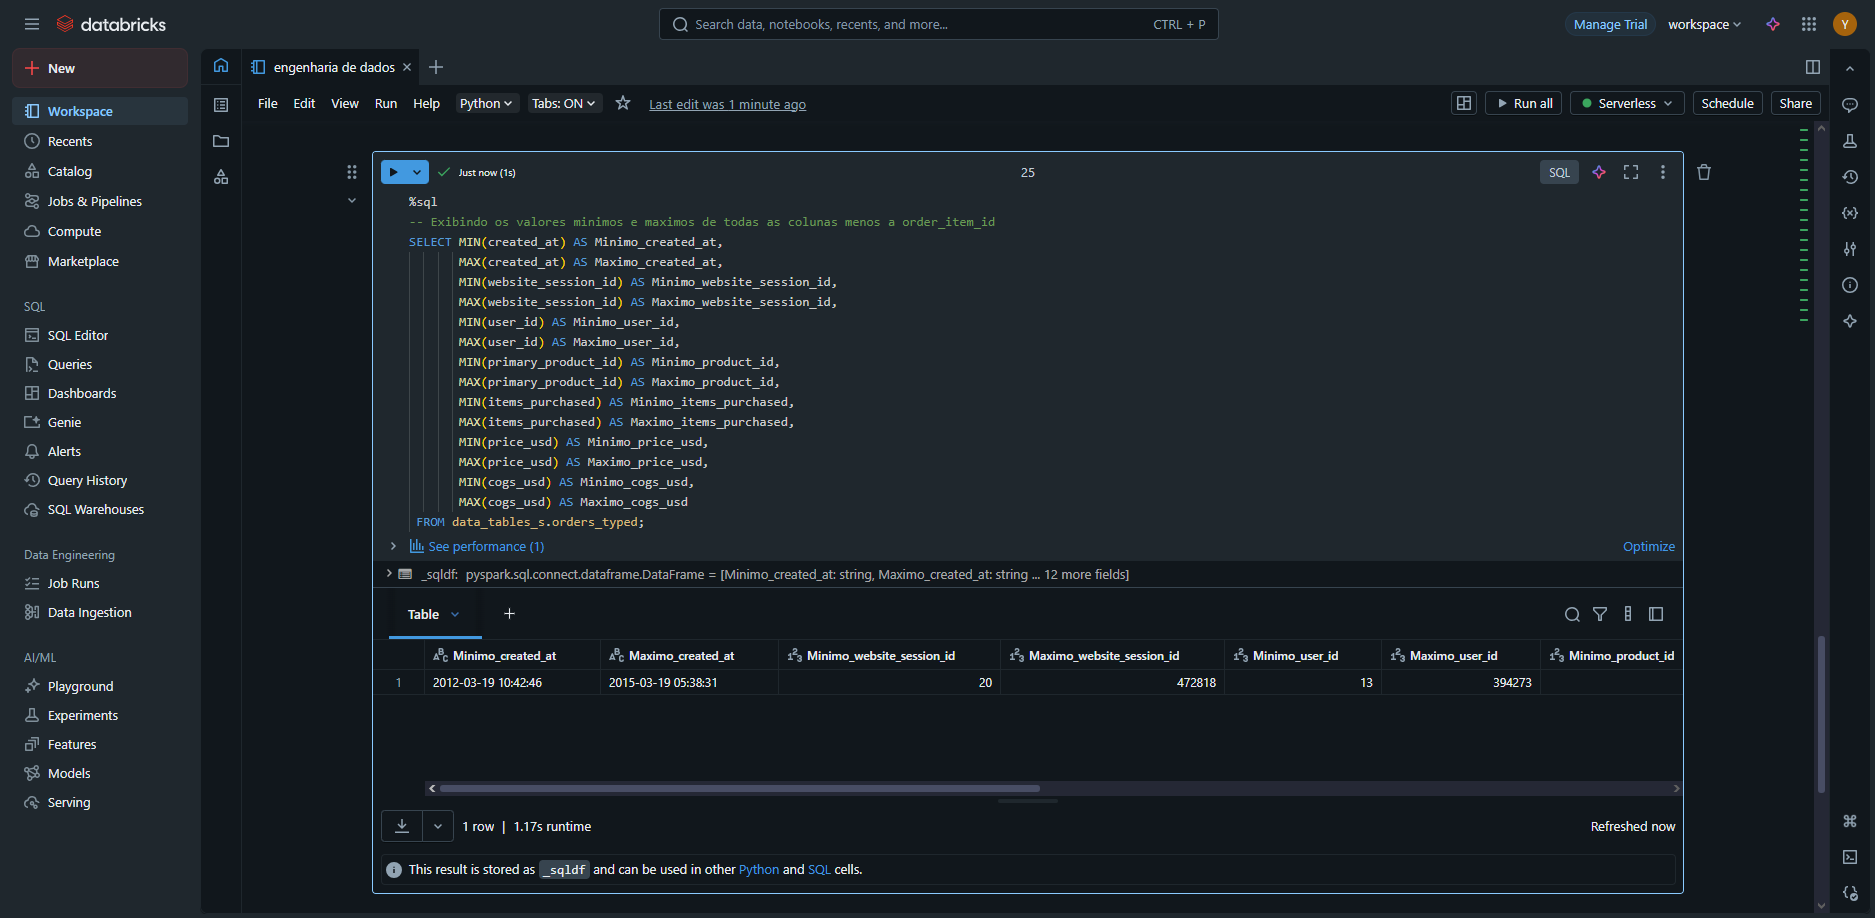

Os dados exibidos são:<br>
|Minimo_created_at|Maximo_created_at|Minimo_website_session_id|Maximo_website_session_id|Minimo_user_id|Maximo_user_id|Minimo_product_id|Maximo_product_id|Minimo_items_purchased|Maximo_items_purchased|Minimo_price_usd|Maximo_price_usd|
|---|---|---|---|---|---|---|---|---|---|---|---|
|2012-03-19 10:42:46|2015-03-19 05:38:31|20|472818|13|394273|1|4|1|2|29.99|109.98|

|Minimo_cogs_usd|Maximo_cogs_usd|
|---|---|
|9.49|41.98|

<br>
Observando os dados da para perceber que os ids referentes a sessão do website são bem extensos e que começa em 20, onde estão os primeiros 19 registros?<br>
Na hora de manipular a tabela de sessões vale a pena conferir o que acontece.

#### products

A tabela products é a menor entre as existentes, ela contém apenas 4 linhas sendo 4 produtos.<br>
Para manter o processo, irei começar exibindo os valores.

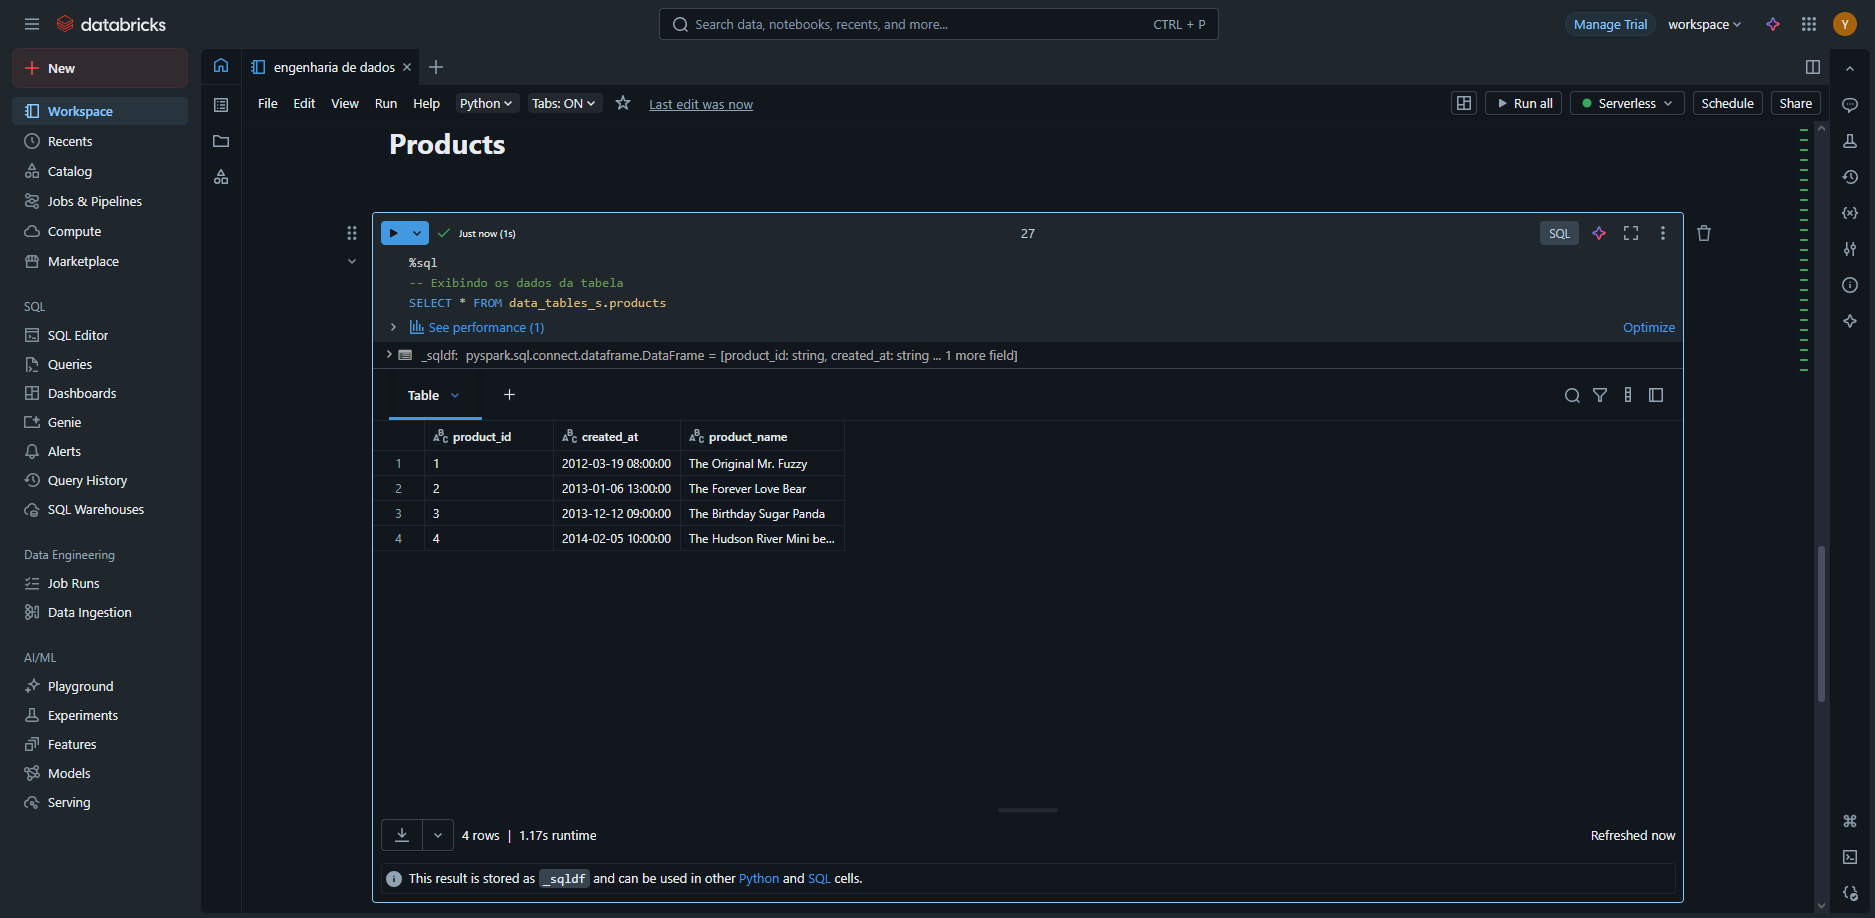

Como são poucos dados irei passar direto para etapa de criação da tabela com as tipagens.

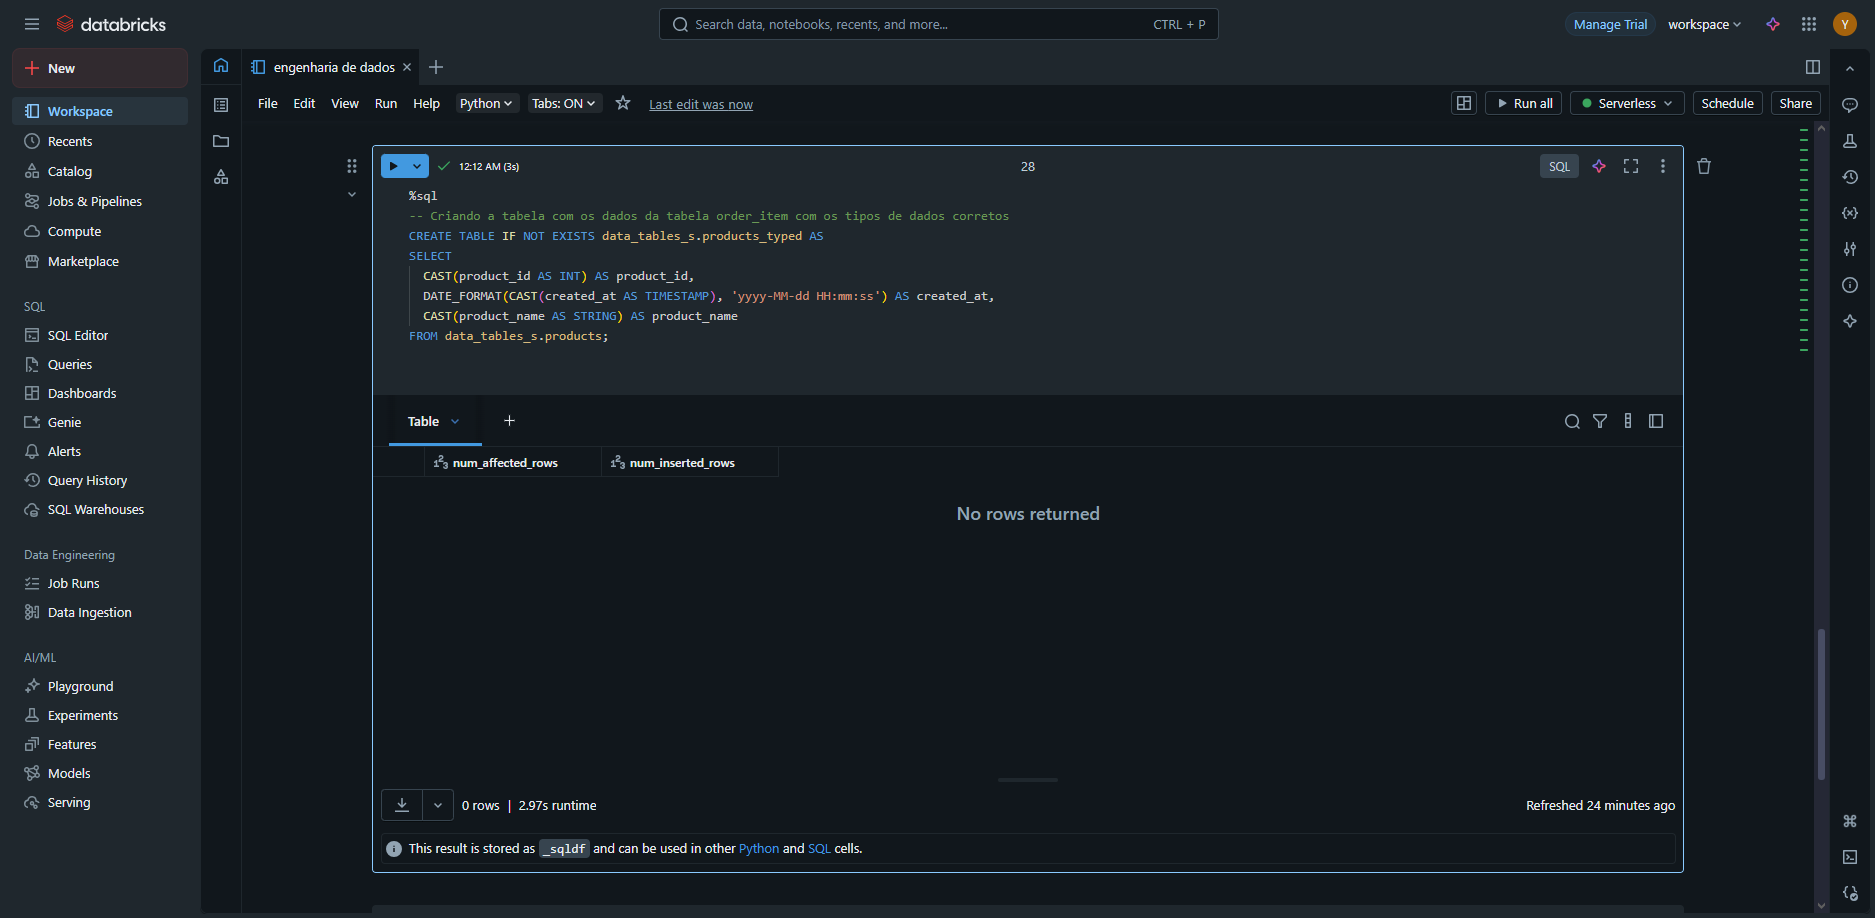

Vou agora exibir os dados da tabela para ter certeza de que eles estão sendo exibidos corretamente.

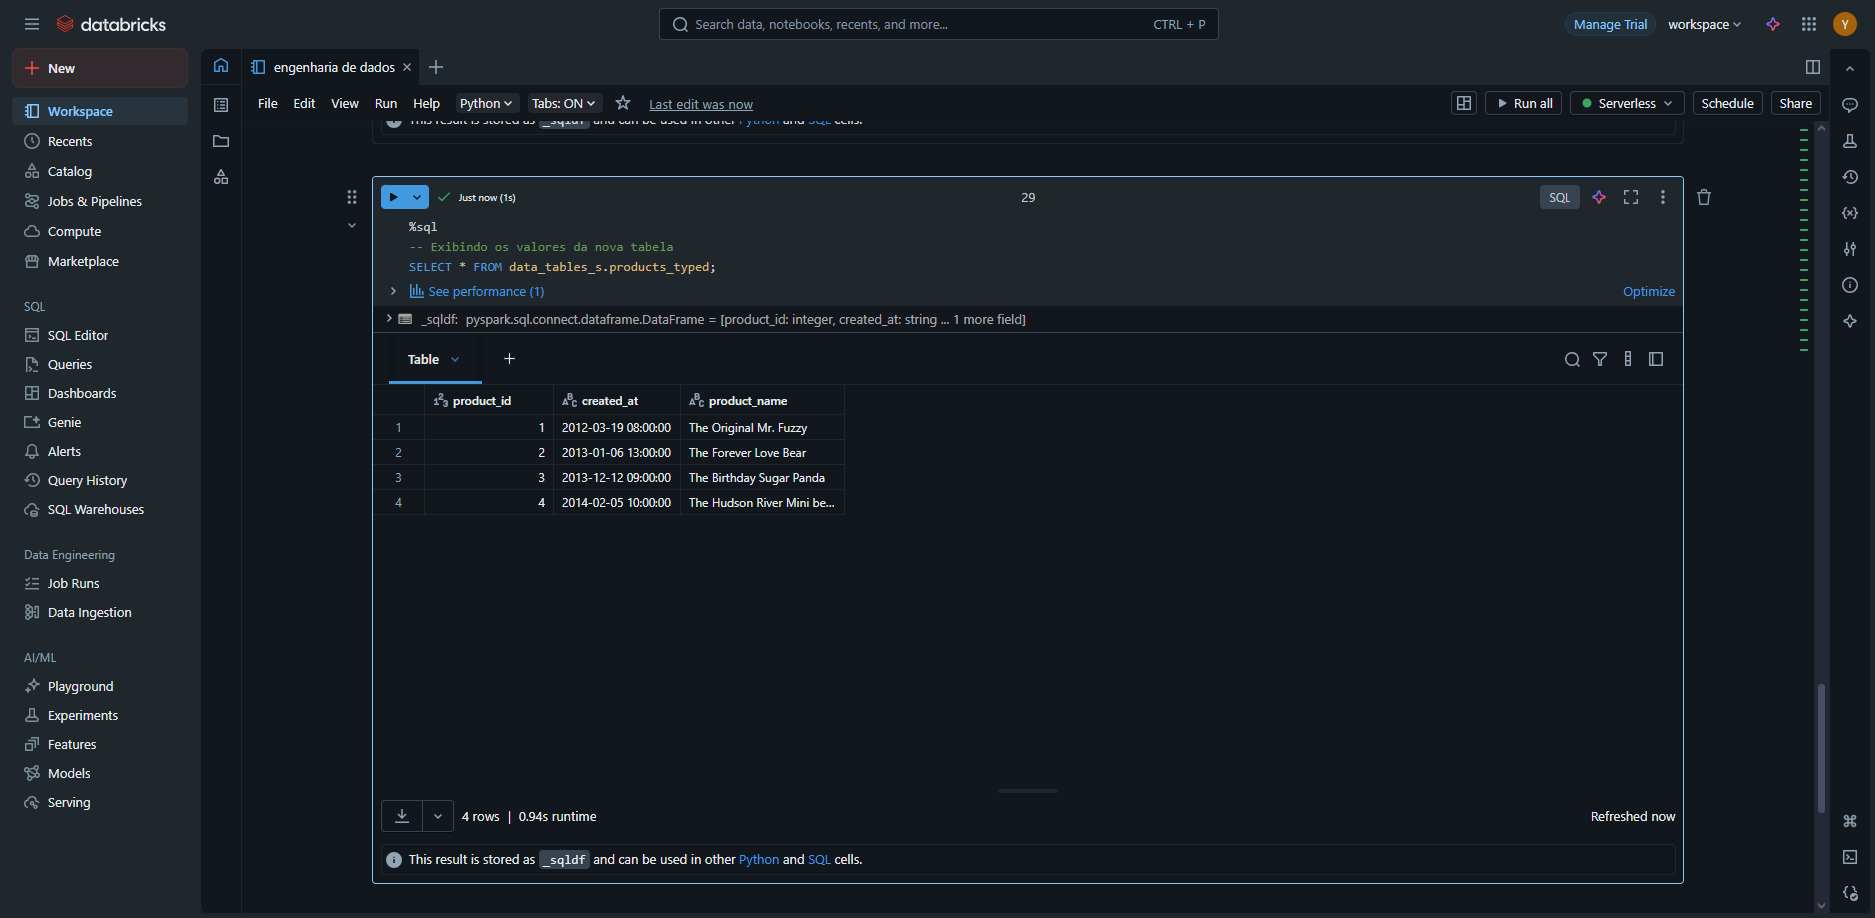

Como eram poucos valores eu não realizei os processos de preenchimendo de nulos. Caso fosse dados por streaming eu teria de realizar os processos para cada carga já que é um processo de ETL.

#### website_pageviews

Esta tabela indica as páginas web que os usuários navegaram dentro do website, então é para ser uma tabela densa assim como a de sessões.
Irei começar exibindo os primeiros 30 registros.

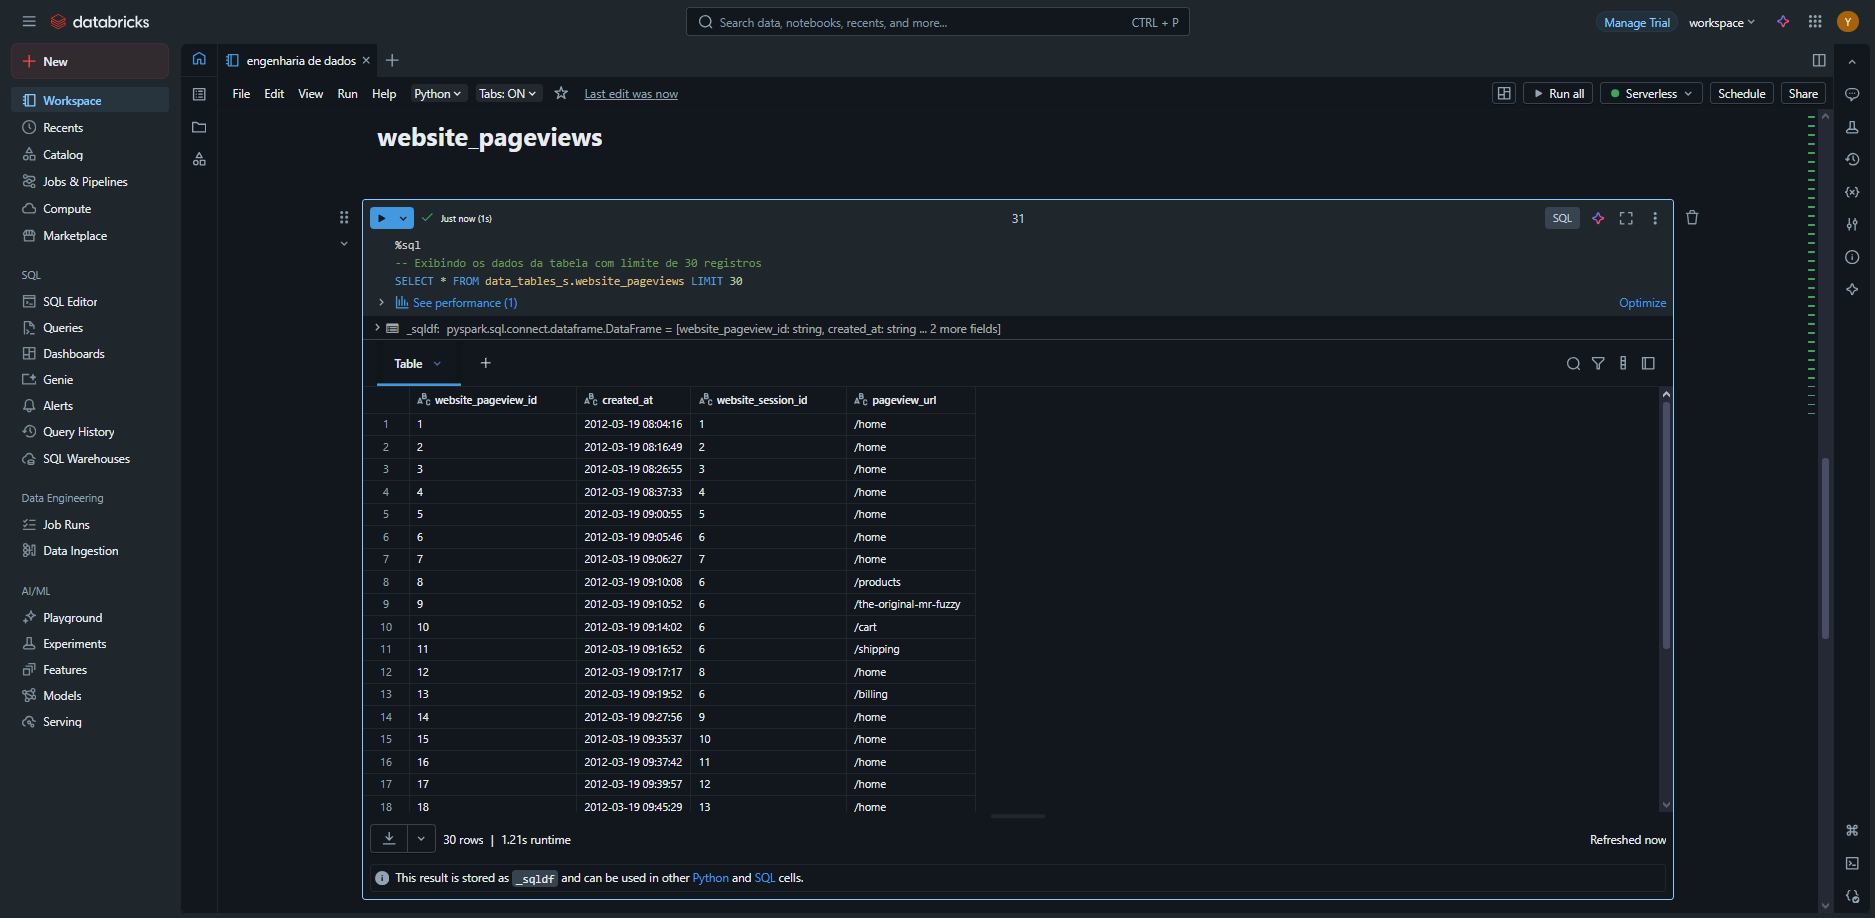

Agora farei a busca por valores nulos

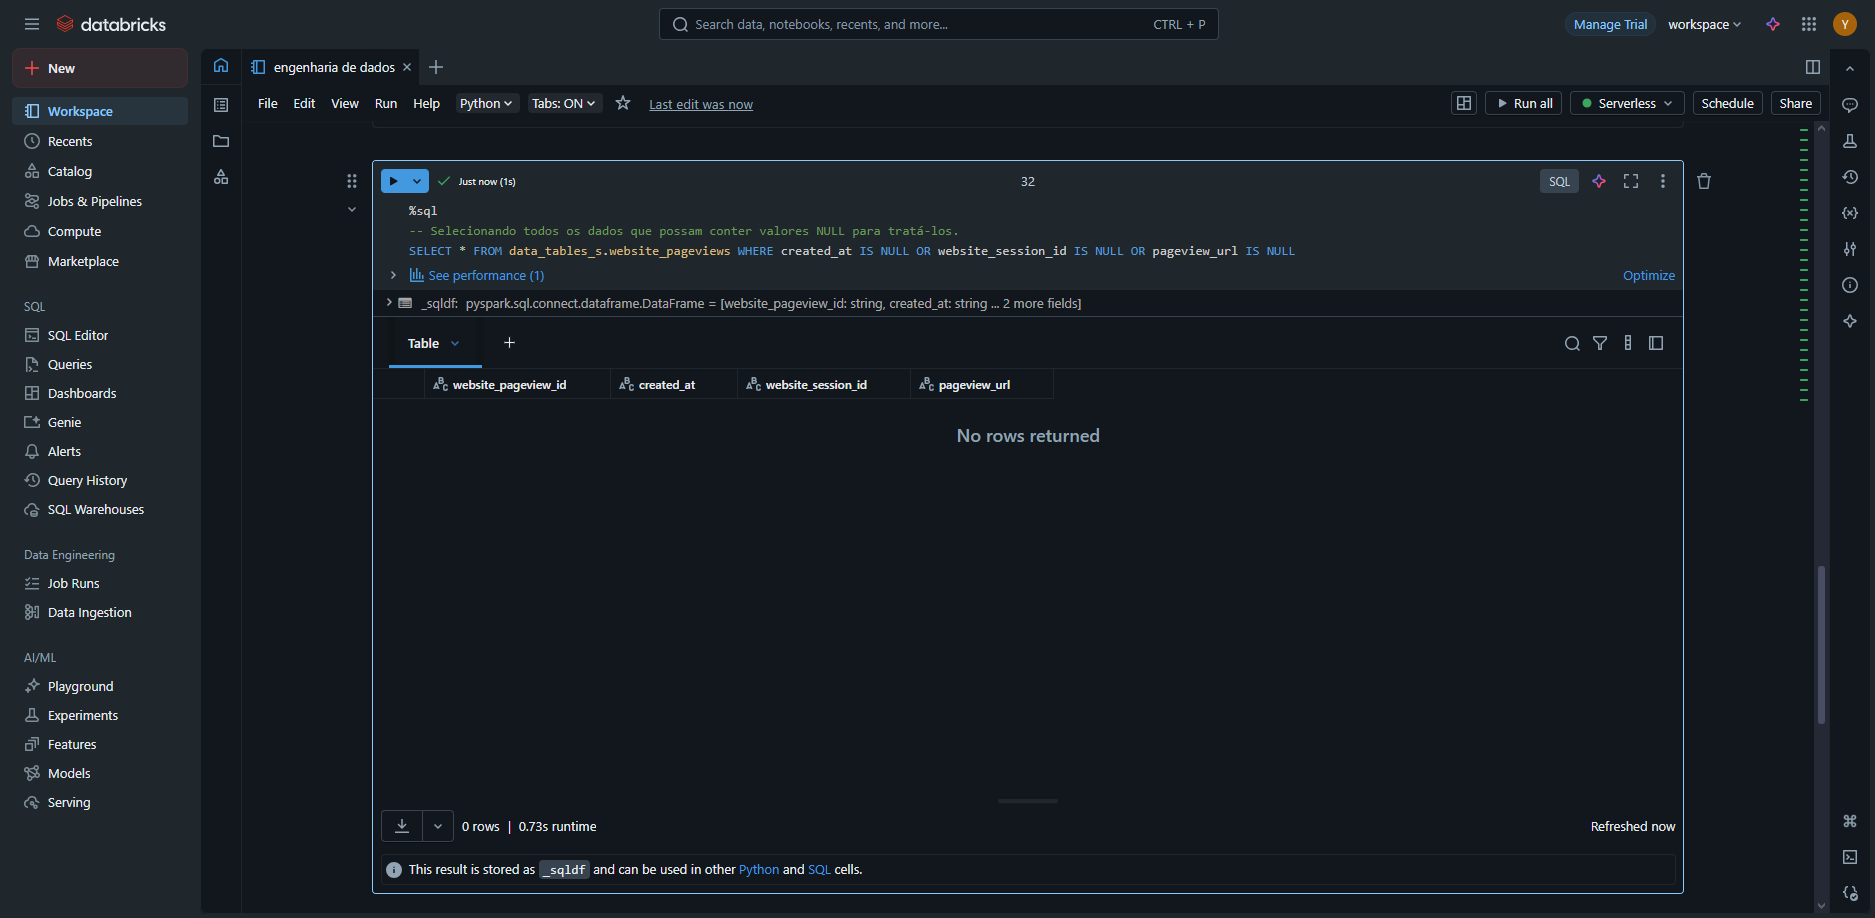

Como não há valores nulos, irei passar para etapa de criação da tabela com os tipos corretos.

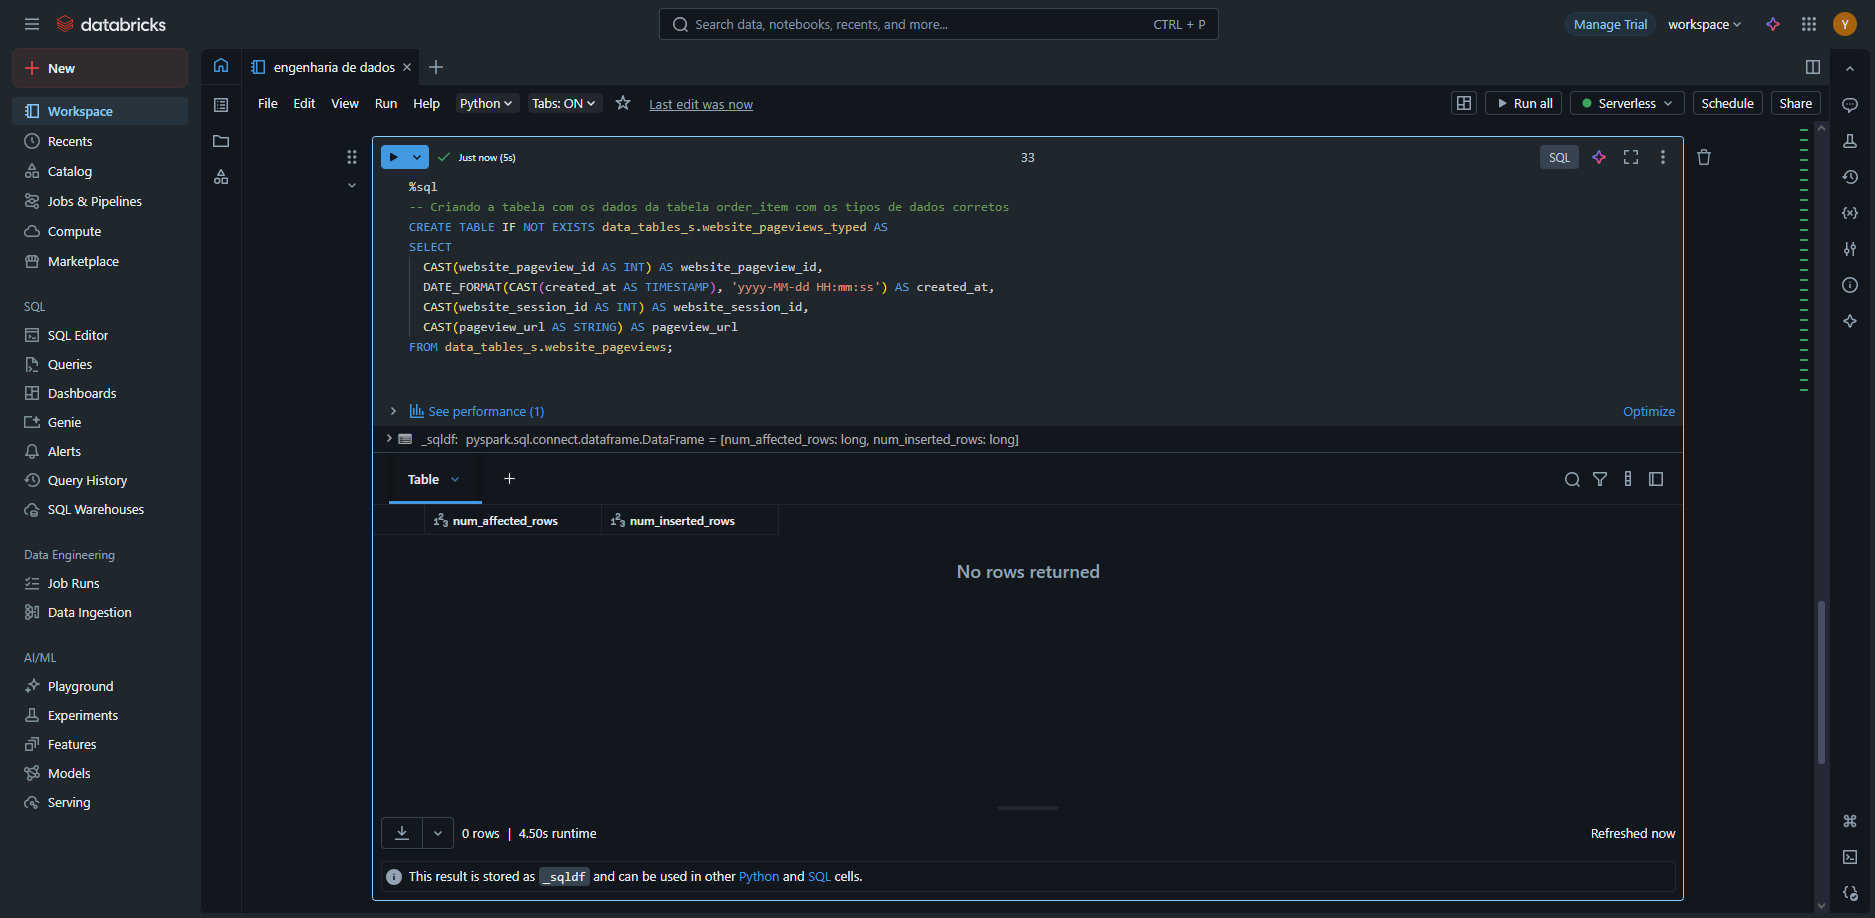

Irei exibir os valores mínimos e máximos de cada dado que não seja a id e que seja numérico.

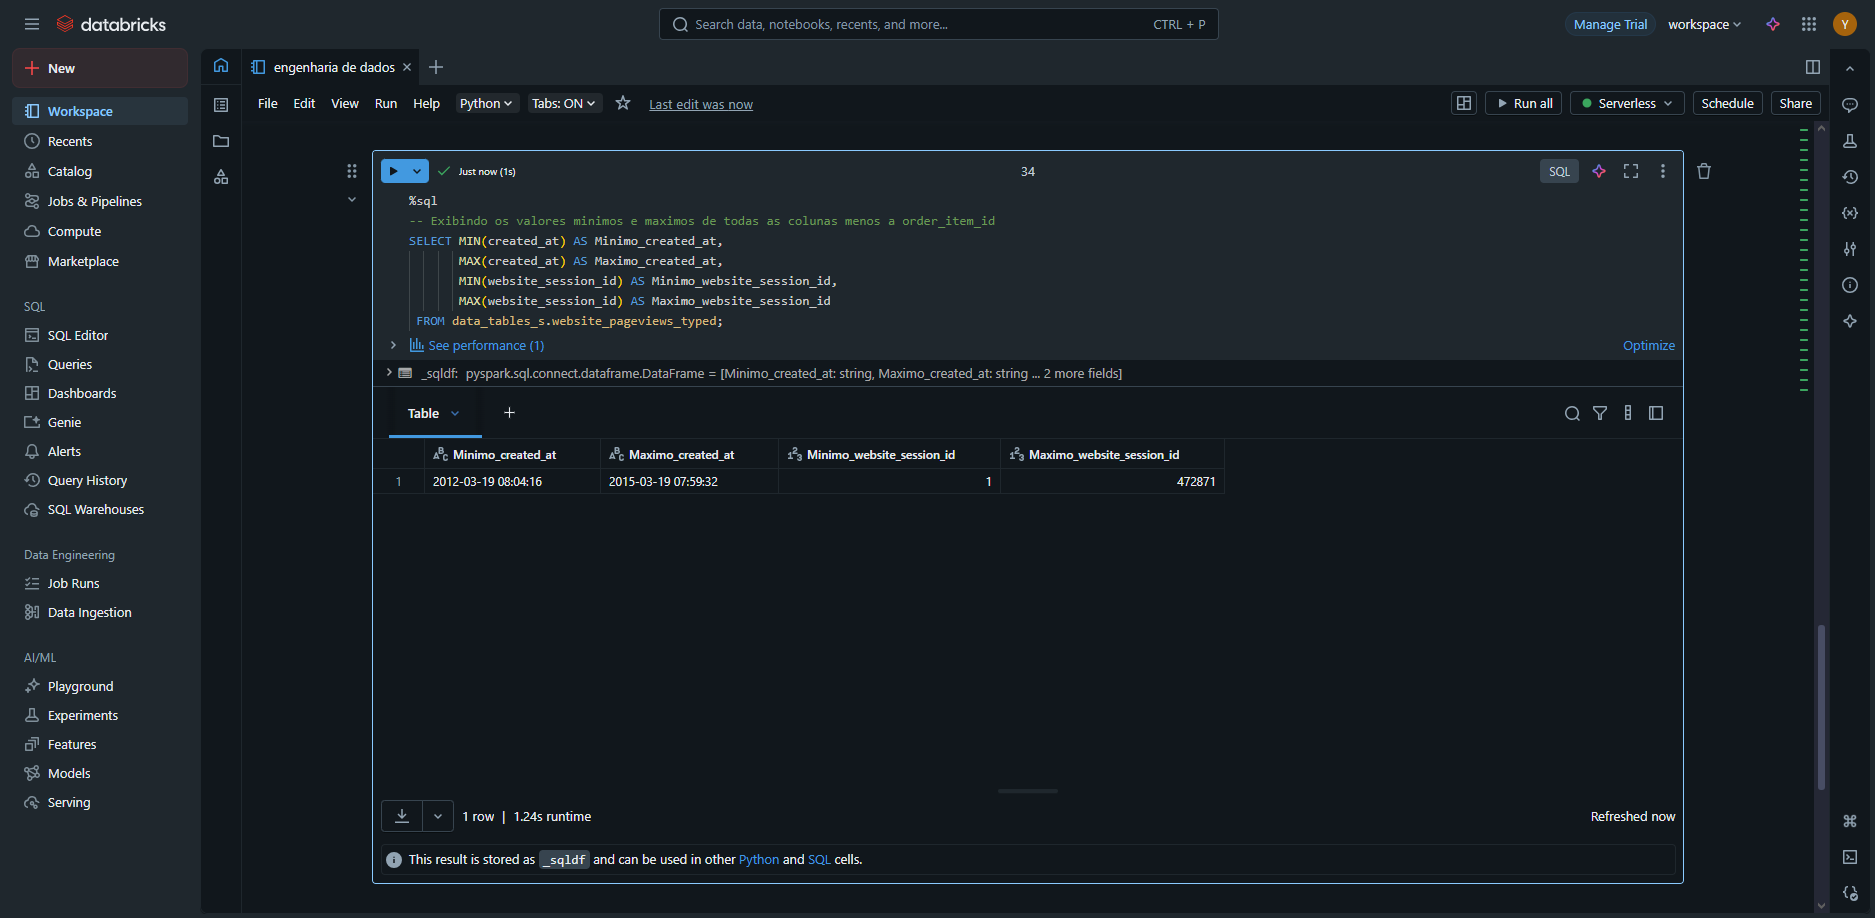

Para validar os dados que são Strings vou realizar as contagens de ocorrências de cara url e após irei comparar com o total de linhas.

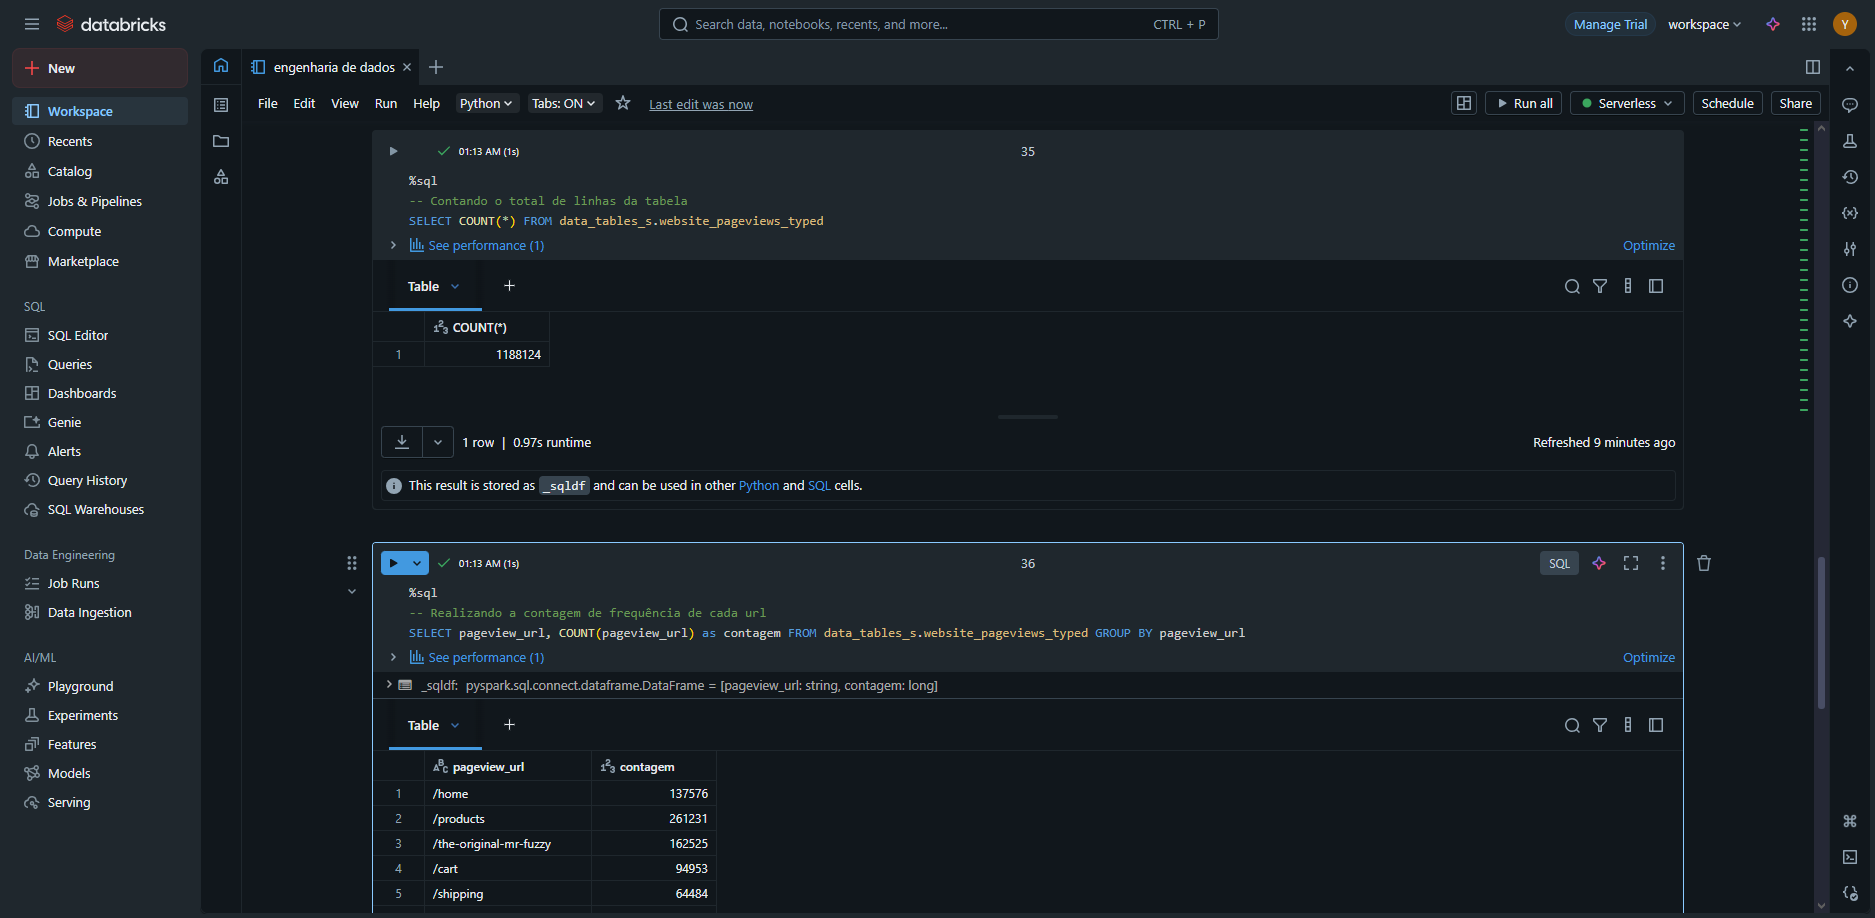

A seguinte tabela foi a retornada para as contagens de frequência:<br>
|pageview_url|contagem|
|---|---|
|/home|137576|
|/products|261231|
|/the-original-mr-fuzzy|162525|
|/cart|94953|
|/shipping|64484|
|/billing|3617|
|/thank-you-for-your-order|32313|
|/lander-1|47574|
|/billing-2|48441|
|/the-forever-love-bear|26033|
|/lander-2|131170|
|/lander-3|79000|
|/the-birthday-sugar-panda|19046|
|/lander-4|9385|
|/lander-5|68166|
|/the-hudson-river-mini-bear|2610|

<br>

A soma de todas as quantias da coluna contagens é exatamente a quantidade de linhas totais da tabela e também não há nenhuma variação dos dados que indique que ele não faz parte do conjunto.

#### website_session

Para esta tabela assim como para as outras irei realizar as validações dos dados e então começarei a ultima etapa do ETL, a carga (loading).<br>

Seguindo então irei exibir os dados.

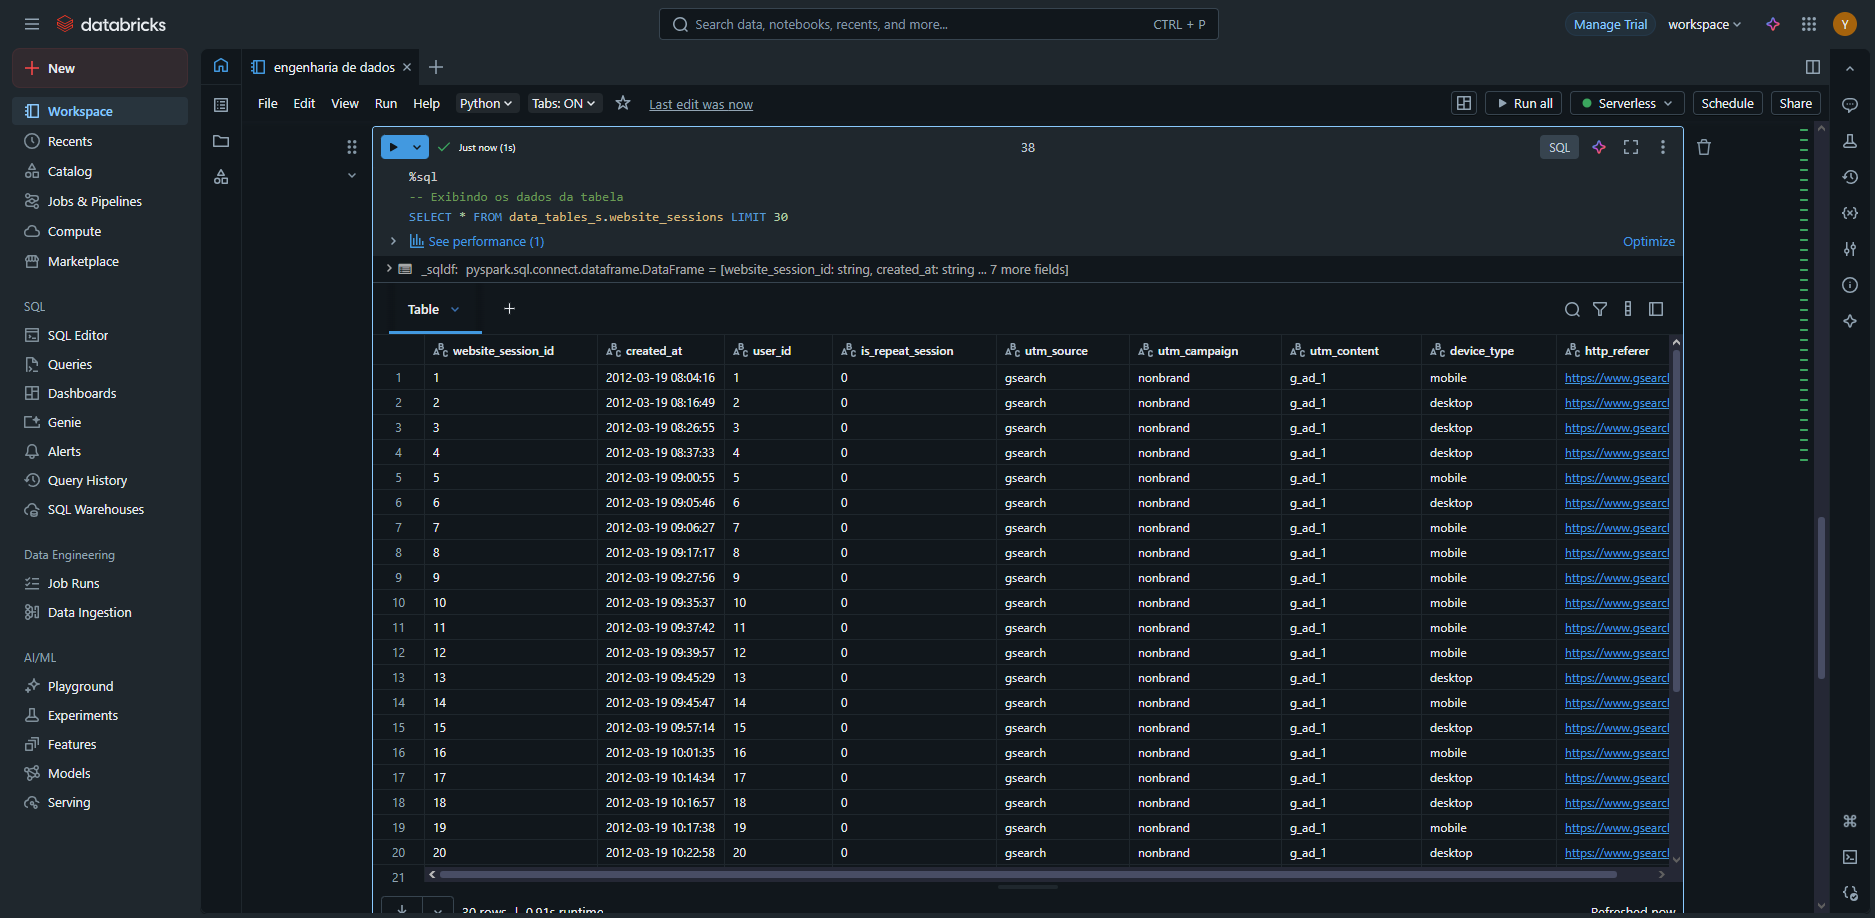

Com a primeira visualização pode-se notar que as colunas marcadas para exclusão ainda estão presentes, no processo aonde realizo a criação de uma nova tabela irei excluir estas colunas omitindo-as nos dados passados para a nova tabela.<br>
Pode-se notar também que os 19 registros não encontrados na tabela orders estão presentes nesta tabela, o que pode se concluir que estes 19 registros não geraram transações, isso indica a ausência da menção deles na tabela orders. Possivelmentre outros registros não detectados podem estar na mesma situação.

Seguindo então irei realizar a filtragem das linhas com algum valor nulo.

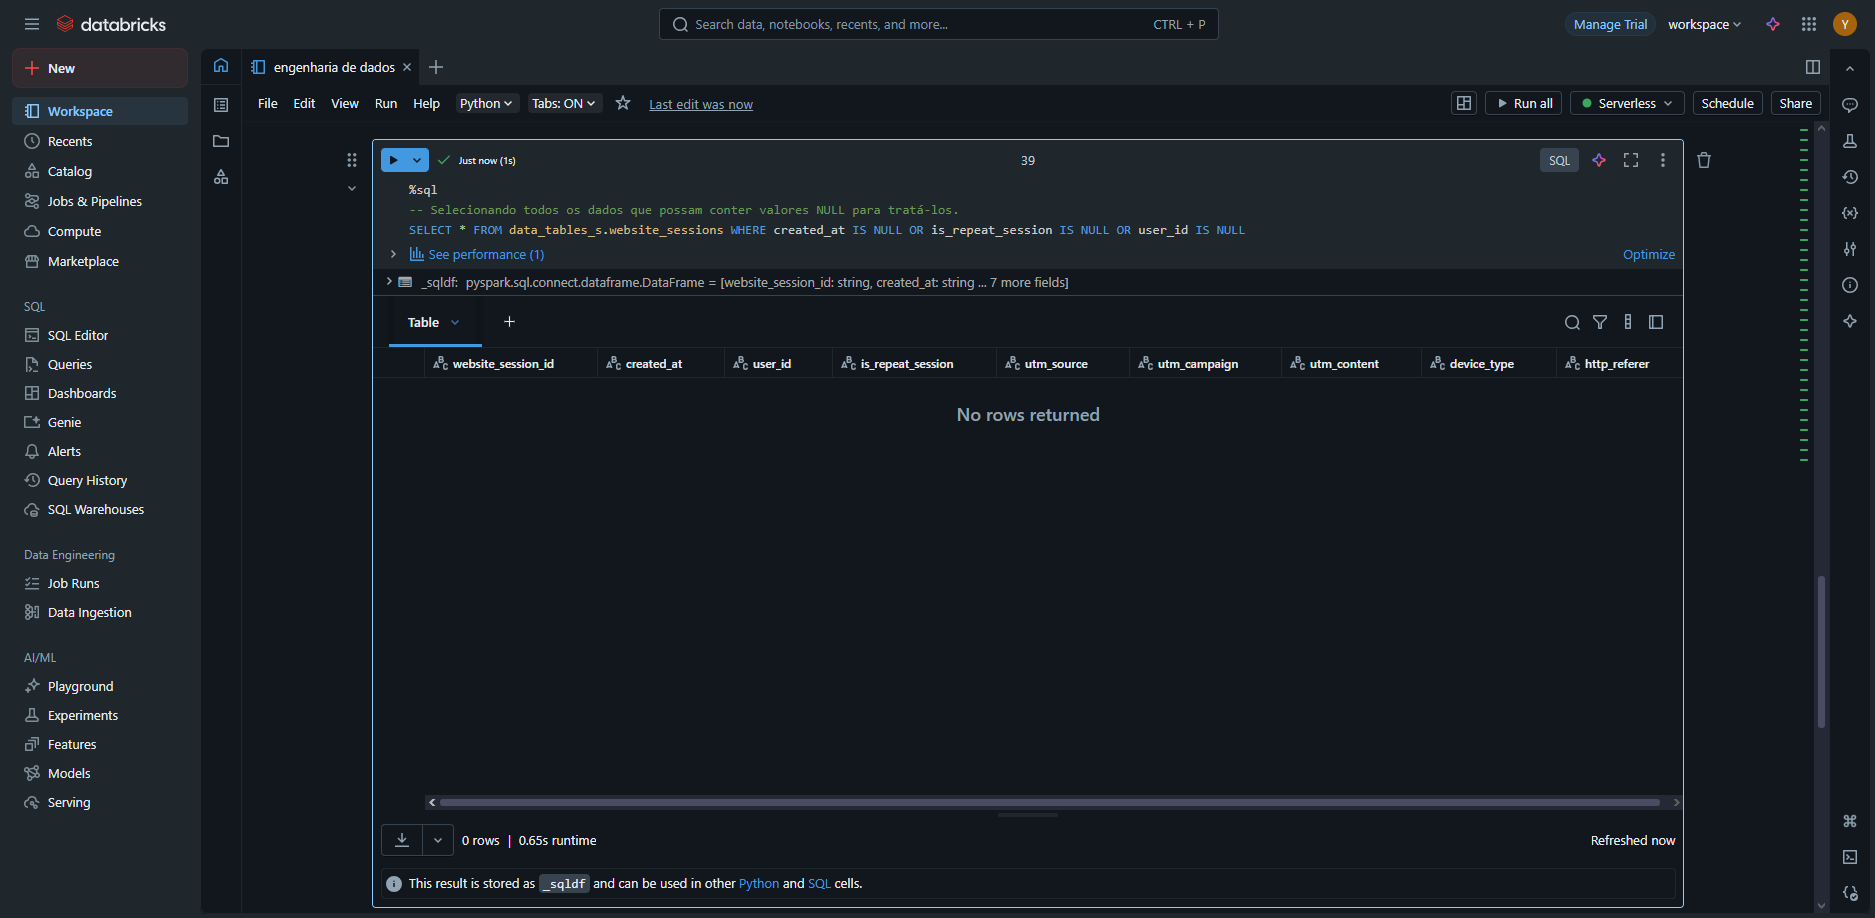

Como não foi detectado nenhum valor nulo, seguirei para criação da tabela com as tipagens de dados.

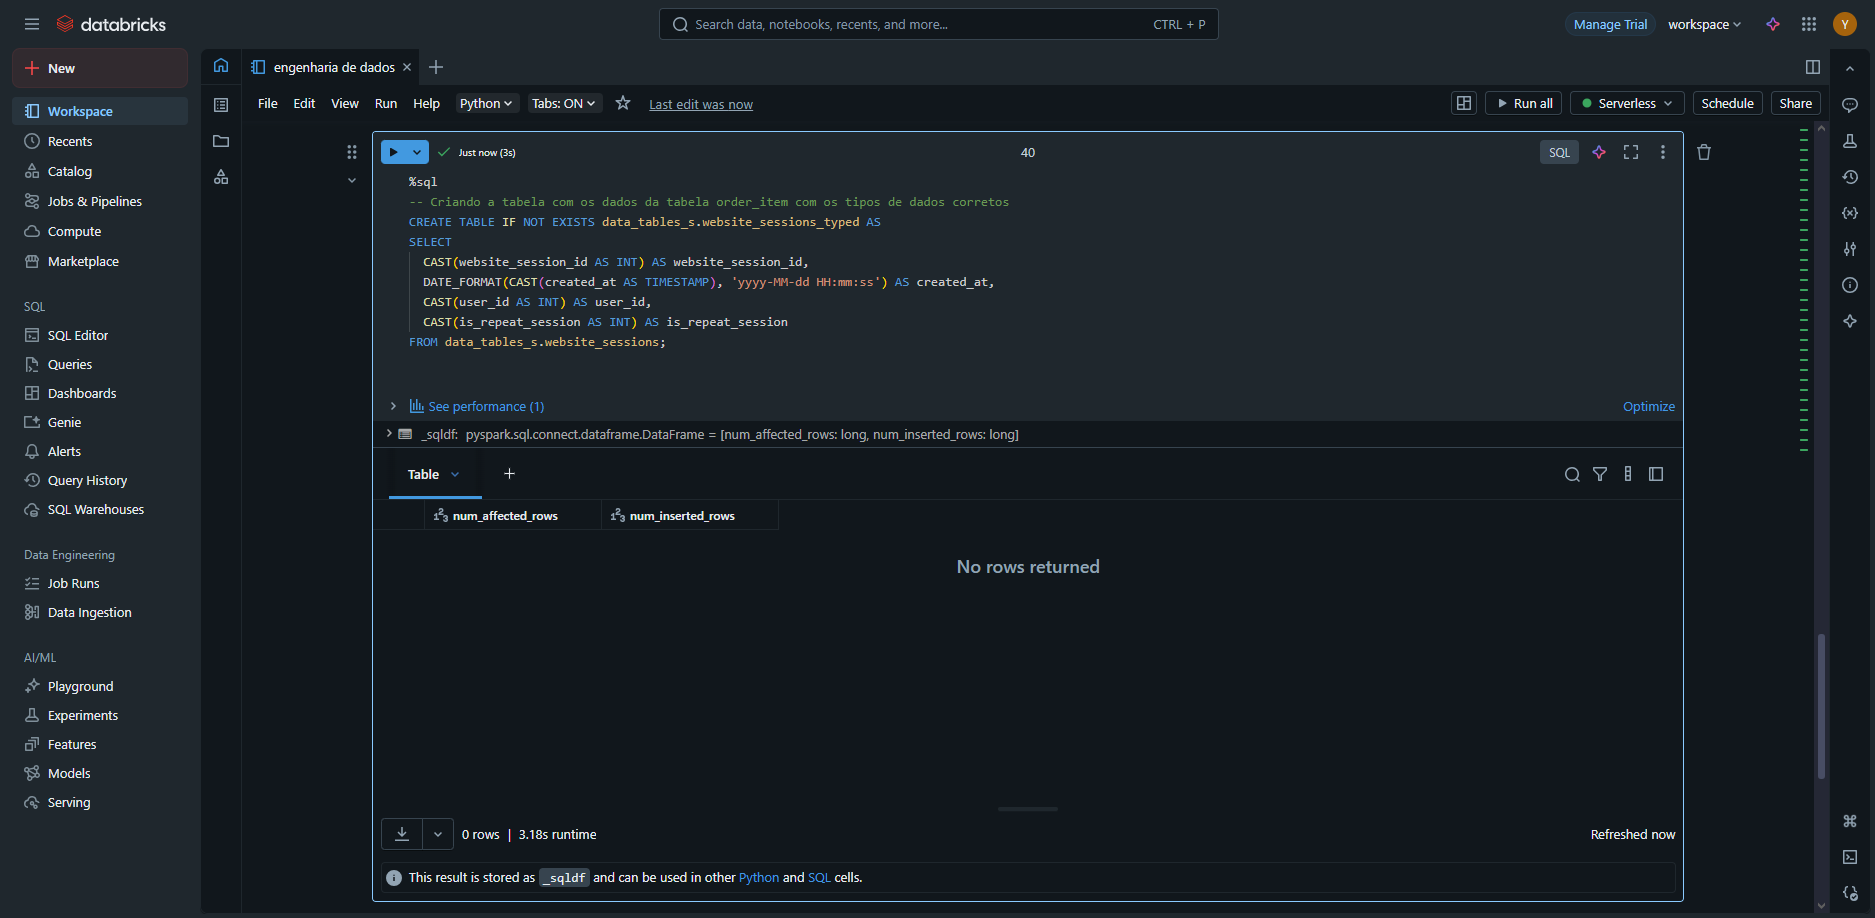

Para finalizar irei exibir os dados para ver se as colunas estão certas e então ver os valores mínimos e máximos da nova tabela.

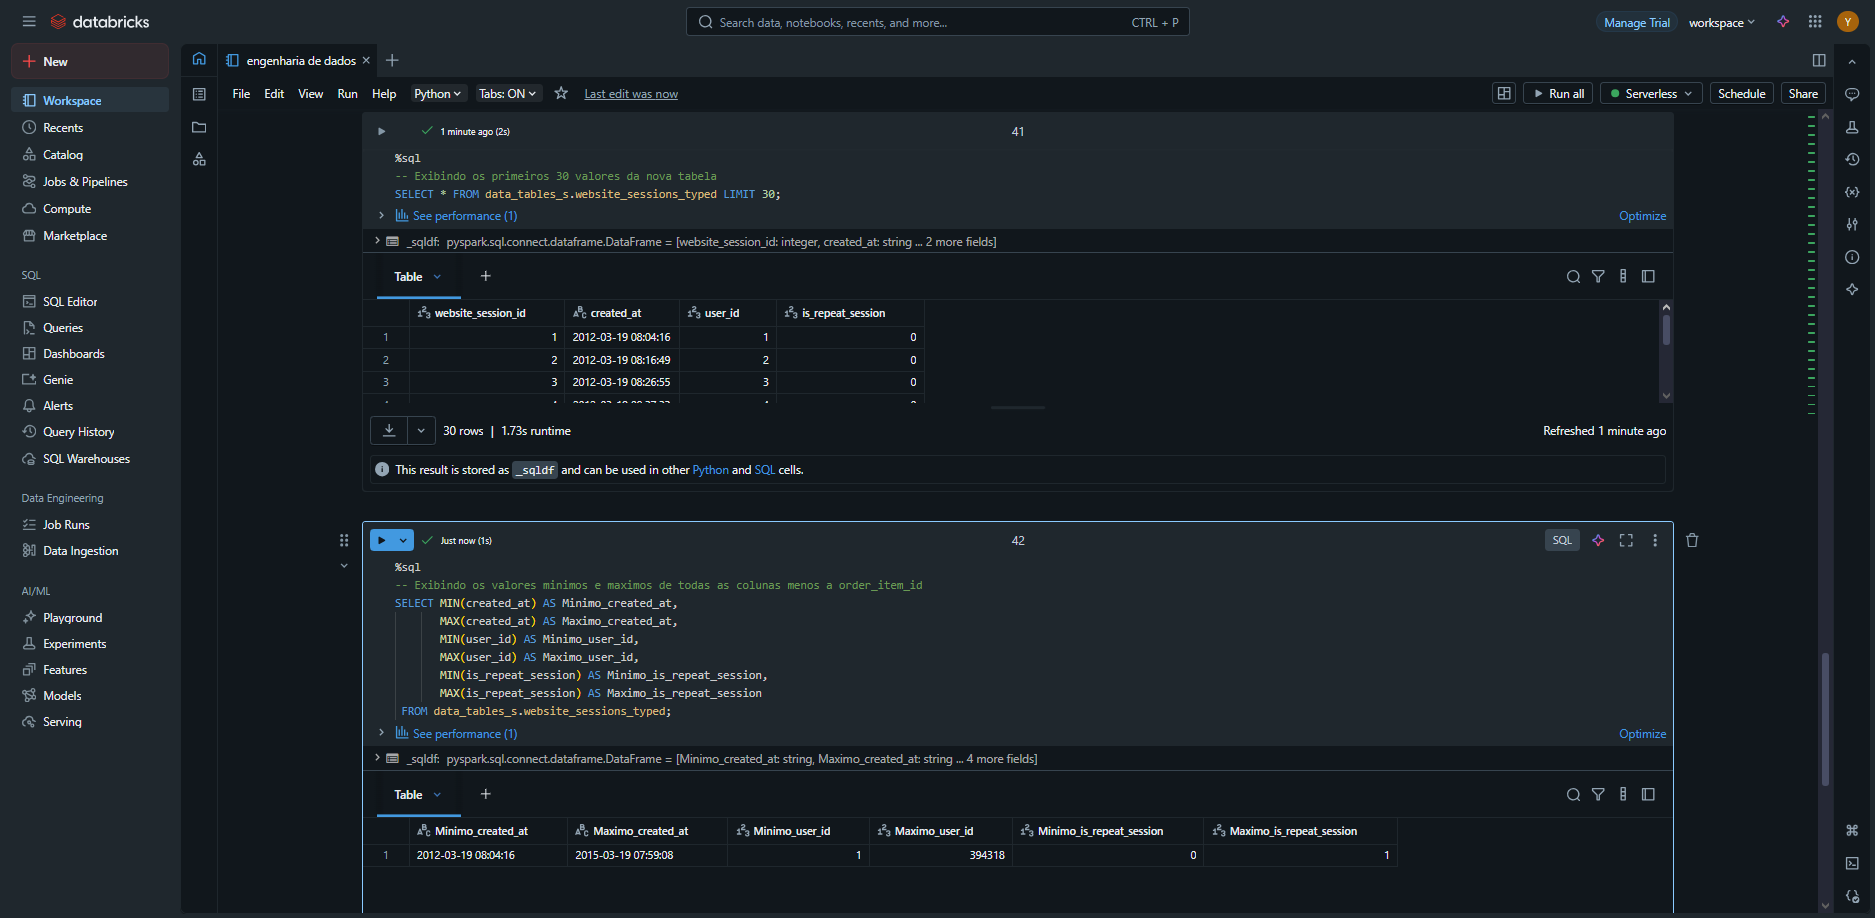

Visualizando os valores tive certeza de que as colunas estavam corretas, os valores mínimos e máximos também estão de acordo, irei seguir agora para a etapa de carga, onde irei construir o esquema estrela, com as tabelas dimensões e fato.

### Carga


Nesta etapa criarei o esquema estrela, irei começar pela tabela fato e logo depois para as dimensões.

#### Tabela fato_order_items

Nesta tabela irei colocar os dados mais importantes para responder perguntas de negócio, como order_id, product_id, user_id, website_session_id, created_at, price_usd, cogs_usd.<br><br> Sendo a chave primária order_item_id.

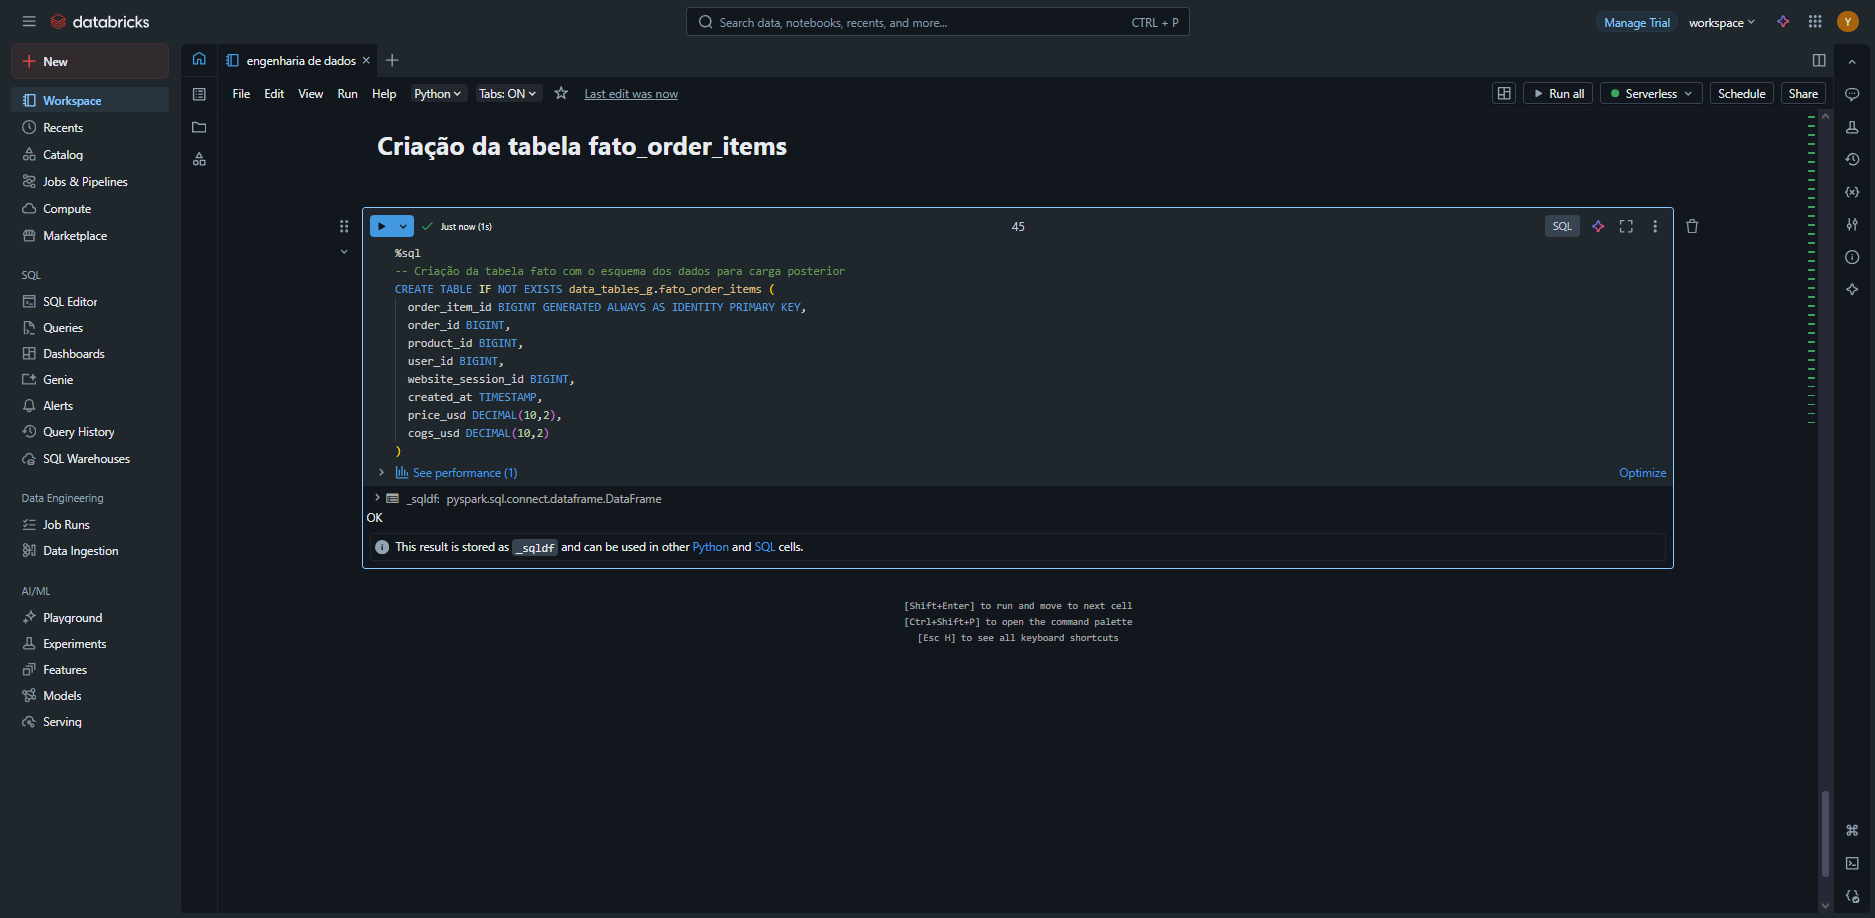

A inserção dos dados eu deixarei para etapas posteriores.

#### Dimensão dim_products

Para dimensão do produto usarei as mesmas colunas da tabela products.<br><br>

Sendo product_id a chave primária.

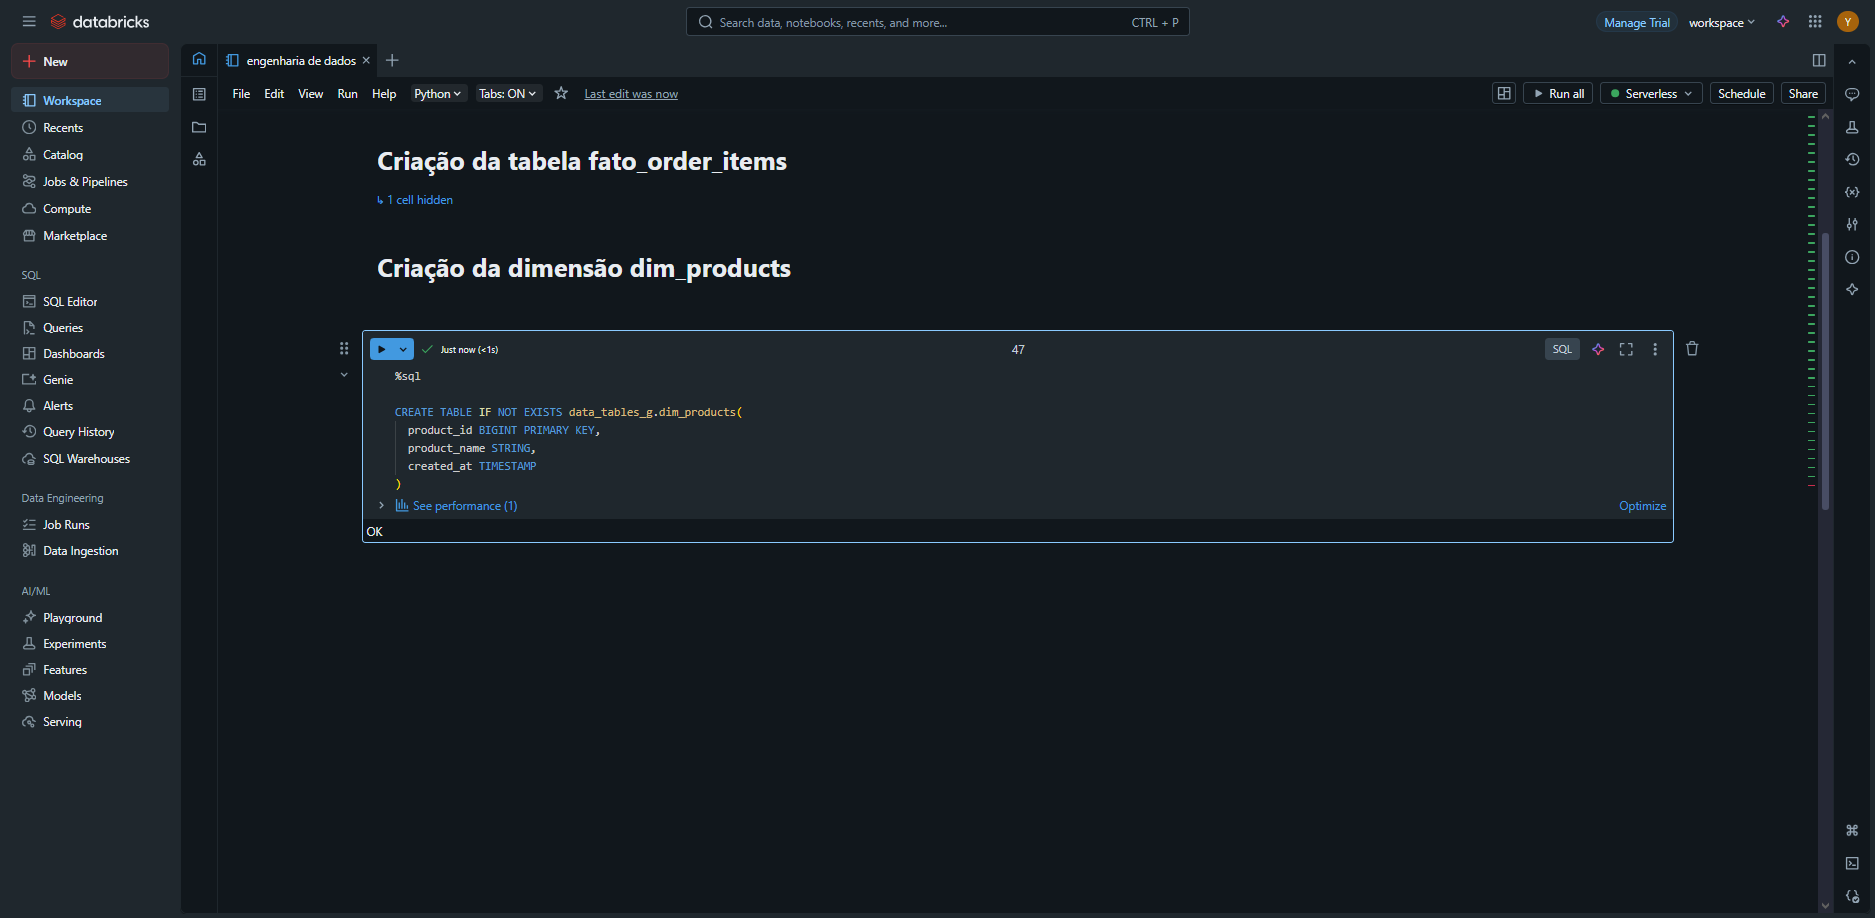

#### Dimensão dim_users



Para a dimensão do usuário irei informar apenas 1 campo, sendo este user_id que será também a chave primária.

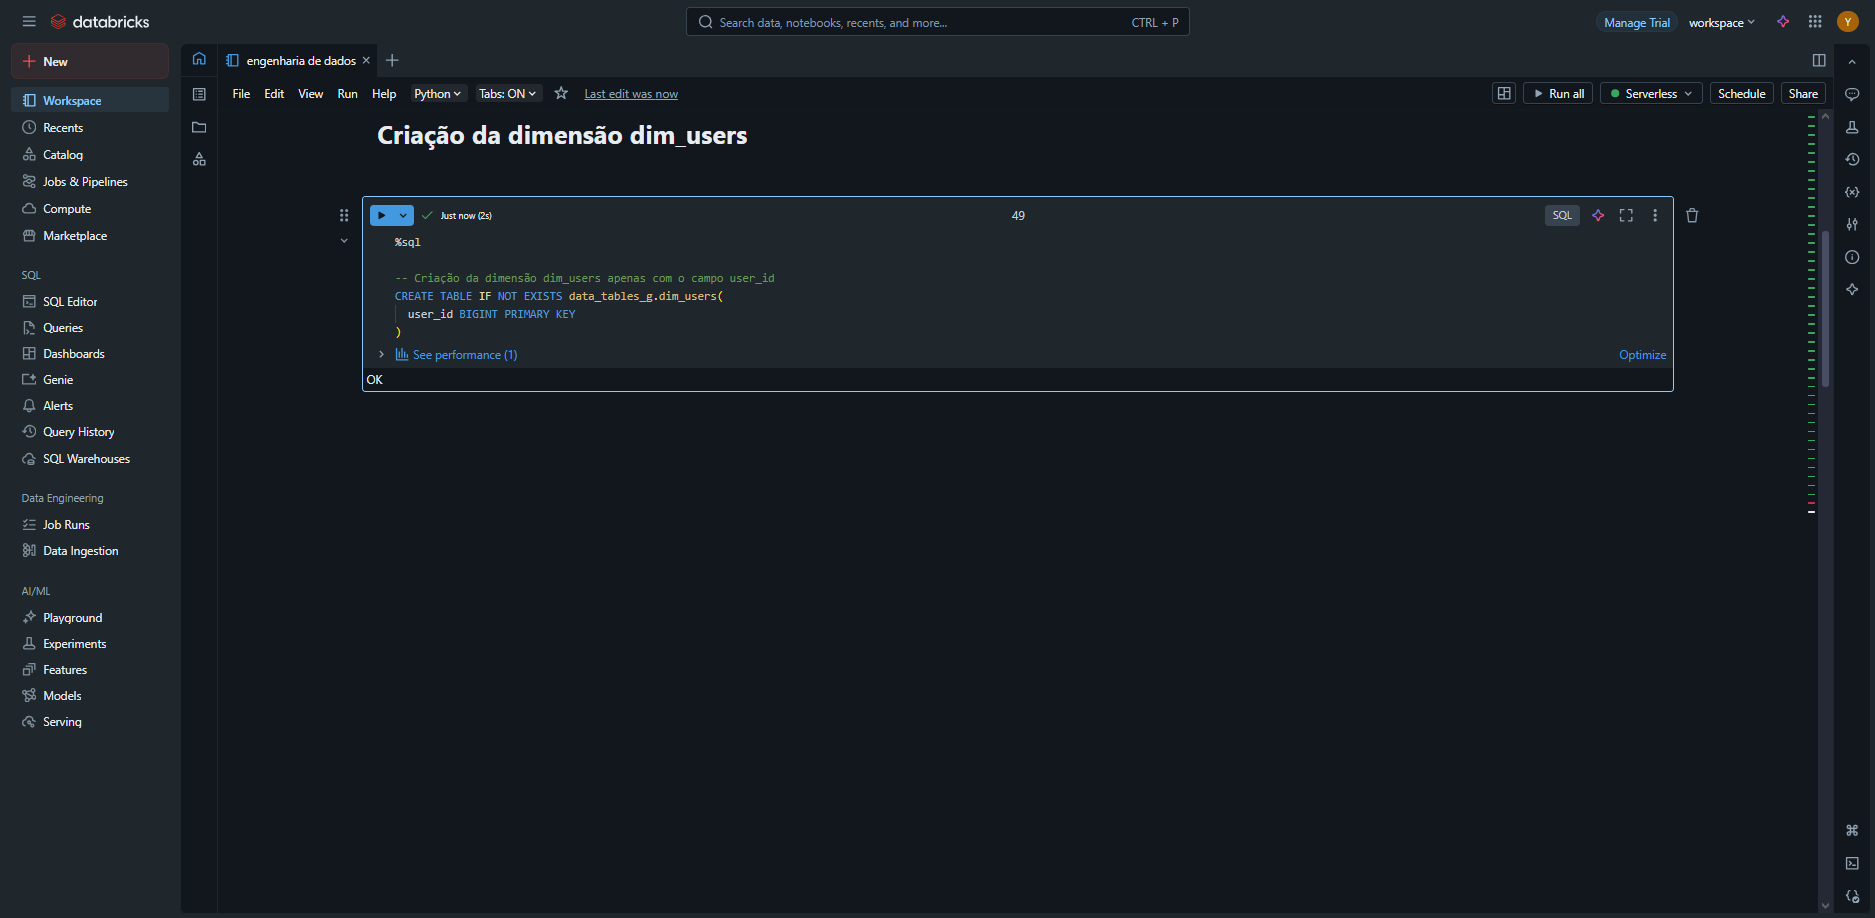

#### Dimensão dim_date

Esta dimensão será responsável pelo controle de tempo, preencherei com script posteriormente. Seus campos serão date_id, year, month e day. A chave primária será date_id sendo a data formada pelos outros campos de ano, mes, dia.

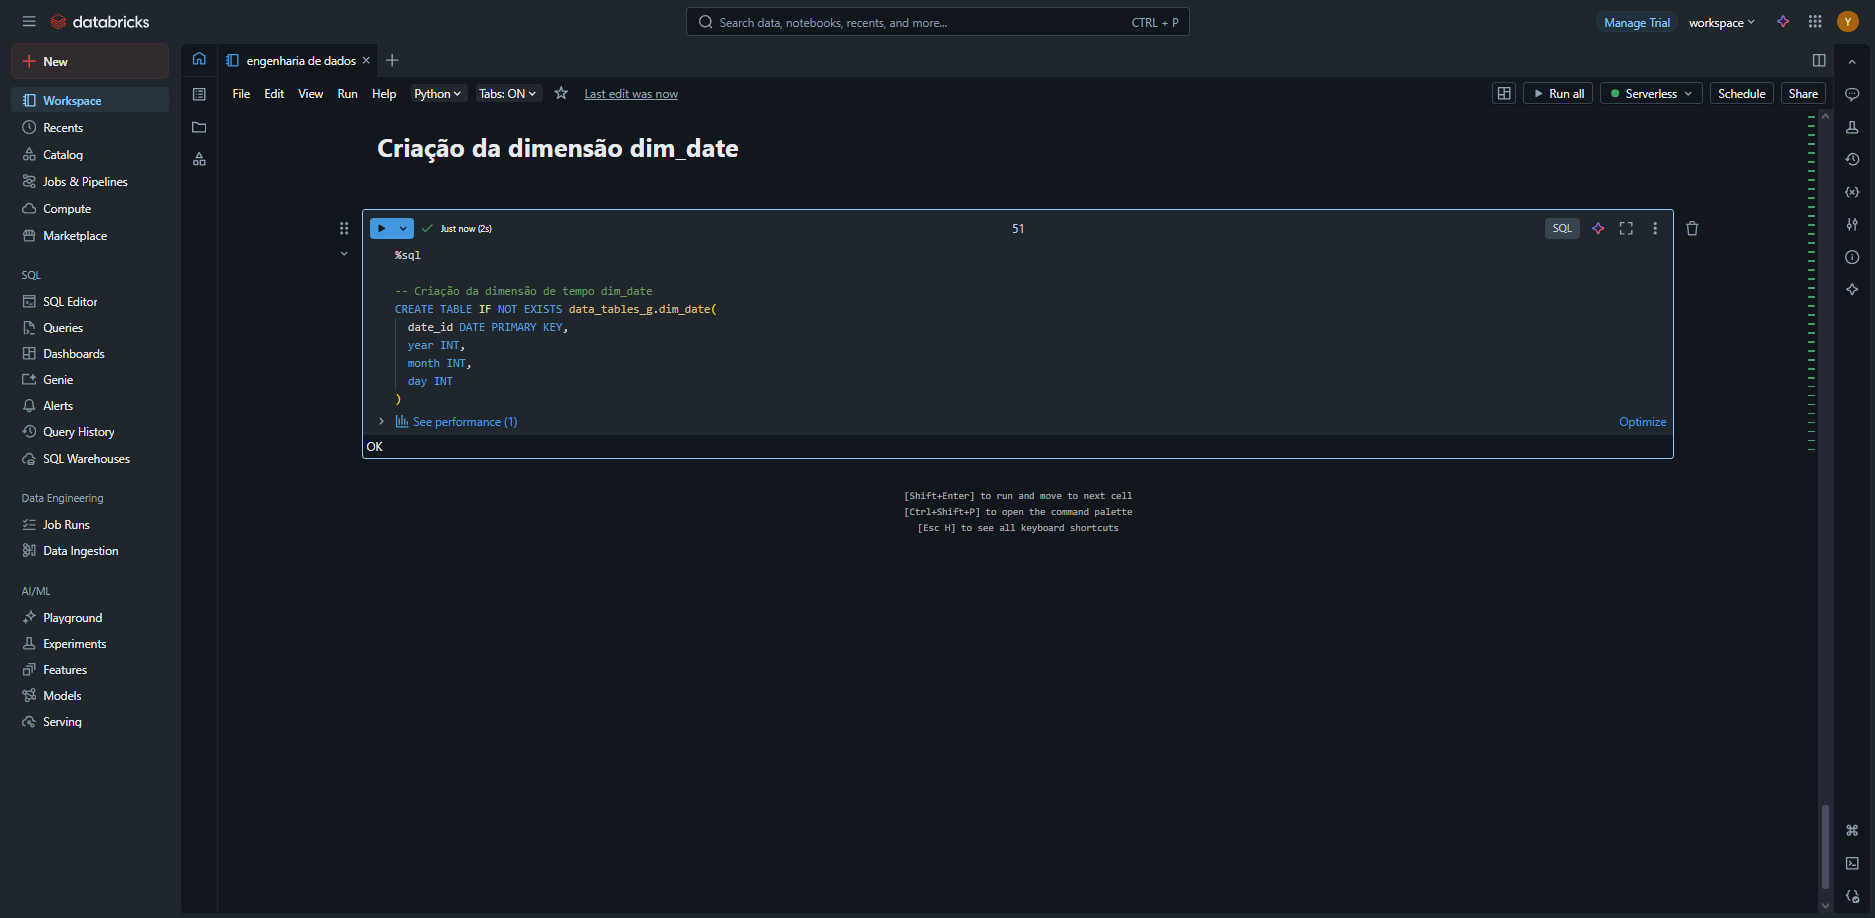

#### Dimensão dim_pageview

Esta dimensão irá conter o caminho do usuário pela página, as colunas contidas na tabela são: website_pageview_id, website_session_id, user_id, created_at, pageview_url. A chave primária será website_pageview_id.

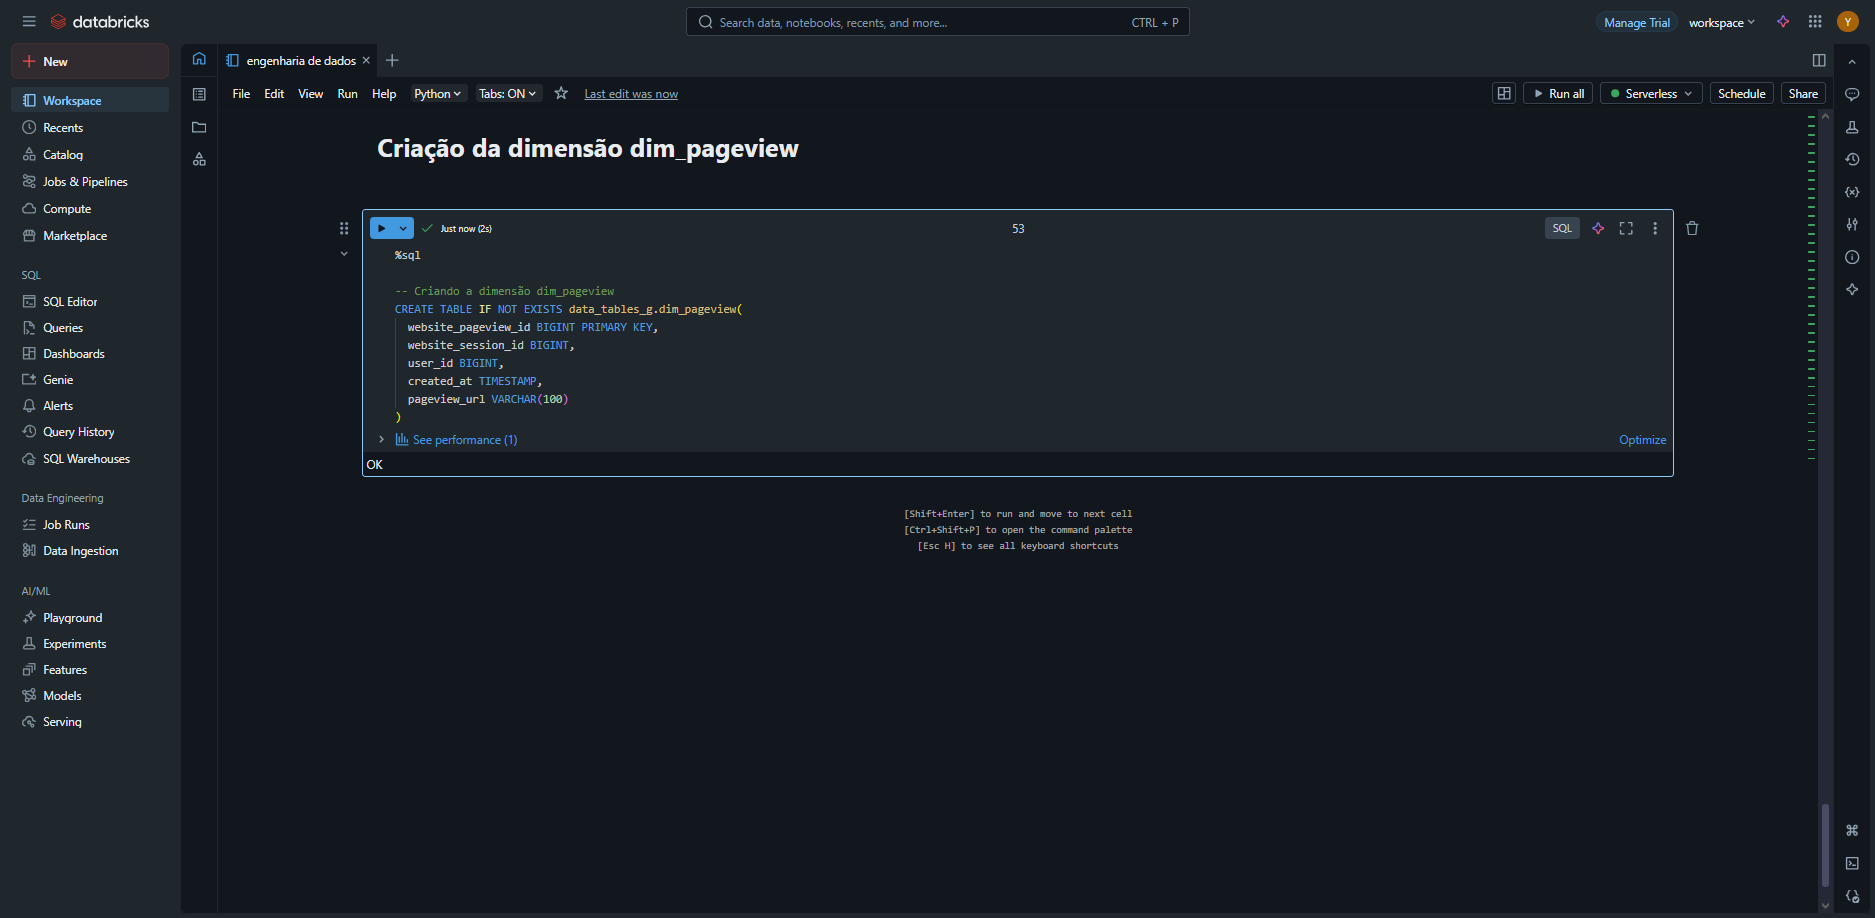

#### Dimensão dim_refunds

Nesta dimensão irei colocar os principais campos necessários para futuras análises.<br>
Os campos são:<br>
- order_refund_id -> sendo a chave primária
- order_id
- user_id
- product_id
- created_at

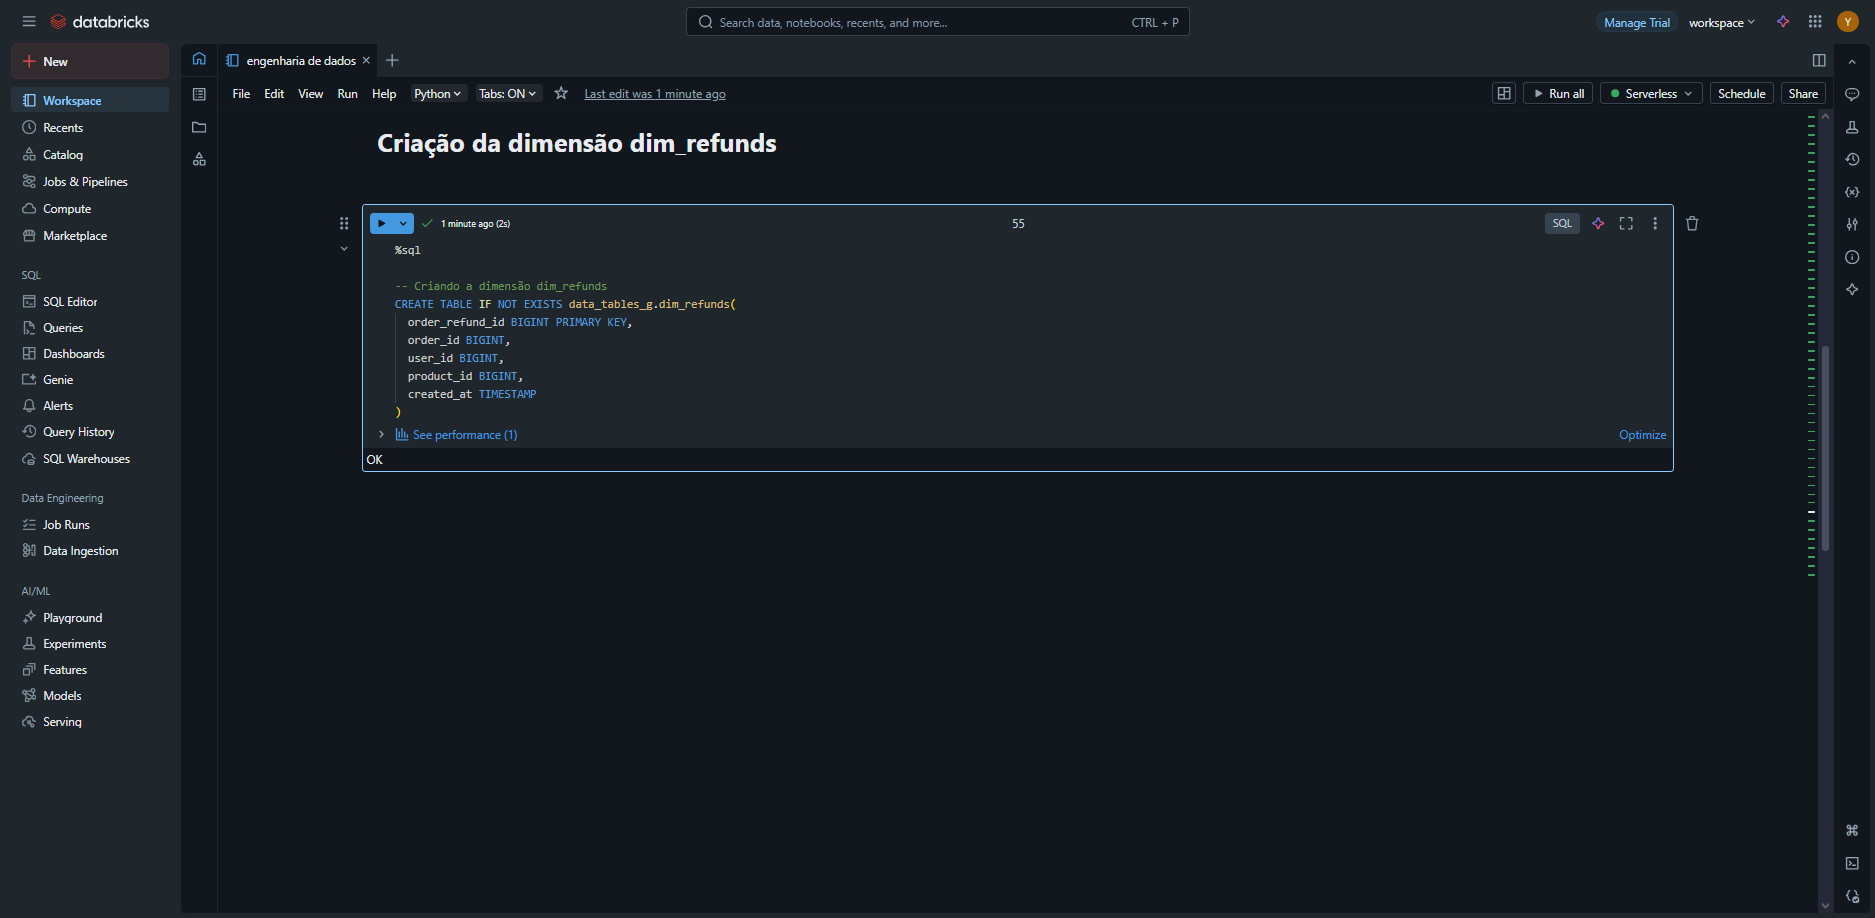

#### Carga dos dados para a tabela fato e dimensões

##### Carga para tabela fato fato_order_items, utilizando as duas tabelas que compõem a maior parte das informações importantes order_items e orders.

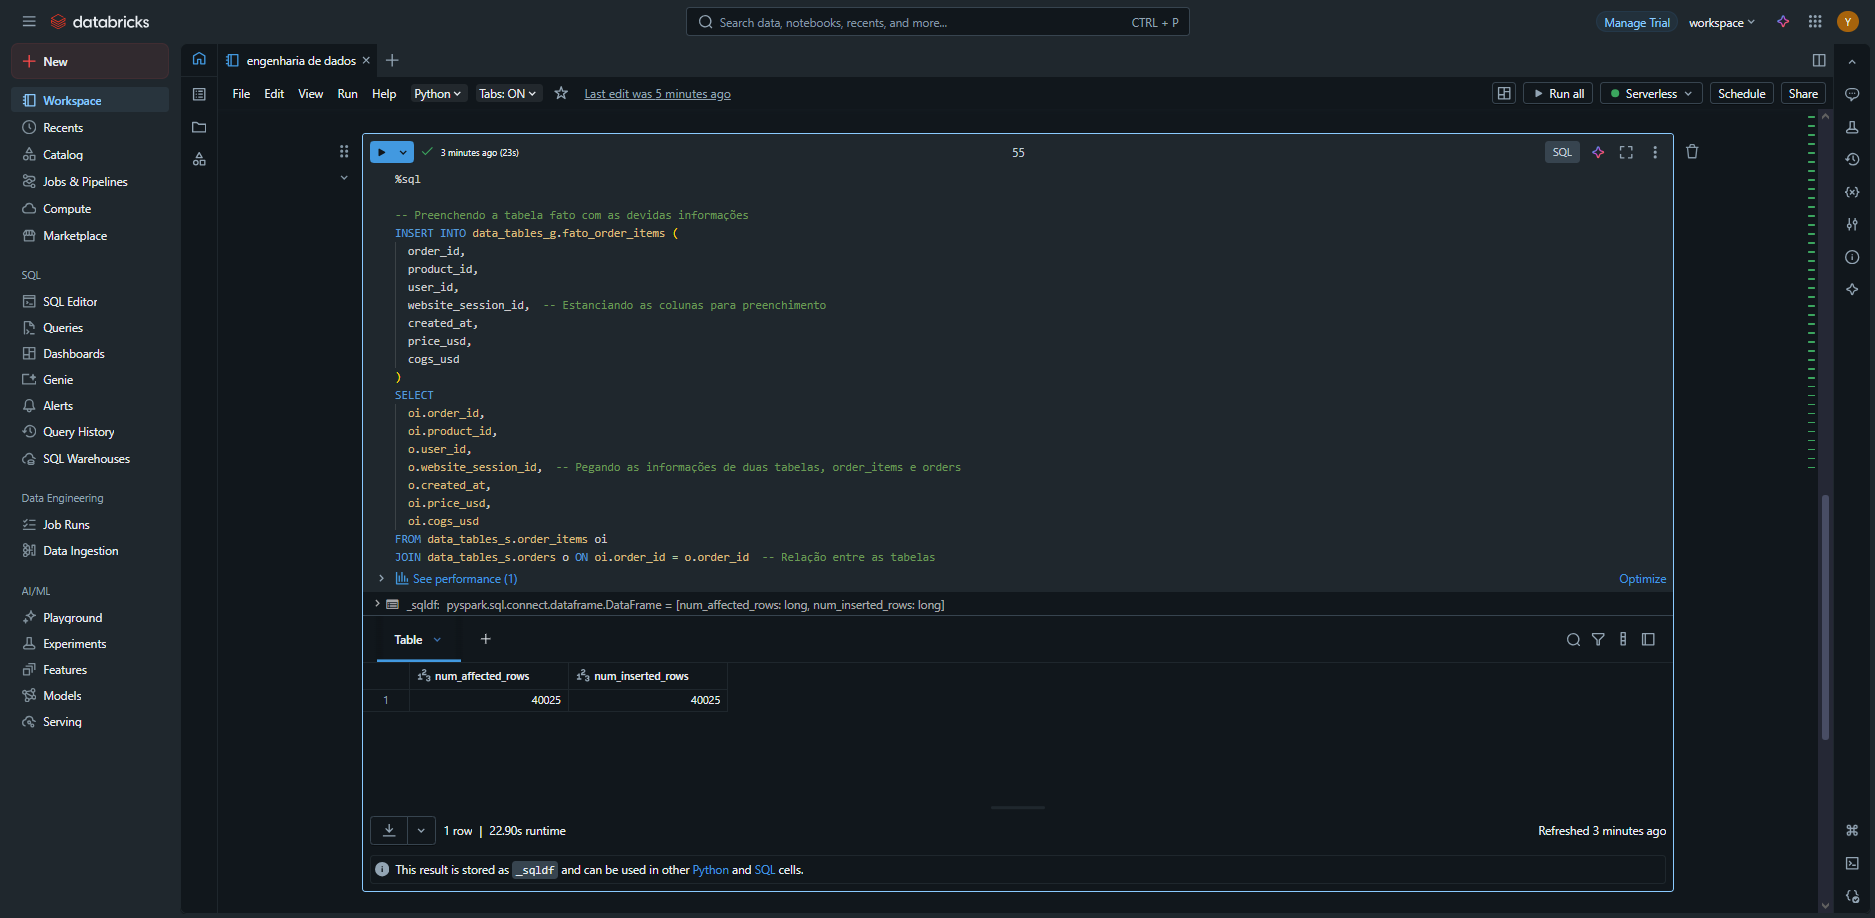

Listando os dados da tabela fato_order_items

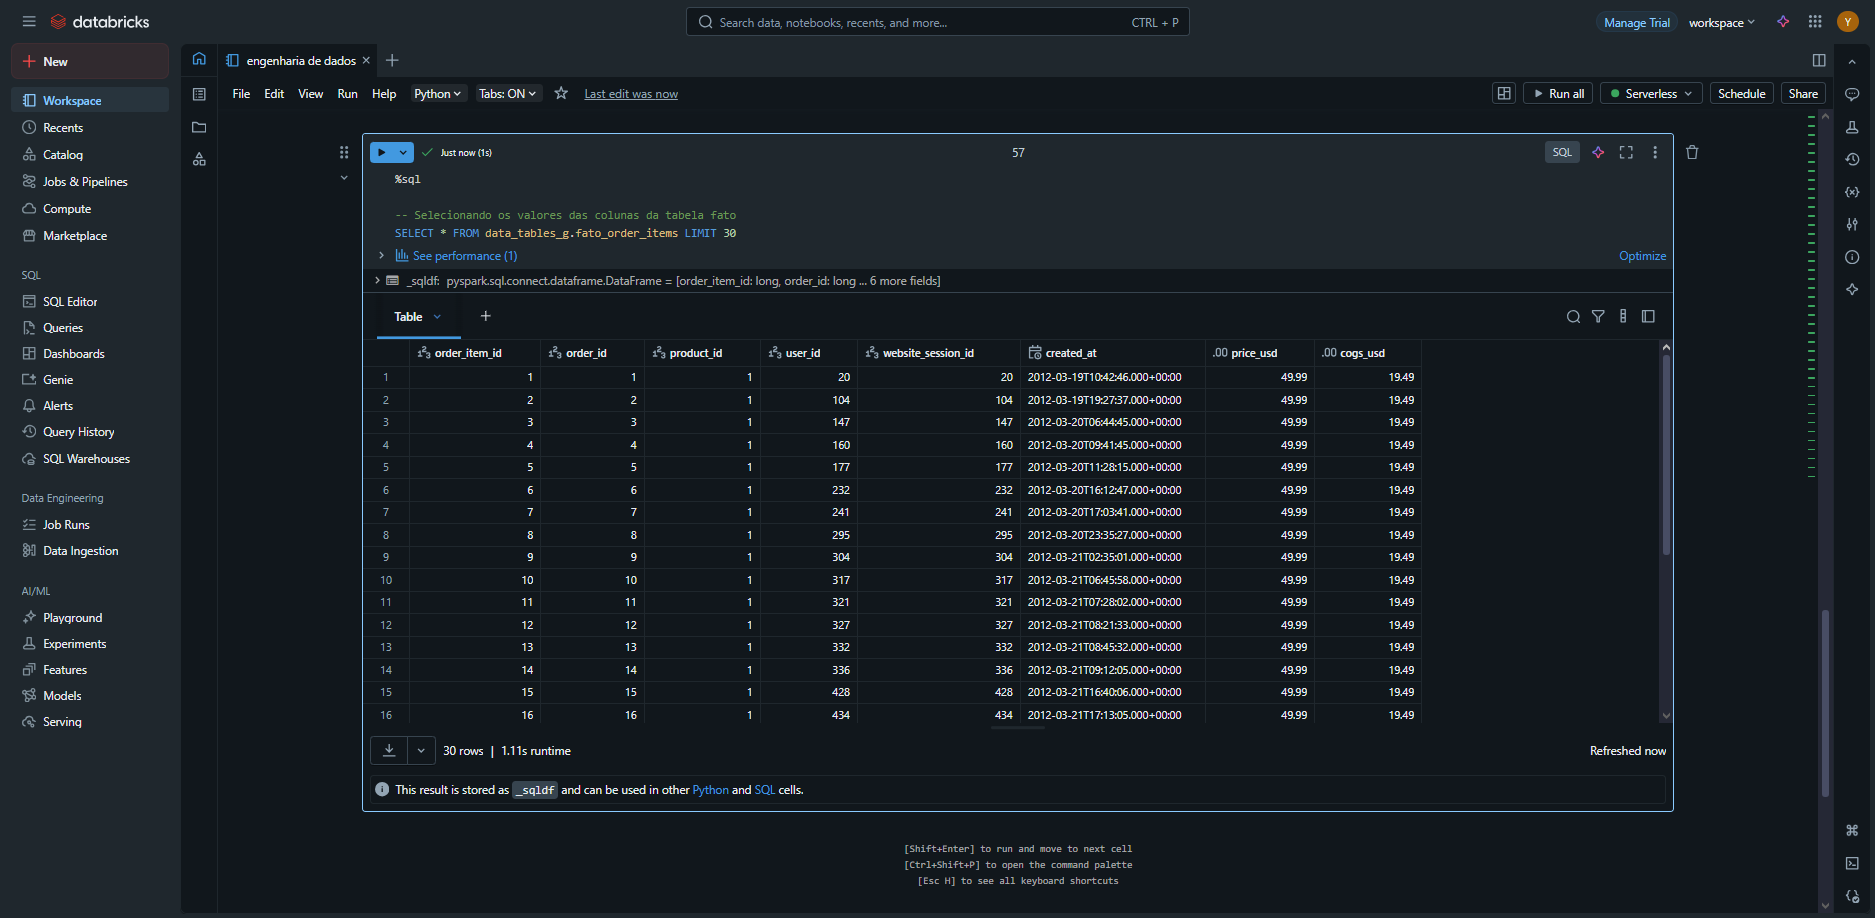

A tabela foi preenchida com sucesso, agora irei dar seguimento para as dimensões, para após iniciar as análises.

##### Preenchendo as dimensões

dim_products com os dados da própria tabela products

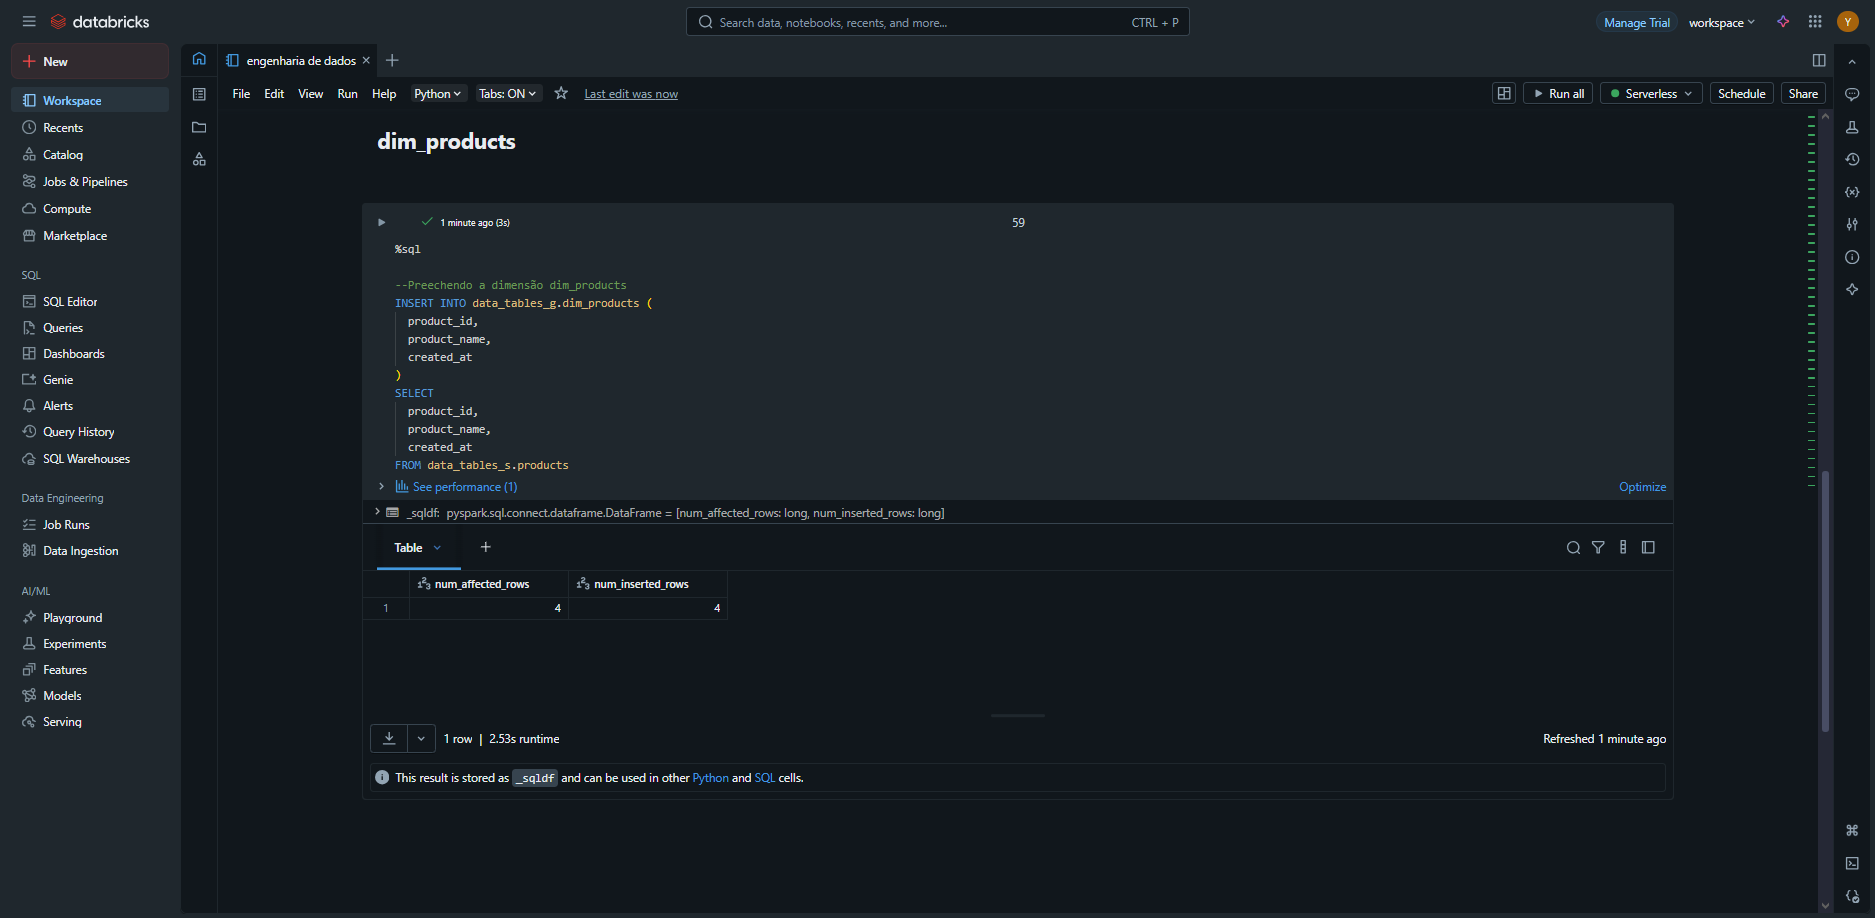

Listando os valores de dim_products

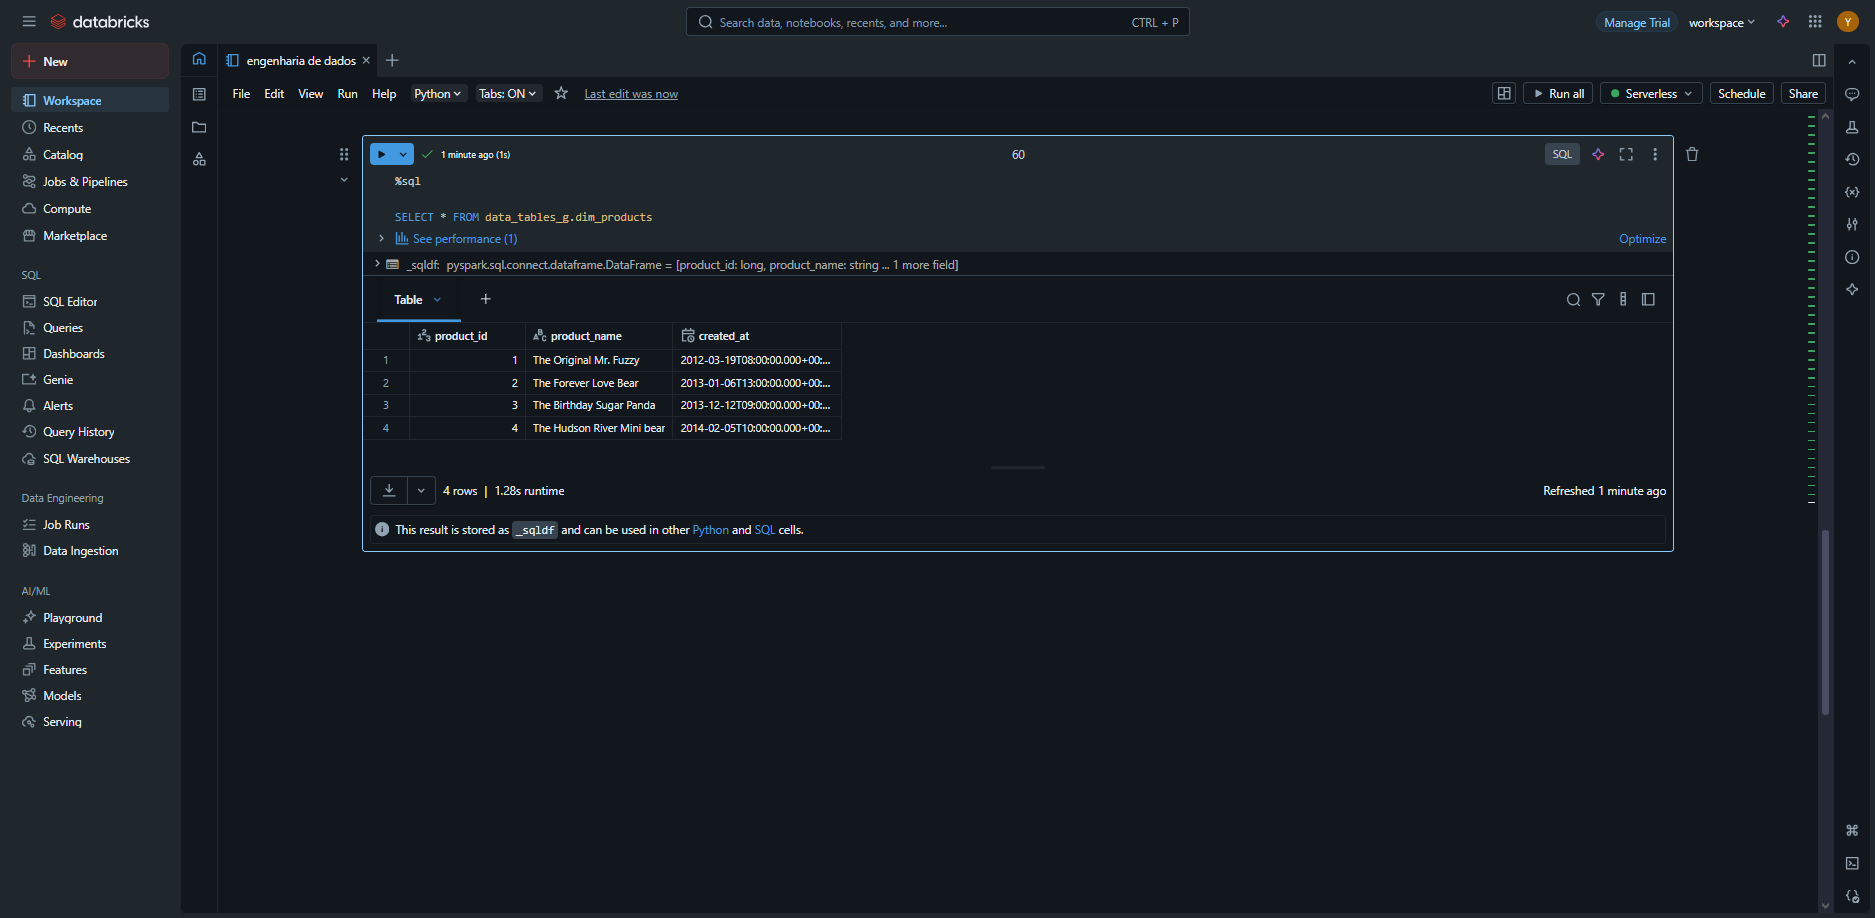

Preenchendo a dimensão dim_refunds utilizando as tabelas order_item_refunds, orders e order_items

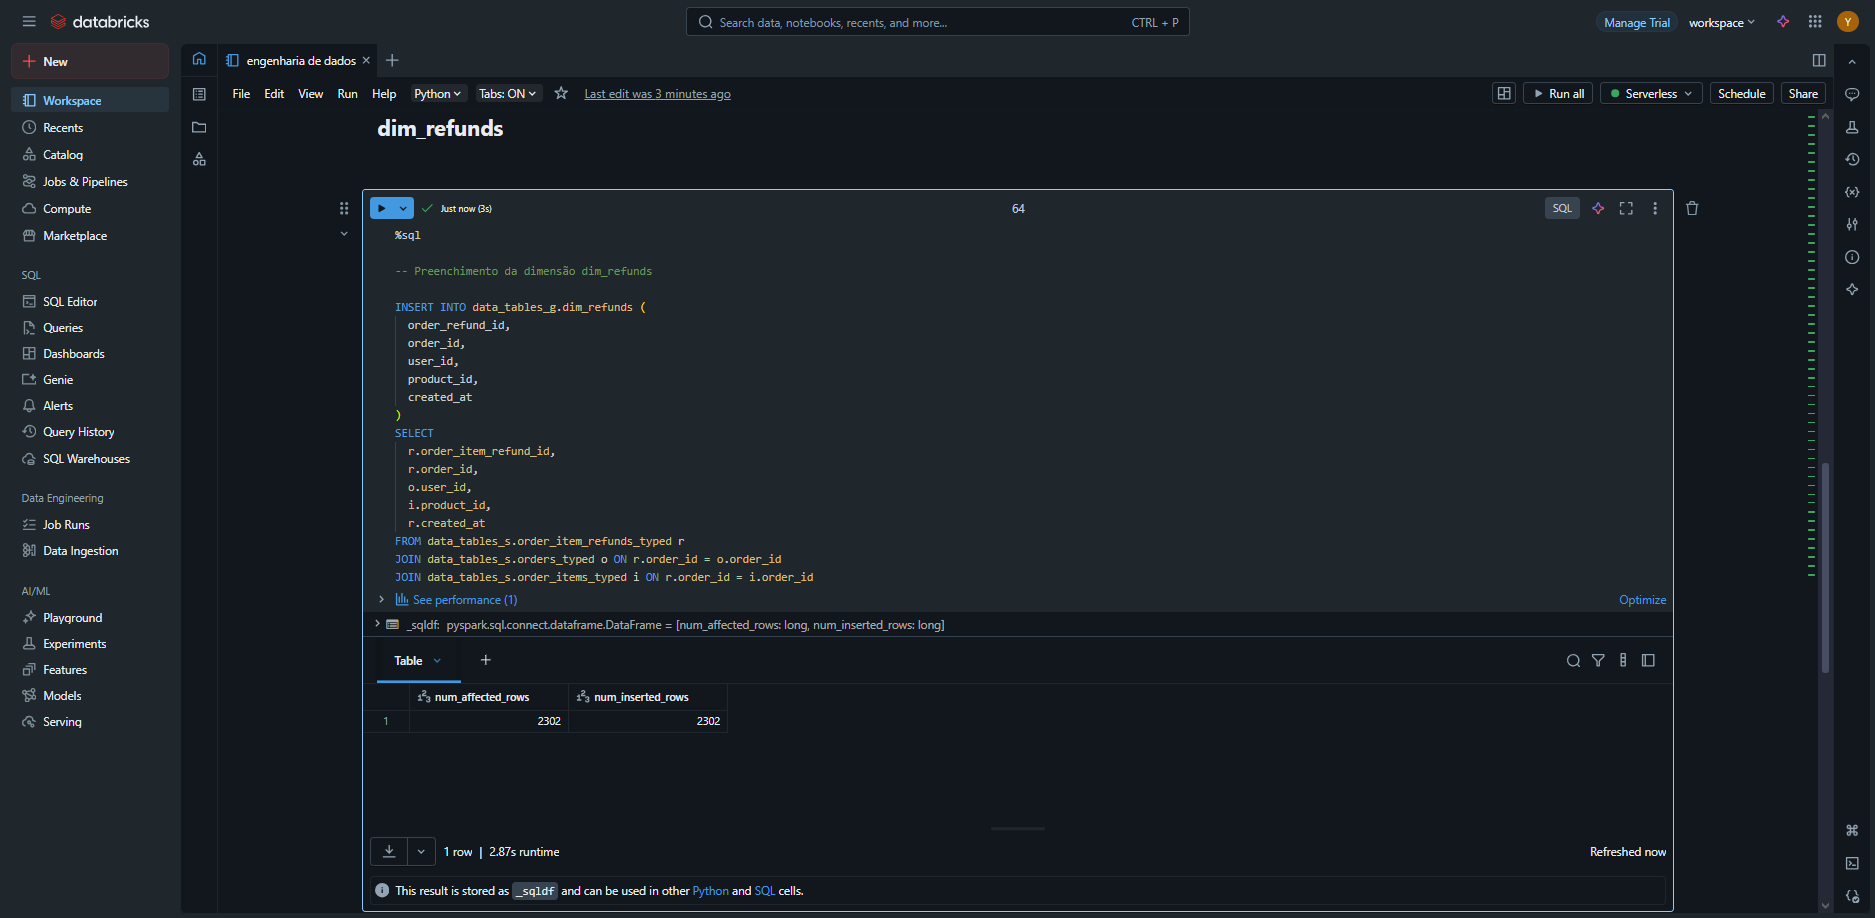

Irei realizar a seleção dos primeiros 30 valores para ver se o preenchimento foi correto.

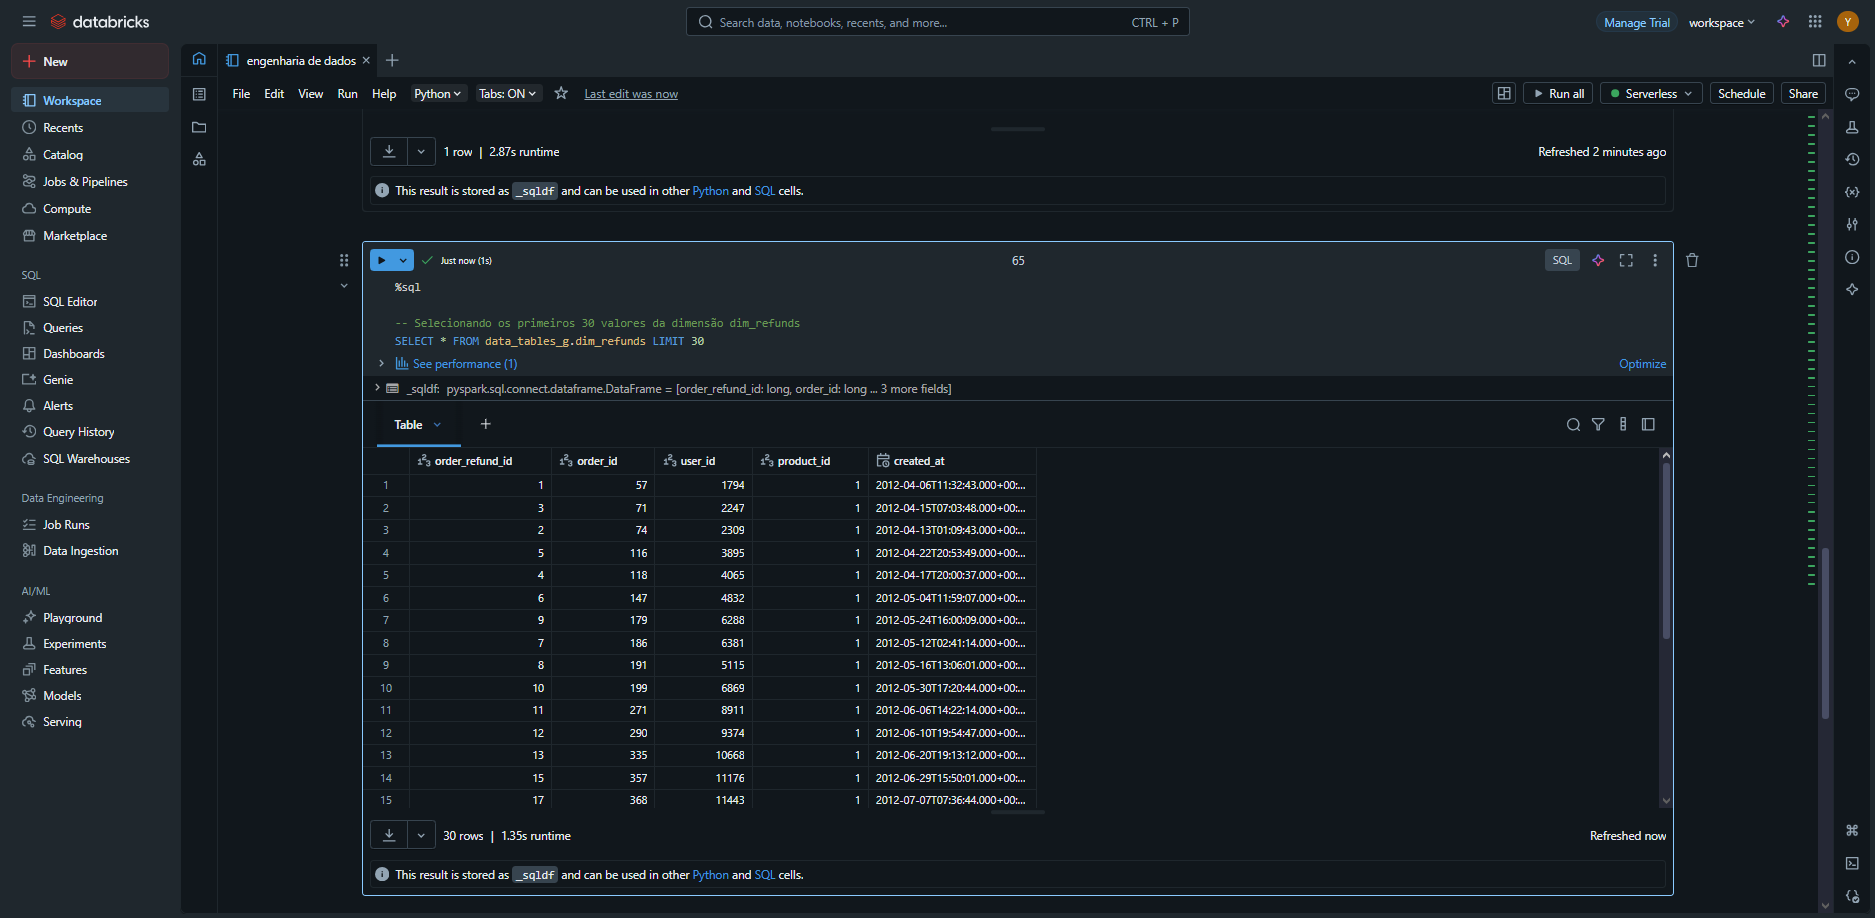

Preenchendo dim_users com os usuários distintos da tabela orders

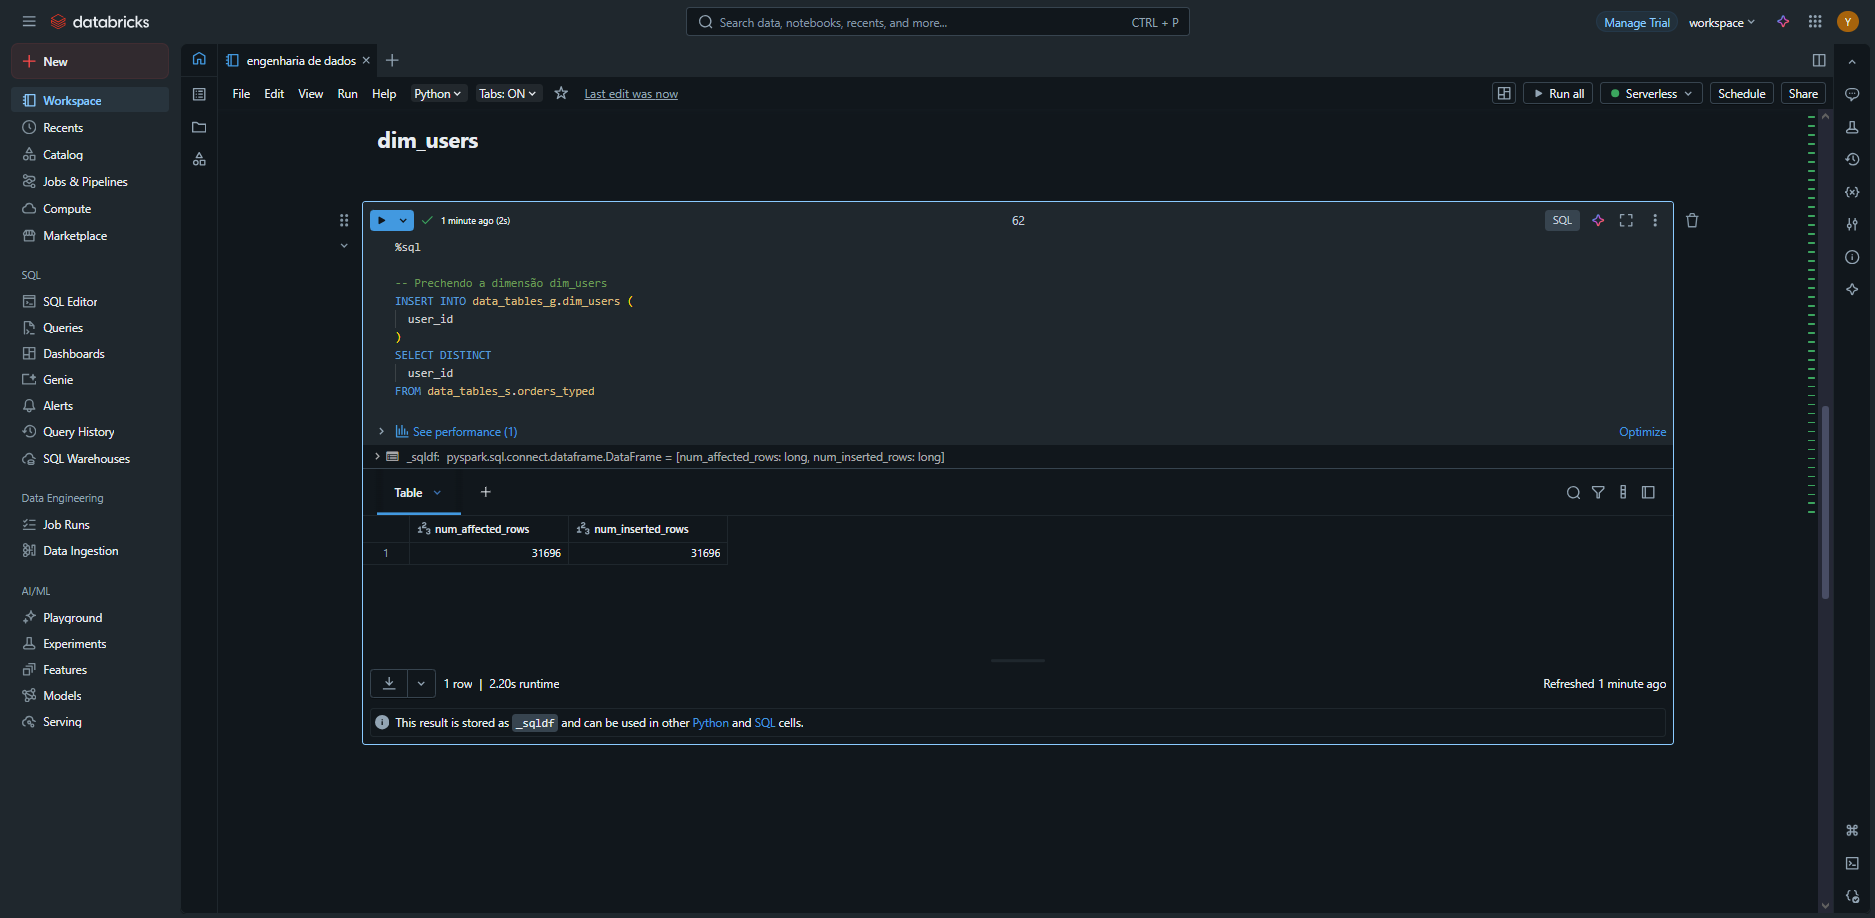

Listando os primeiros 30 valores de dim_users
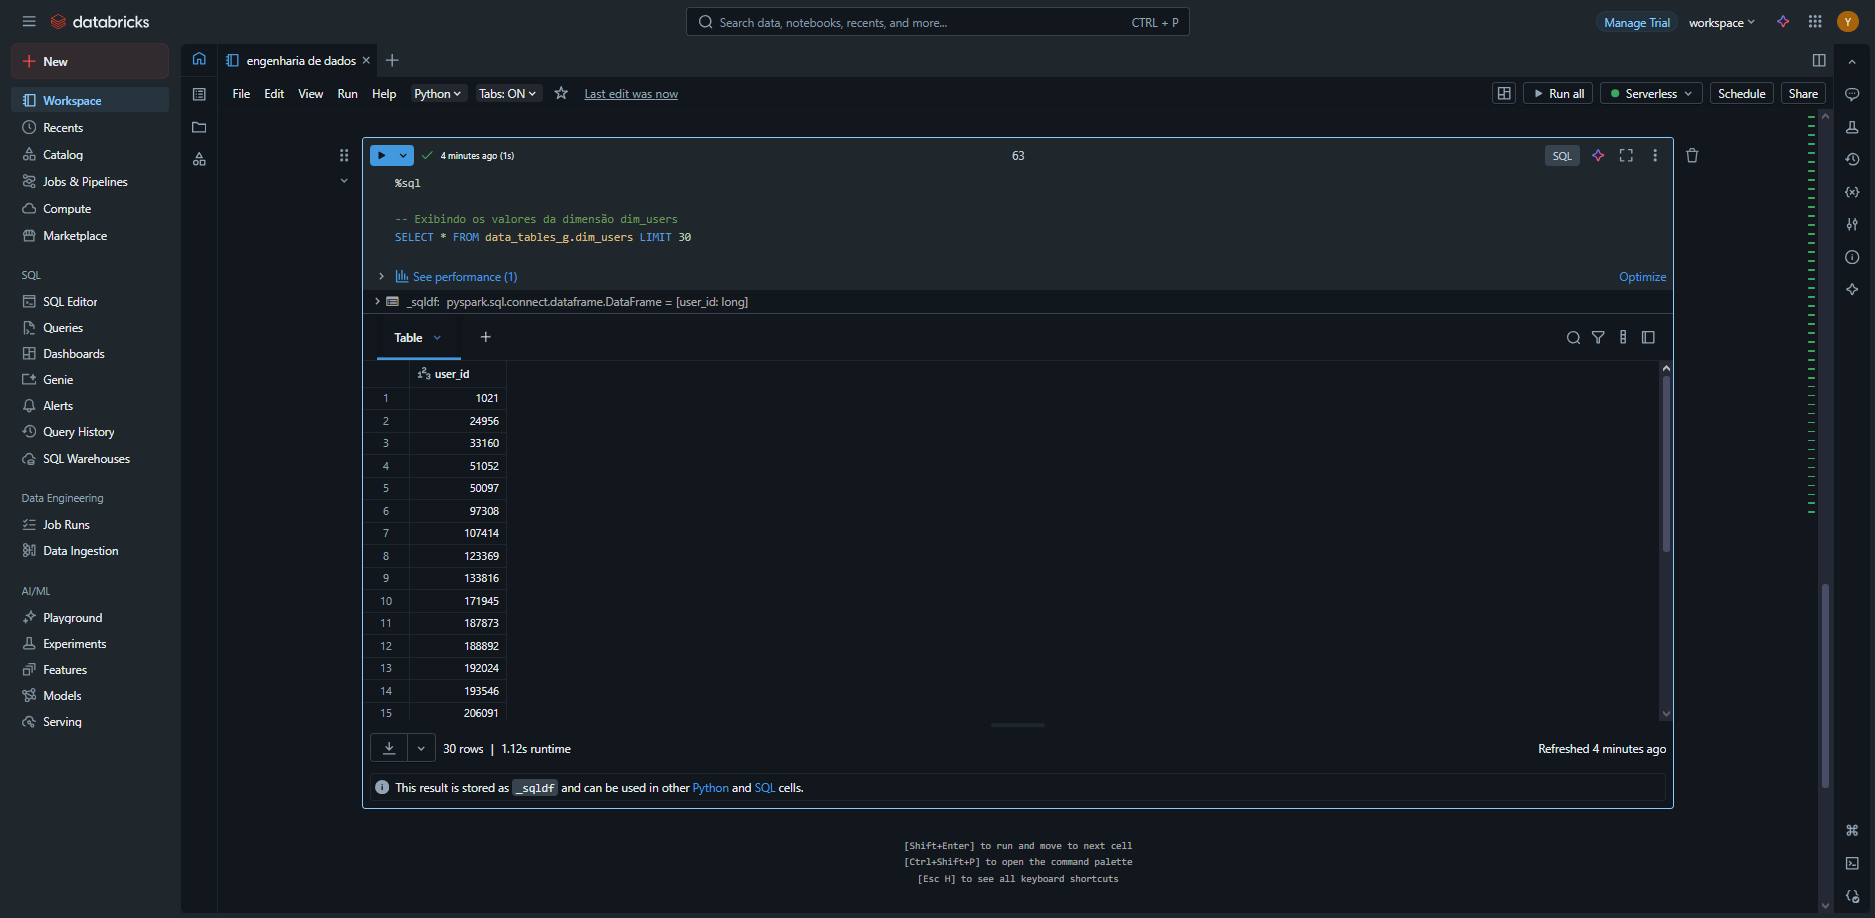

Utilizando as tabelas website_pageviews e website_sessions para preencher os dados da dimensão dim_pageviews

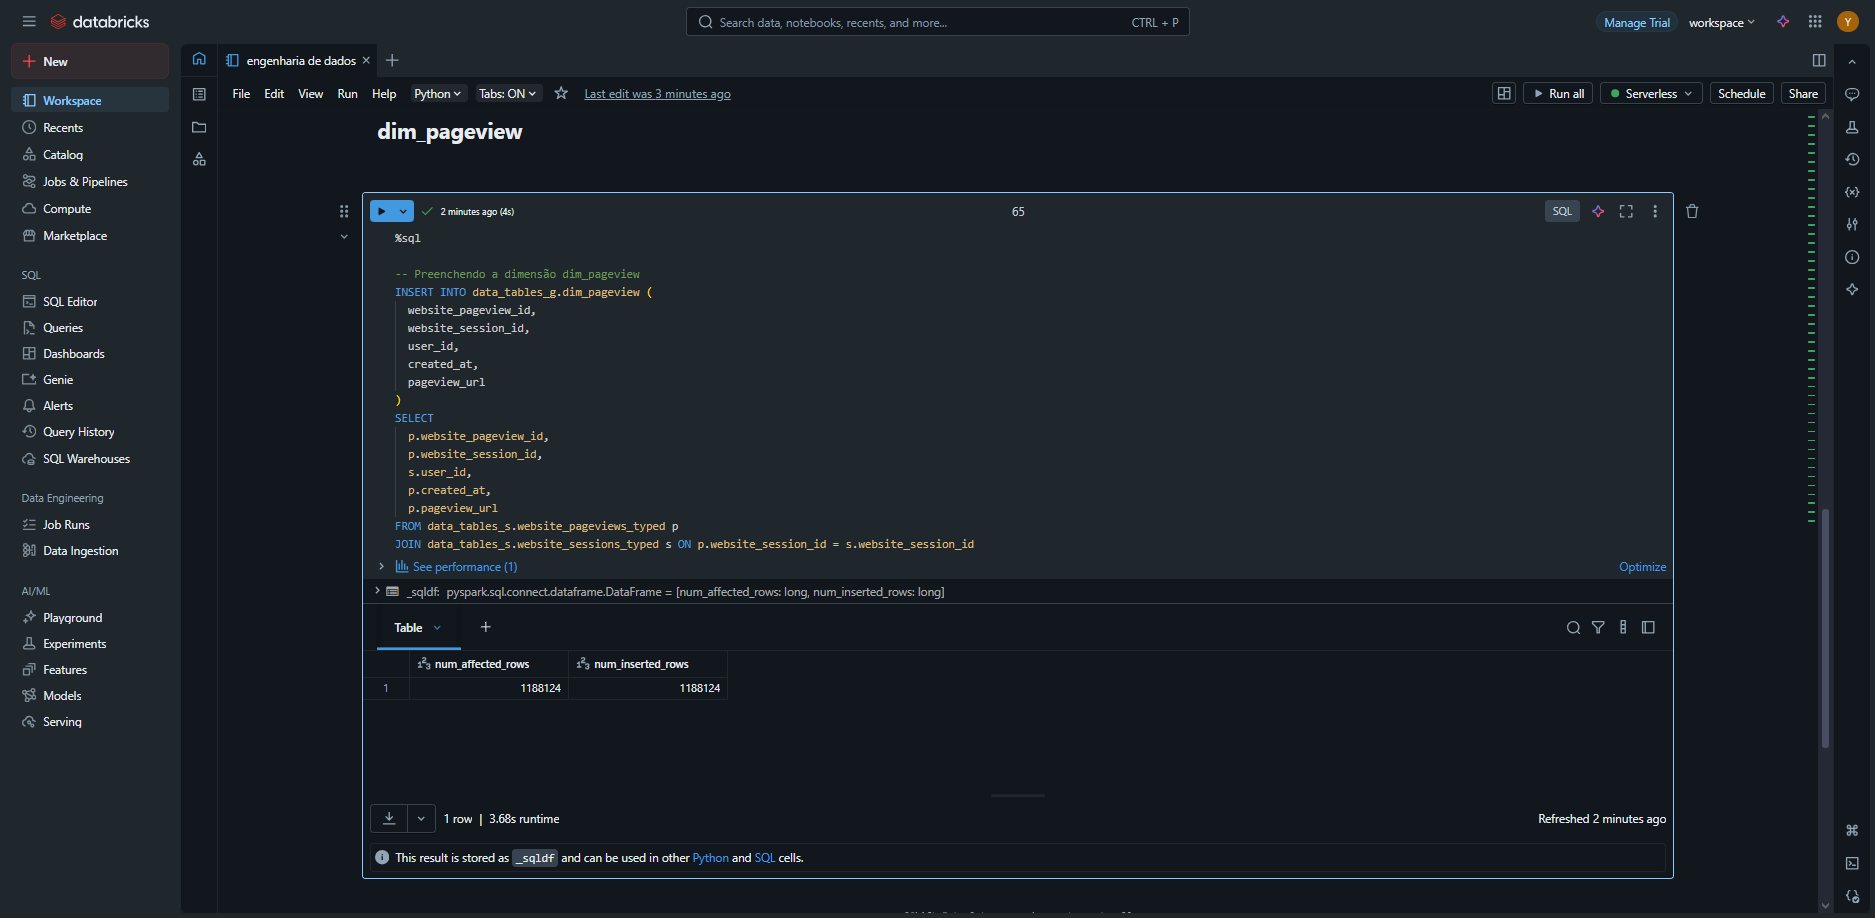

Listando os primeiros 30 valores de dim_pageviews

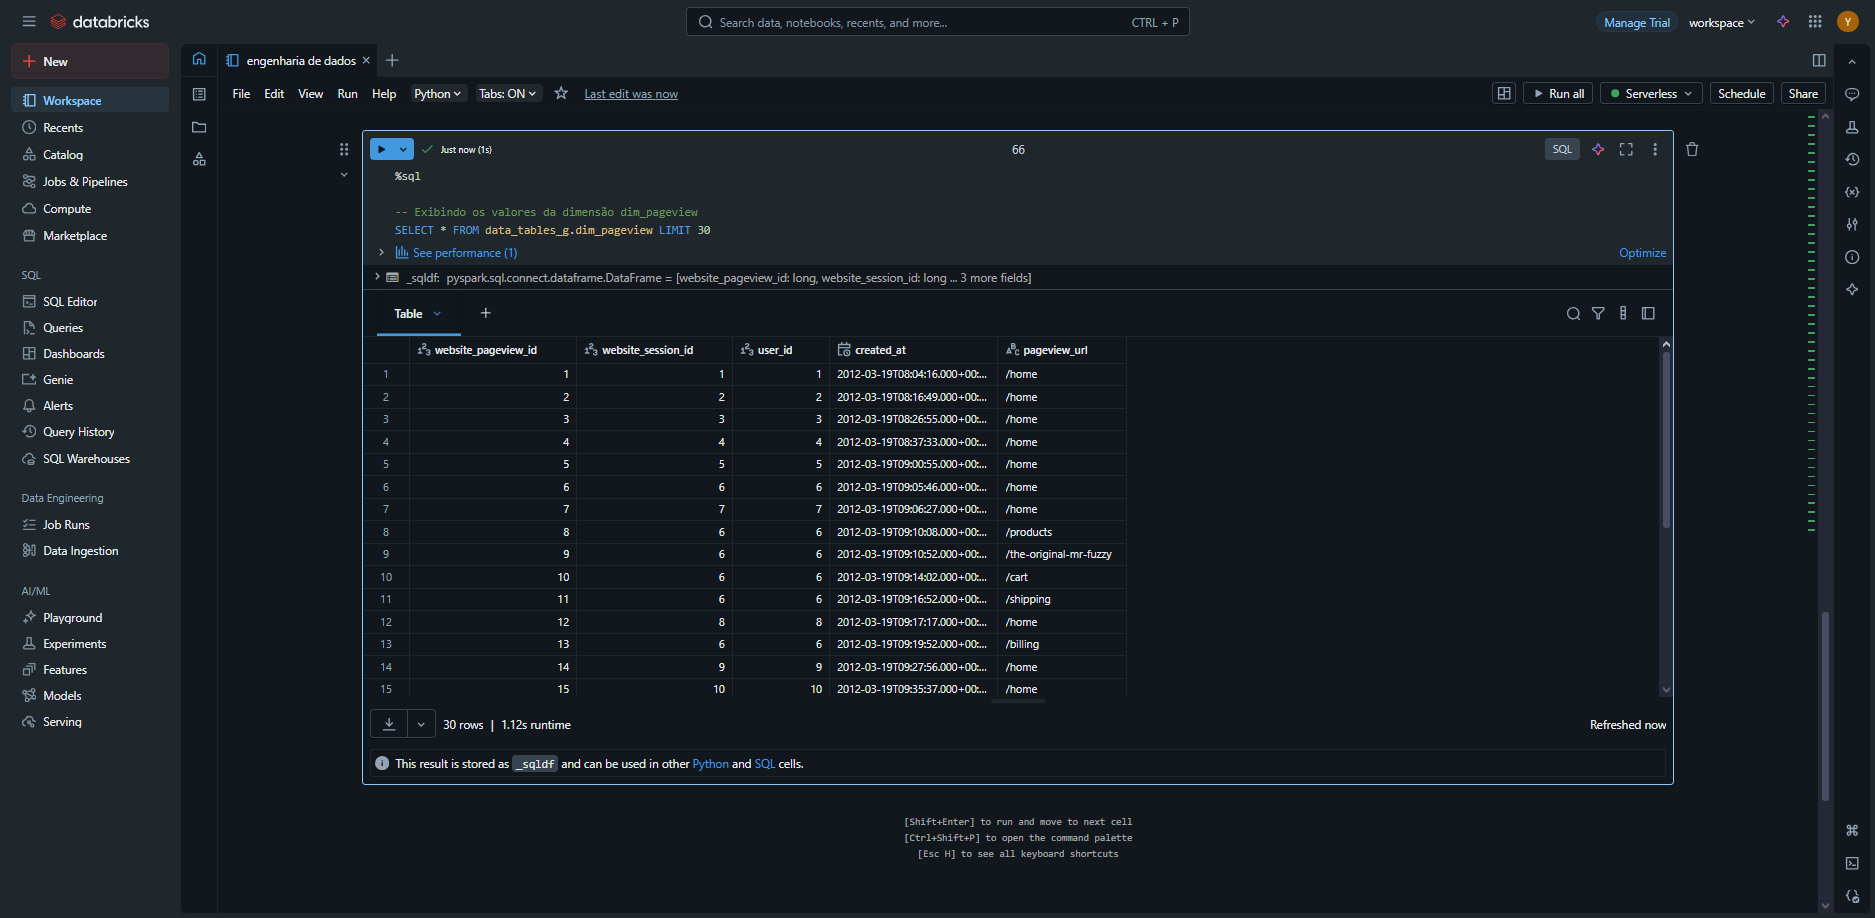

Preenchendo a dimensão dim_date com uma range de 01-01-2012 a 01-01-2016, como nas exbições dos valores minimos e maximos de datas da maioria das tabelas datam entre esse range de tempo, irei criar um script para preenchimento destes valores.

Criando o dataframe com date_id, day, month, year e visualizando os valores criados para conferência

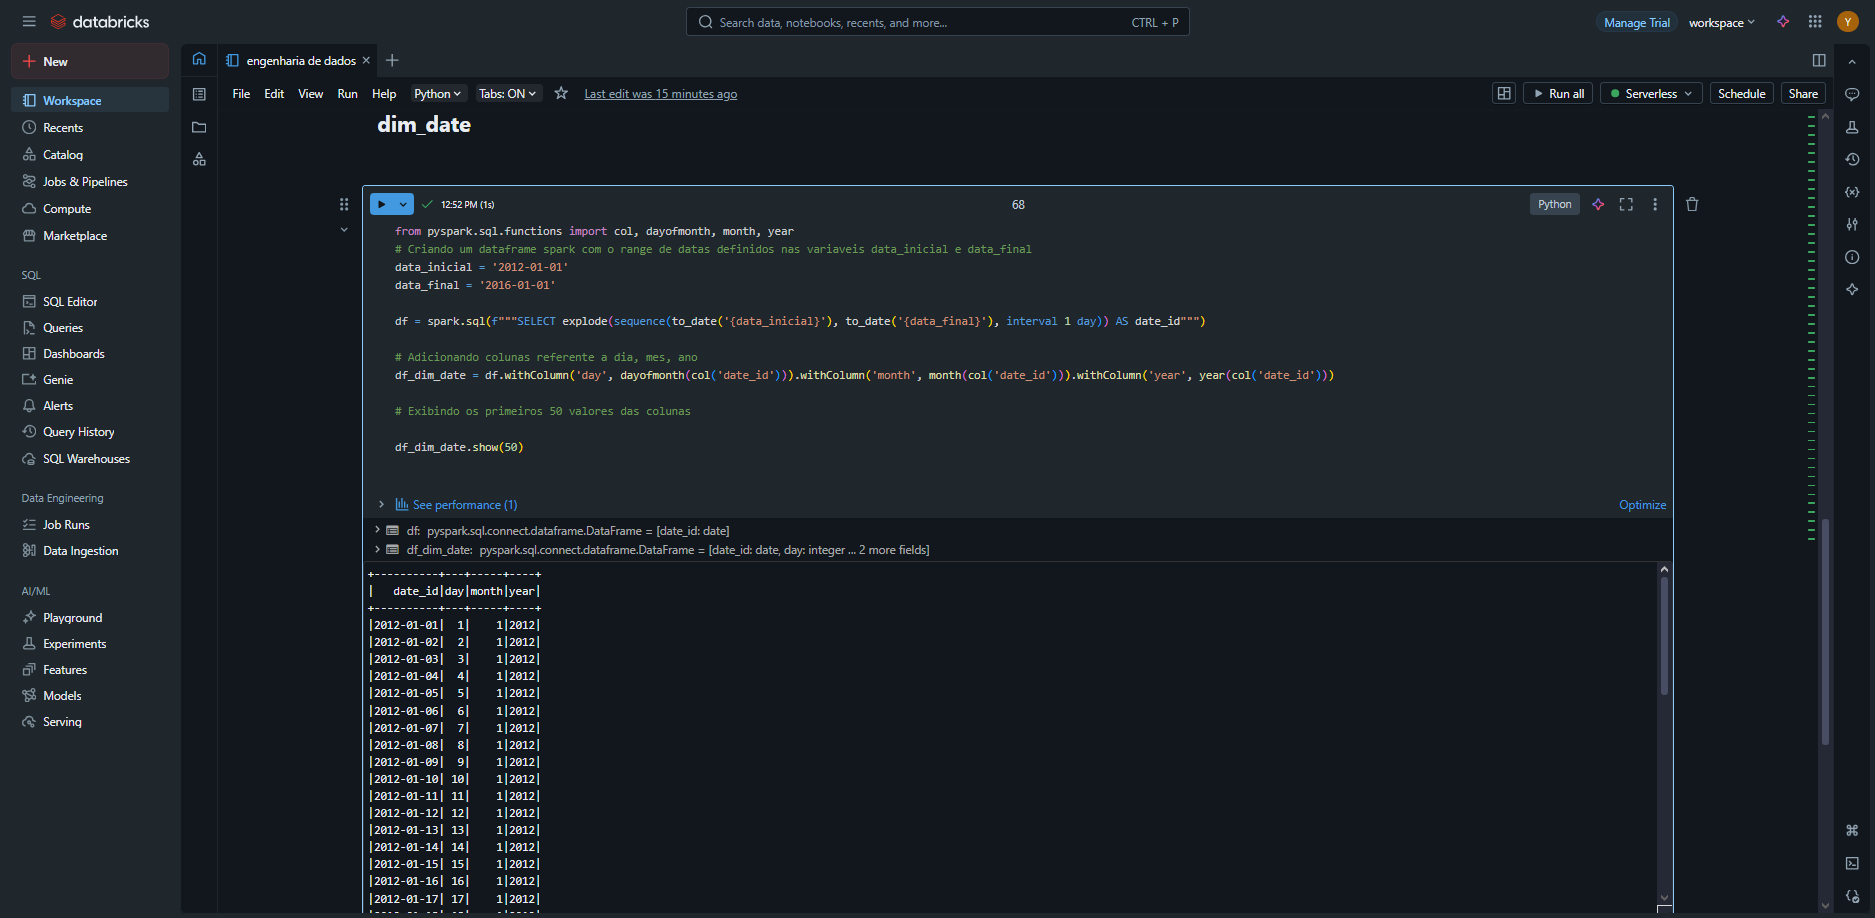

Realizando a adição dos valores do dataframe para dimensão dim_date e exbindo os valores inseridos através de comando sql

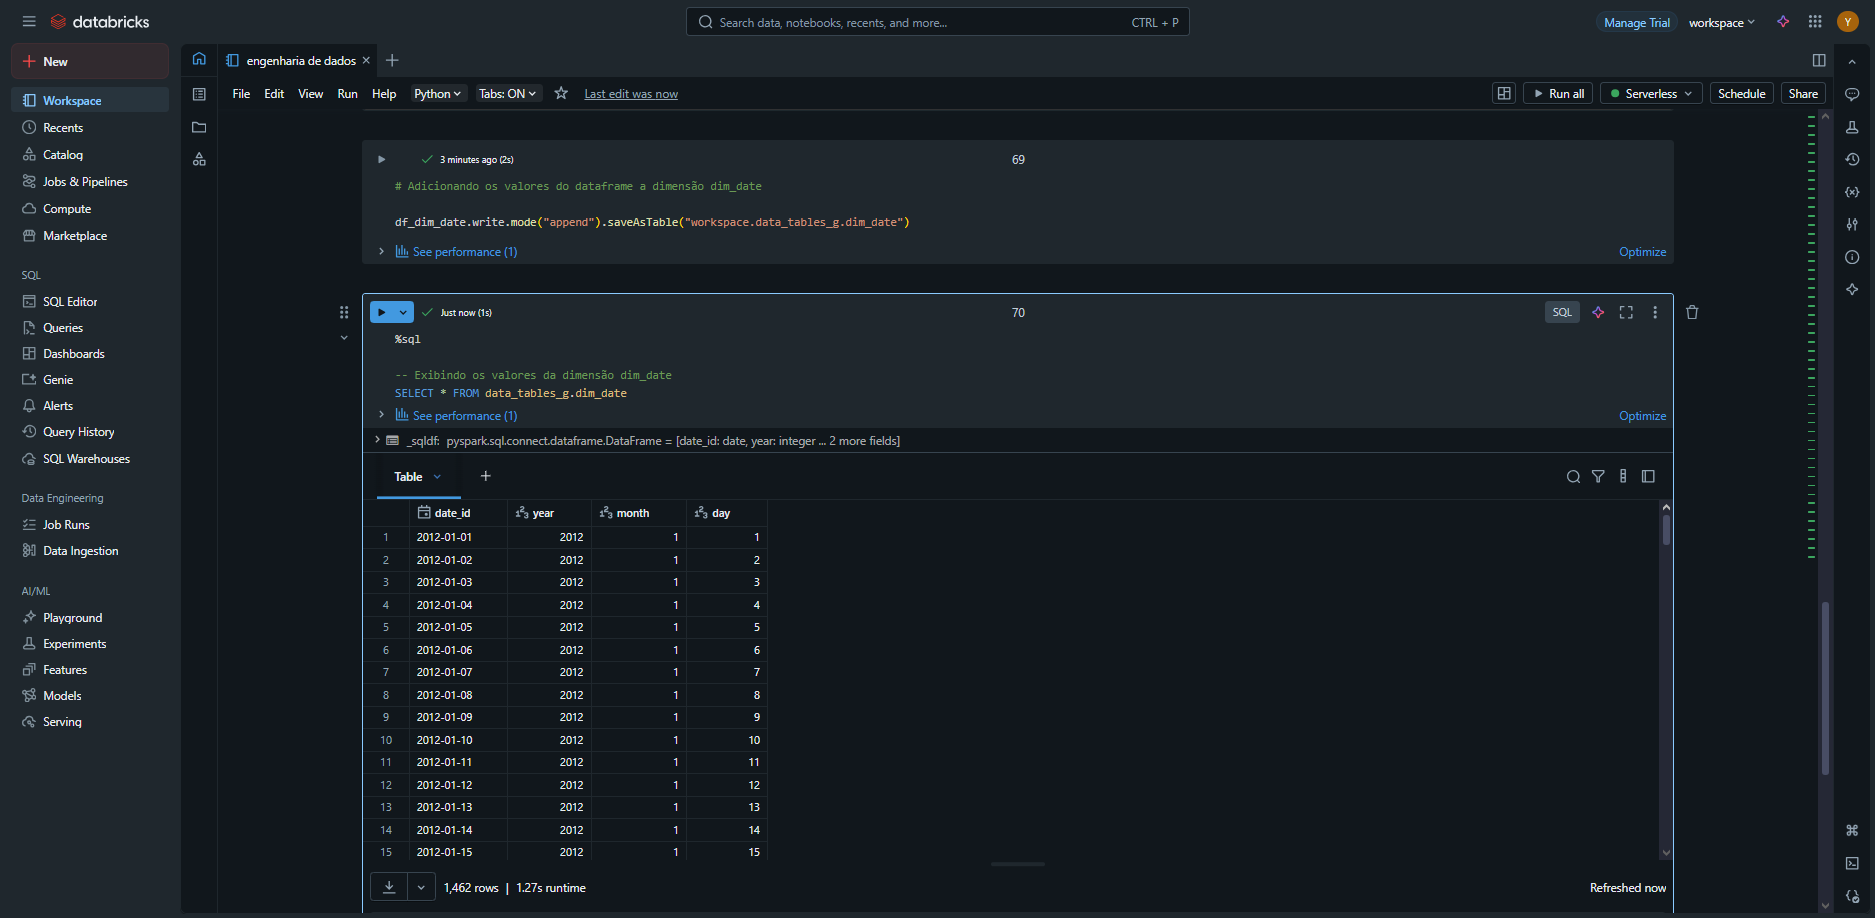

Com todas tabelas dimensões preenchidas o esquema estrela está pronto, irei para última etapa, a análise.

# Análise

Nesta sessão irei realizar algumas análises para responder algumas perguntas que ao decorrer da modelagem me ocorreram, são elas:

1.  Qual usuário mais gastou na loja?
2.  Qual é o produto mais vendido da loja?
3.  Qual foi o mês de maior faturamento da loja?
4.  Qual item é o mais reembolsado?

## 1 - Qual usuário mais gastou na loja?

Irei utilizar a tabela fato para filtrar através do valor que o usuário gastou para ter a resposta que preciso.

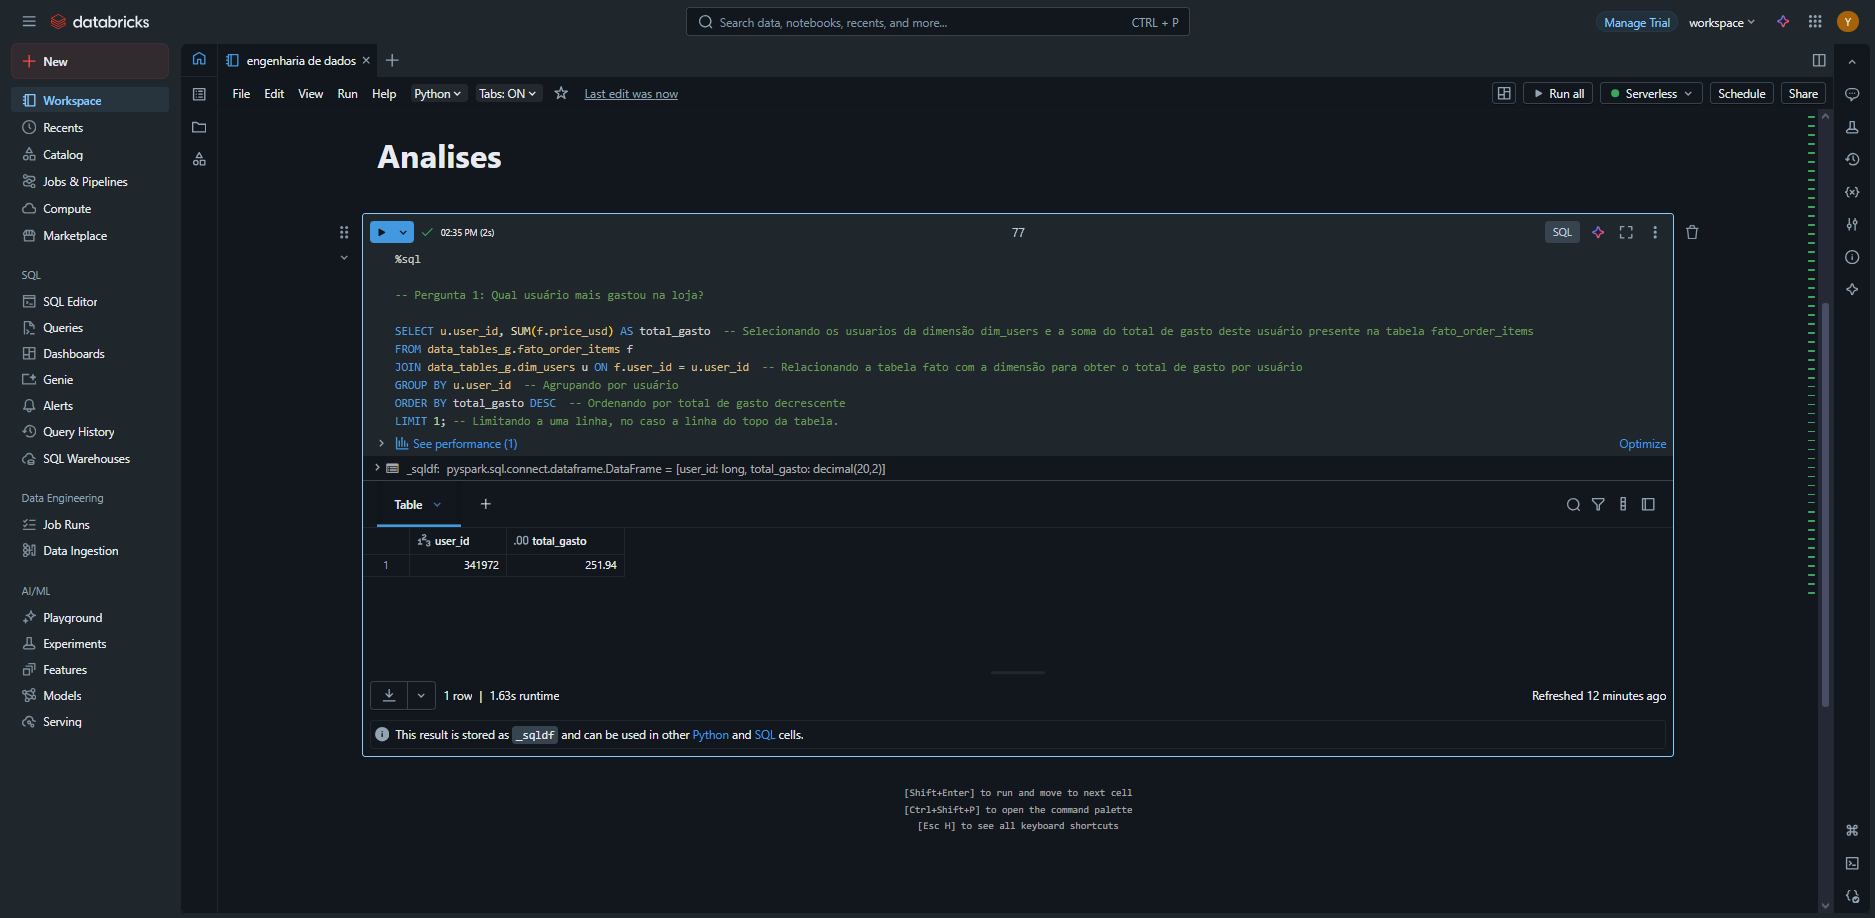

Após a consulta foi possível descobrir qual usuário mais gastou na loja virtual, no caso sendo o usuário de id igual a 341972 que gastou um total de $251.94 dólares na loja.

## 2 - Qual é o produto mais vendido da loja?

Para esta análise irei utilizar a tabela fato e a dimensão dim_product, para contagem do produto mais vendido.

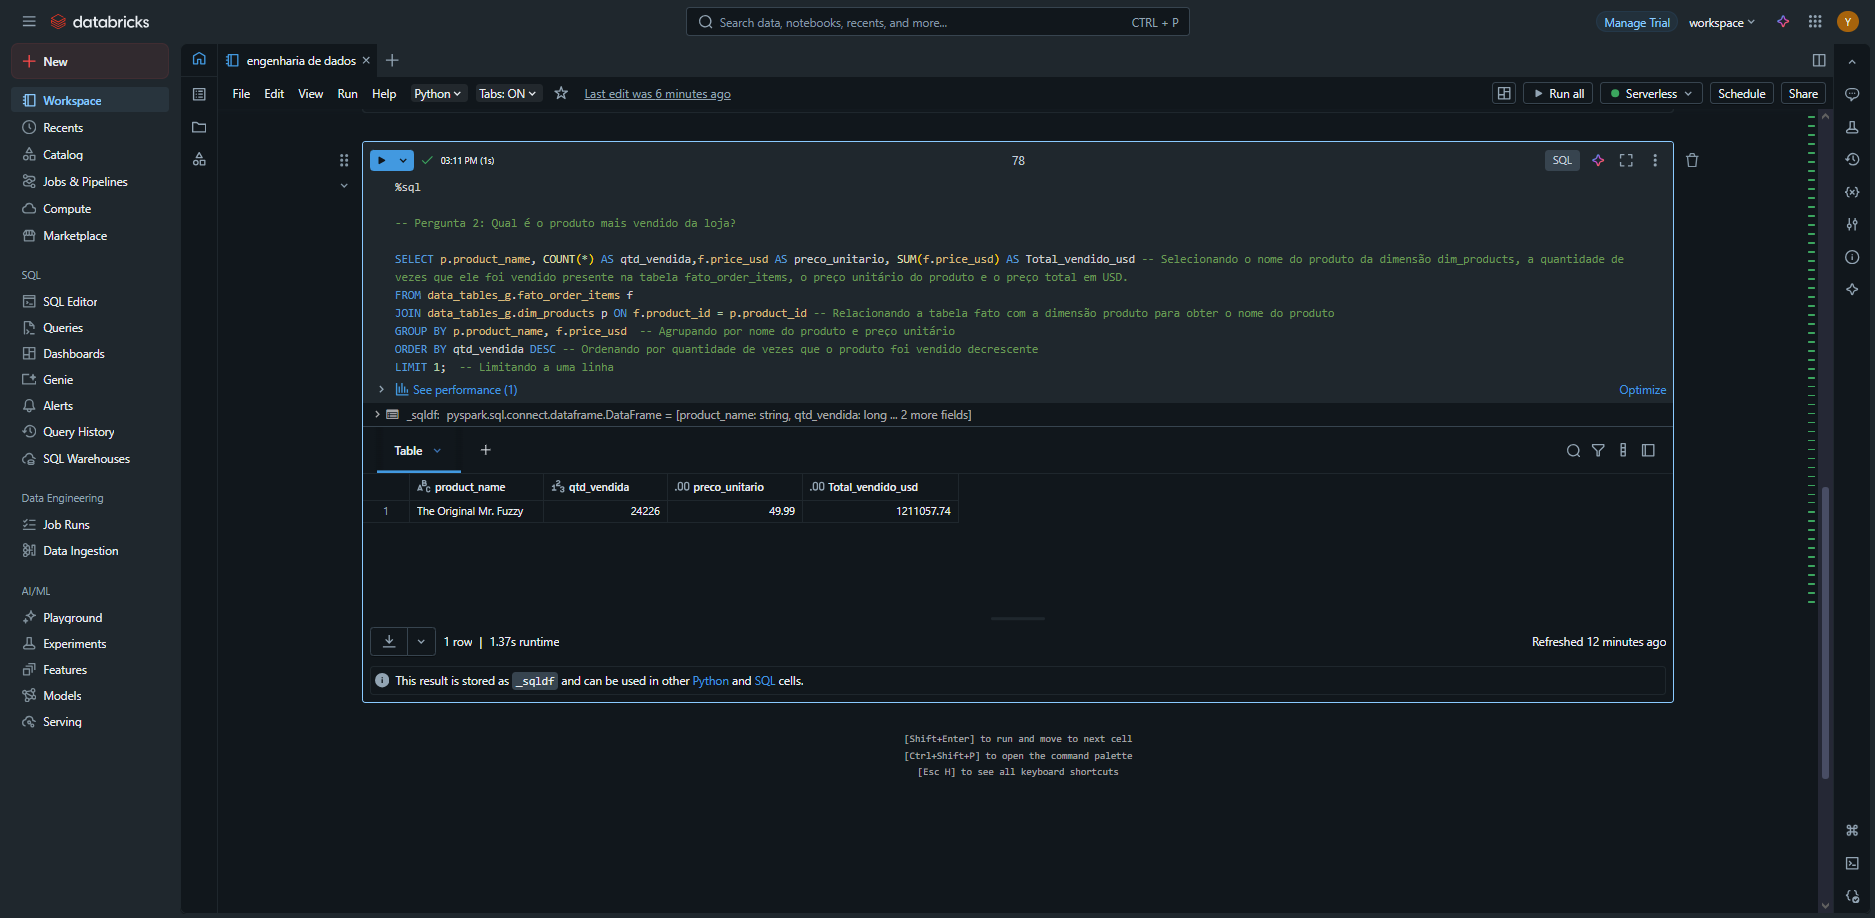

Adicionei também o valor unitário e o total em usd vendido do produto. Assim realizando a ordenação por ordem decrescente por quantidade vendida da tabela gerada e limitando a 1 valor apenas, cheguei a resposta:<br>
- O item mais vendido é o brinquedo "The Original Mr. Fuzzy";
- A quantidade total vendida é igual a 24226 unidades;
- Com cada unidade custando \$49.99 dólares o valor total levantado com as vendas é de $1211057.74 de dólares.

## 3 - Qual foi o mês de maior faturamento da loja?

Para esta análise irei utilizar a tabela fato e a dimensão dim_date para poder realizar a filtragem do mês com maior rendimento.

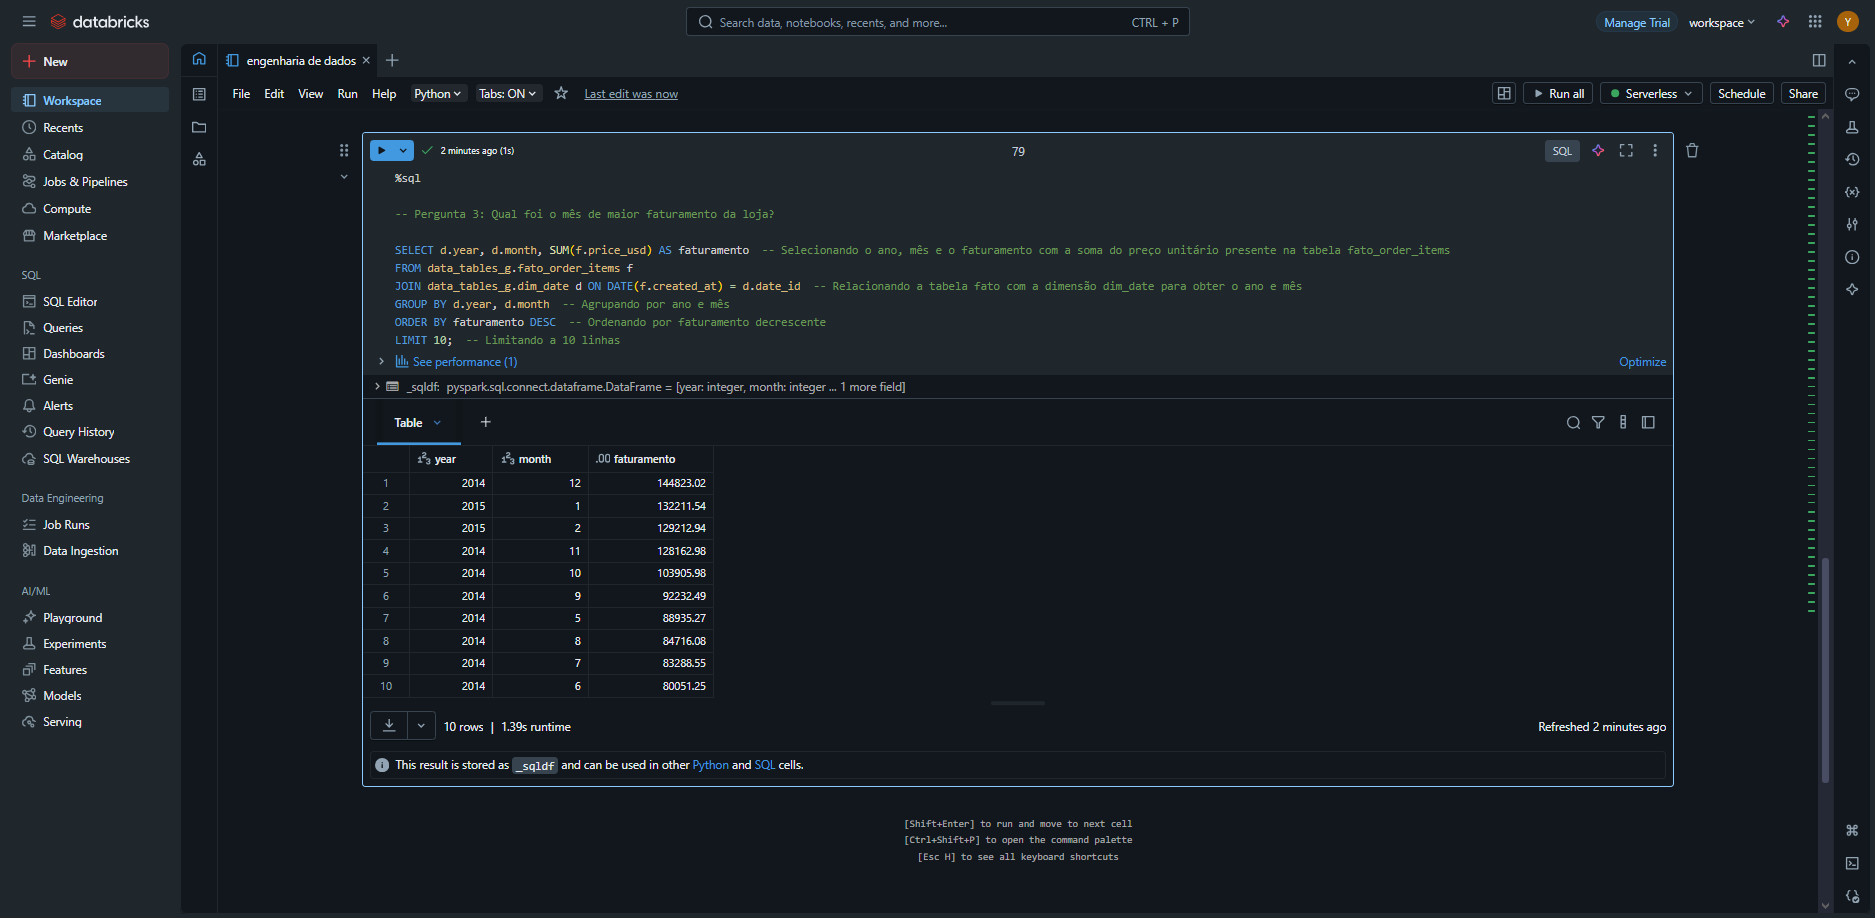

Esta análise eu filtrei as primeiras 10 linhas para ter uma idéia dos faturamentos mensais da loja, pude chegar a conclusão de que o mês 12 de 2014 foi o mês com maior faturamento histórico da loja sendo \$144823.02 dólares, interessante também que os 3 meses com maior faturamento são a sequência de meses do mês 12 de 2014 ao mês 02 de 2015 o que pode indicar época festiva, o que geralmente faz o consumo principalmente para presentes aumentar.

## 4 - Qual item é o mais reembolsado?

Para analisar o item com maior ocorrência de reembolso, precisarei utilizar a tabela fato em junção com a dimensão de reembolsos dim_refund e a dimensão dos produtos dim_product.

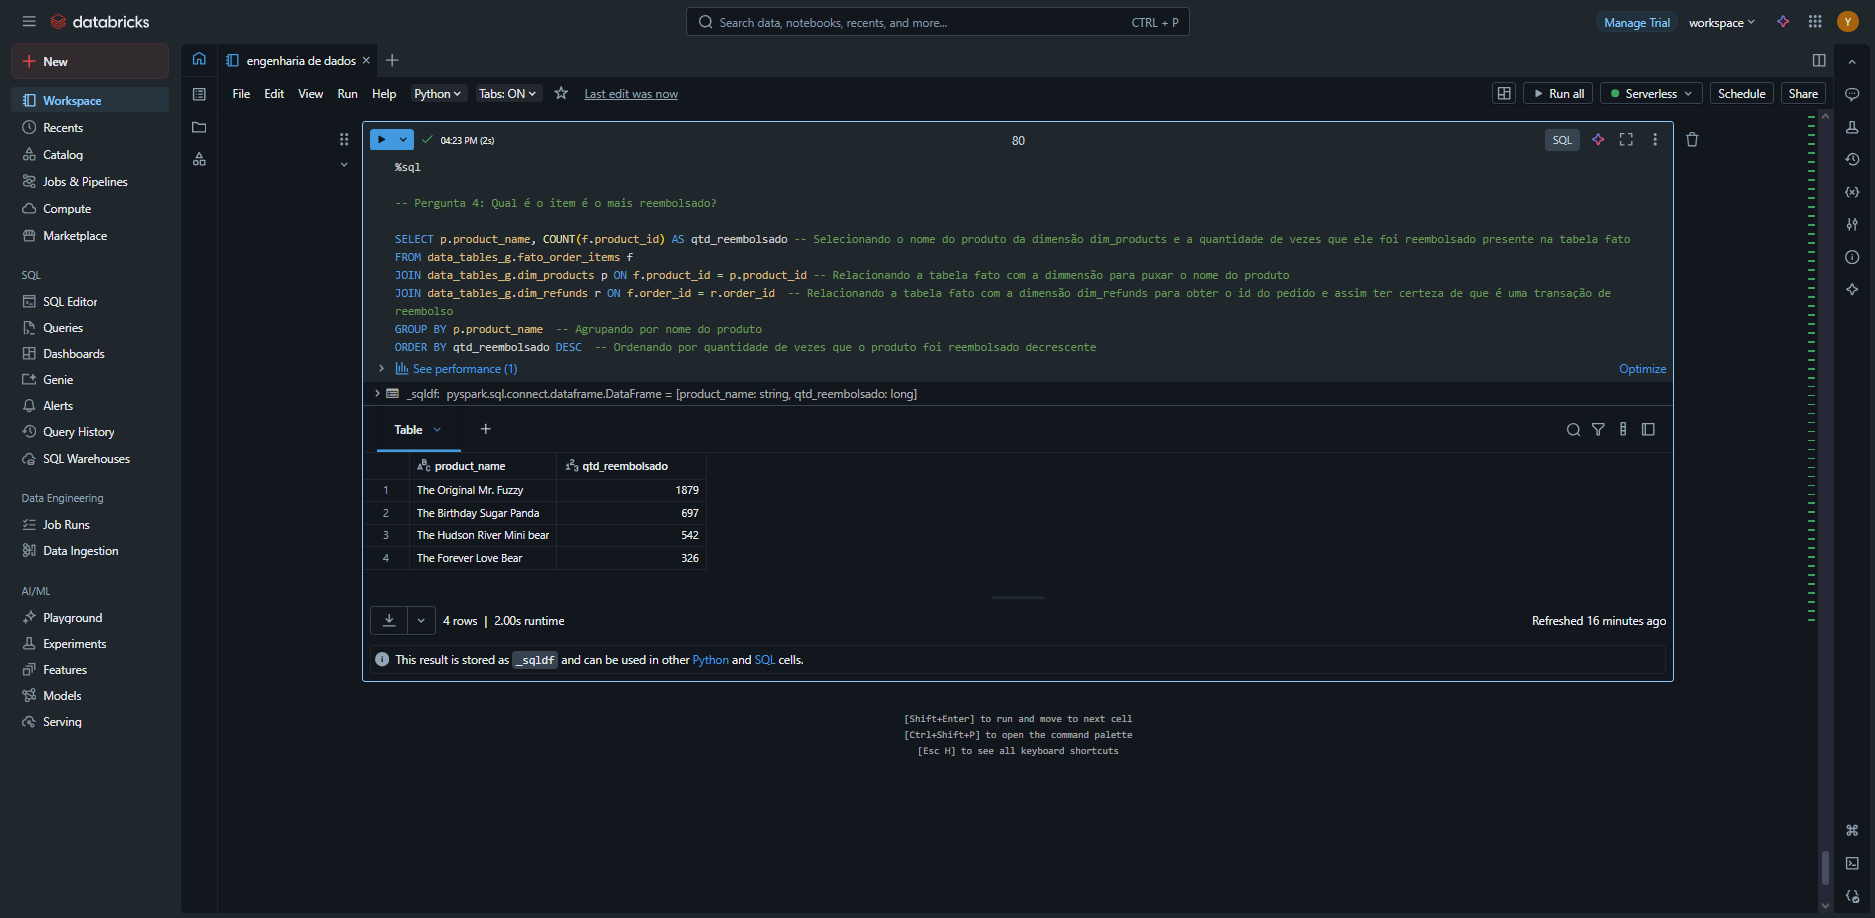

Após realizar a contagem, pode-se notar que o brinquedo com mais reembolso é o mesmo que o mais vendido, "The Original Mr. Fuzzy" com 1879 unidades reembolsados para o usuário.

# Conclusão

**Objetivos:**


1.   É possível eu realizar um processo de ETL por uma plataforma em nuvem?<br>


*   Sim é possivel eu realizar o processo de ETL em nuvem, inicialmente eu iria produzir o projeto na plataforma Google Cloud já que é apresentado no conteúdo das aulas e é uma plataforma amplamente utilizada no meio corporativo, porém eu tive um "erro" isolado em que o ssh do meu cluster ficou sem acesso a internet enquanto eu atualizava o sparkmonitor, responsável por algumas visualizações em tempo real da execução do projeto, por este motivo e o fato de que o Databricks tem uma versão de prática, resolvi desenvolver o projeto no Databricks. Inicialmente estranhei um pouco os comandos e o fato do gerenciamento de arquivos ser um pouco diferente do hadoop, porém por causa da interface simplificada e tutoriais da plataforma consegui me movimentar e desenvolver o processo de ETL. Os dados que escolhi para manipulação não necessitaram de tantas tranformações, por mais que na plataforma de onde os tirei fossem considerados brutos, então não exercitei tanto a habilidade de transformações de dados, outro ponto é que como eu escolhi dados estaticos, eu não tive a oportunidade para explorar o ambiente de execução em nuvem para rodar scripts para extração de dados de alguma fonte de streaming.<br>
No geral a principal diferença entre um processo de ETL fora da nuvem e um dentro da nuvem é a organização dos arquivos e o controle dos processos e consumo da arquitetura de nuvem.
<br>
<br>
2.   Como funciona o sistema de armazenamento em nuvem?<br>

*   Tendo como plataforma o Databricks ele utiliza para sua governança de dados o método Unity Catalog que visa centralizar o gerenciamento de todos os dados em uma só plataforma. Este método contém hierarquias para organização dos dados, são elas:<br>
    * Catalog -> Sendo o nível mais alto da hierarquia tem o intuito de separar ambientes de execução caso necessário, como por exemplo ambiente de teste e produção.<br>

    * Schema -> Sendo o nível intermediário, tem como função a organização das finalidades dos dados, no caso separandoos por significado e utilizade.<br>

    * Tabela/Volume -> Sendo o nivel mais baixo e geralmente o mais manipulado é onde ficam armazenados os dados estruturados como tabelas e também os dados não estruturados como arquivos diversos (CSV, JSON, IMG, etc.).<br>

    Através desta estrutura podemos ter varios beneficios, entre eles segurança, acessibilidade, simplificação entre outros.
<br>
<br>
3.   Quais etapas práticas seguir para realizar a produção de um esquema estrela?<br>

*    Para a produção de um esquema estrela é necessário ter os dados para criação das tabelas dimensões e fato limpos e organizados, logo após vem a etapa de manipulação dos dados para definir como a tabela fato será criada e o quanto ela consegue ser util pra as filtragens e análises, logo após a criação da tabela fato, é bom dividir as tabelas dimensões por funções sendo 4 tabelas para um bom esquema todas devem englobar tempo(Quando?), Usuário/Produto(Quem?), Local(Onde?) e Meios(Como?). Realizando um esquema estrela que responda essas perguntas quando perguntadas, ele será um bom esquema.

**Conclusões finais:**<br>
Ao decorrer do projeto tive algumas dificuldades principalmente pelos meios de acesso aos arquivos para a manipulação, notei que quando utilizada a interface do Databricks dedicada a Queries para criação de tabelas baseadas em um arquivo .csv há limitações para indicar cabeçalhos e até tipos de dados, quando convertia algum arquivos alguns vinham com colunas nulas e o cabeçalho como valor da tabela, então passei para o pyspark para a criação de tabelas.<br><br>
Inicialmente para visualizar a tabela de dicionários tive problemas envolvendo o nome do arquivo que iniciava com underscore, e depois de um tempo pesquisando sobre acessos a arquivos no Databricks, direcionei minhas pesquisas ao underscore no inicio do arquivo e achei algumas menções a convenções envolvendo metadados e arquivos ocultos e que o Databricks tinha a possibilidade de operar com estas convenções, então refiz o upload do arquivo sem o caractere inicial e então ele abriu e consegui consultá-lo por meio do pyspark e sql.<br><br>
Foi bom aprender como se monta um esquema estrela e como ele funciona, creio que facilita a adaptação do projeto para criação de uma interface gráfica de consultas, já que a finalidade do esquema é facilitar as consultas.<br><br>
Olhando de modo geral foi um projeto desafiador no inicio e divertido no final, irei me aventurar com dados maiores e mais complexos no futuro.